In [10]:
import os
import numpy as np
import pandas as pd


R_GAS = 8.314
R_ATM = 0.082057

TEMP_COL = "calibrated temperature (K)"
NG_COL_RT_ABP2 = "ABP2 O2 Released (µmol)"
NG_COL_RT_MPR  = "MPR O2 Released (µmol)"


NG_COL_37C_ABP2 = "ABP2 O2 Released (µmol)"
NG_COL_37C_MPR  = "MPR O2 Released (µmol)"

CSV_FOLDER = r"C:\Users\chand\Documents\GitHub\Thesis\csv_combi"

# ─────────────────────────────────────
# Battino data
# ─────────────────────────────────────
battino_T  = np.array([273.15, 278.15, 283.15, 288.15, 293.15,
                       298.15, 303.15, 308.15, 313.15, 318.15,
                       323.15, 328.15, 333.15, 338.15, 343.15, 348.15])

battino_dH = np.array([-17.60, -16.18, -15.16, -14.15, -13.13,
                       -12.11, -11.10, -10.08,  -9.06,  -8.05,
                        -7.03,  -6.01,  -5.00,  -3.98,  -2.97,  -1.95])

kH_ref = 1.3e-3
T_ref  = 298.15
dH_ref = -12.11

def interpolate_dH(T):
    return np.interp(T, battino_T, battino_dH)

def calc_kH(T):
    dH_T = interpolate_dH(T)
    dH_avg = (dH_ref + dH_T) / 2 * 1000   #Takes the average enthalpy between T_ref and T. 
    return kH_ref * np.exp(-(dH_avg / R_GAS) * (1/T - 1/T_ref))

def gamma(kH, T, Vsol, Vg):
    return kH * R_ATM * T * (Vsol / Vg)


# Fixed 37C kH
T_37C = 310.15
kH_37C = calc_kH(T_37C)


experiments = [

    # sample, temp,Vsol_ABP2, Vg_ABP2, Vsol_MPR, Vg_MPR,abp2_csv, mpr_csv, csv_37, nstoch_ABP2, nstoch_MPR

    ("M1_RT",  "RT",  6.0, 4.0,  6.0, 4.0,  "M1_RT_ABP2.csv", "M1_RT_MPR.csv", None,          7.20,  7.20),
    ("M2_RT",  "RT",  6.0, 4.0,  6.0, 4.0,  "M2_RT_ABP2.csv", None,            None,          9.60,  9.60),
    ("M4_RT",  "RT",  6.0, 4.0,  6.0, 4.0,  "M4_RT_ABP2.csv", None,            None,         15.00, 15.00),
    ("M6_RT",  "RT",  5.78,4.22, 5.78,4.22, "M6_RT_ABP2.csv", "M6_RT_MPR.csv", None,         15.43, 15.43),

    ("M1_37C", "37C", 6.0, 4.0,  6.0, 4.0,  None, None, "M1_37C_ABP2_MPR.csv",          7.20,  7.20),
    ("M2_37C", "37C", 6.0, 4.0,  6.0, 4.0,  None, None, "M2_37C_ABP2_MPR.csv",          9.60,  9.60),
    ("M3_37C", "37C", 6.0, 4.0,  6.0, 4.0,  None, None, "M3_37C_ABP2_MPR.csv",         12.00, 12.00),
    ("M6_37C", "37C", 5.7, 4.3,  6.0, 4.0,  None, None, "M6_37C_ABP2_MPR.csv",         15.20, 16.02),
]


print(f"{'Sample':<10} {'β_ABP2':>12} {'β_MPR':>12}")

for (sample, temp,VsolA, VgA, VsolM, VgM,csvA, csvM, csv37,nstA, nstM) in experiments:

    if temp == "RT":

        # --- ABP2 ---
        dfA = pd.read_csv(os.path.join(CSV_FOLDER, csvA))
        T_A  = dfA[TEMP_COL].mean()
        kH_A = dfA[TEMP_COL].apply(calc_kH).mean()   #Calculate kH at every temperature measurement, then take the average kH
        ng_A = dfA[NG_COL_RT_ABP2].max()

        gamma_A = gamma(kH_A, T_A, VsolA, VgA)
        nTot_A  = ng_A * (1 + gamma_A)
        beta_A  = nTot_A / nstA

        # --- MPR ---
        if csvM is not None:
            dfM = pd.read_csv(os.path.join(CSV_FOLDER, csvM))
            T_M  = dfM[TEMP_COL].mean()
            kH_M = dfM[TEMP_COL].apply(calc_kH).mean()
            ng_M = dfM[NG_COL_RT_MPR].max()

            gamma_M = gamma(kH_M, T_M, VsolM, VgM)
            nTot_M  = ng_M * (1 + gamma_M)
            beta_M  = nTot_M / nstM
        else:
            beta_M = np.nan

    else:  # 37C

        df37 = pd.read_csv(os.path.join(CSV_FOLDER, csv37))

        ng_A = df37[NG_COL_37C_ABP2].max()
        ng_M = df37[NG_COL_37C_MPR].max()

        gamma_A = gamma(kH_37C, T_37C, VsolA, VgA)
        gamma_M = gamma(kH_37C, T_37C, VsolM, VgM)

        nTot_A = ng_A * (1 + gamma_A)
        nTot_M = ng_M * (1 + gamma_M)

        beta_A = nTot_A / nstA
        beta_M = nTot_M / nstM

    print(f"{sample:<10} {beta_A:12.4f} {beta_M:12.4f}")


Sample           β_ABP2        β_MPR
M1_RT            1.0309       0.9839
M2_RT            0.9886          nan
M4_RT            0.9738          nan
M6_RT            0.8097       0.8970
M1_37C           0.7943       0.7945
M2_37C           1.0242       0.9619
M3_37C           0.9390       1.0115
M6_37C           0.9673       1.0093


The above beta was not calculated based on eta. only purely out of ntotal / stoich

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

R_GAS = 8.314
R_ATM = 0.082057

TEMP_COL = "calibrated temperature (K)"
NG_COL_RT_ABP2 = "ABP2 O2 Released (µmol)"
NG_COL_RT_MPR  = "MPR O2 Released (µmol)"

NG_COL_37C_ABP2 = "ABP2 O2 Released (µmol)"
NG_COL_37C_MPR  = "MPR O2 Released (µmol)"

CSV_FOLDER = r"C:\Users\chand\Documents\GitHub\Thesis\csv_combi"
OUT_FOLDER = os.path.join(CSV_FOLDER, "beta_vs_conc_temp_plots")
os.makedirs(OUT_FOLDER, exist_ok=True)

# ─────────────────────────────────────
# Battino data
# ─────────────────────────────────────
battino_T  = np.array([273.15, 278.15, 283.15, 288.15, 293.15,
                       298.15, 303.15, 308.15, 313.15, 318.15,
                       323.15, 328.15, 333.15, 338.15, 343.15, 348.15])

battino_dH = np.array([-17.60, -16.18, -15.16, -14.15, -13.13,
                       -12.11, -11.10, -10.08,  -9.06,  -8.05,
                        -7.03,  -6.01,  -5.00,  -3.98,  -2.97,  -1.95])

kH_ref = 1.3e-3
T_ref  = 298.15
dH_ref = -12.11

def interpolate_dH(T):
    return np.interp(T, battino_T, battino_dH)

def calc_kH(T):
    dH_T = interpolate_dH(T)
    dH_avg = (dH_ref + dH_T) / 2 * 1000
    return kH_ref * np.exp(-(dH_avg / R_GAS) * (1/T - 1/T_ref))

def gamma(kH, T, Vsol, Vg):
    return kH * R_ATM * T * (Vsol / Vg)

# Fixed 37C kH
T_37C = 310.15
kH_37C = calc_kH(T_37C)

# ─────────────────────────────────────
# Experiments (ADDED concentration in mM)
# ─────────────────────────────────────
experiments = [
    # sample, temp, conc_mM, VsolA, VgA, VsolM, VgM, csvA, csvM, csv37, nstA, nstM
    ("M1_RT",  "RT",  1.2,  6.0, 4.0,  6.0, 4.0,  "M1_RT_ABP2.csv", "M1_RT_MPR.csv", None,                    7.20,  7.20),
    ("M2_RT",  "RT",  1.6,  6.0, 4.0,  6.0, 4.0,  "M2_RT_ABP2.csv", None,            None,                    9.60,  9.60),
    ("M4_RT",  "RT",  2.5,  6.0, 4.0,  6.0, 4.0,  "M4_RT_ABP2.csv", None,            None,                   15.00, 15.00),
    ("M6_RT",  "RT",  2.67, 5.78,4.22, 5.78,4.22, "M6_RT_ABP2.csv", "M6_RT_MPR.csv", None,                   15.43, 15.43),

    ("M1_37C", "37C", 1.2,  6.0, 4.0,  6.0, 4.0,  None, None, "M1_37C_ABP2_MPR.csv",                             7.20,  7.20),
    ("M2_37C", "37C", 1.6,  6.0, 4.0,  6.0, 4.0,  None, None, "M2_37C_ABP2_MPR.csv",                             9.60,  9.60),
    ("M3_37C", "37C", 2.0,  6.0, 4.0,  6.0, 4.0,  None, None, "M3_37C_ABP2_MPR.csv",                            12.00, 12.00),
    ("M6_37C", "37C", 2.67, 5.7, 4.3,  6.0, 4.0,  None, None, "M6_37C_ABP2_MPR.csv",                            15.20, 16.02),
]

results = []

print(f"{'Sample':<10} {'β_ABP2':>12} {'β_MPR':>12}")

for (sample, temp, conc, VsolA, VgA, VsolM, VgM, csvA, csvM, csv37, nstA, nstM) in experiments:

    if temp == "RT":
        # --- ABP2 ---
        dfA = pd.read_csv(os.path.join(CSV_FOLDER, csvA))
        T_A  = dfA[TEMP_COL].mean()
        kH_A = dfA[TEMP_COL].apply(calc_kH).mean()
        ng_A = dfA[NG_COL_RT_ABP2].max()

        gA = gamma(kH_A, T_A, VsolA, VgA)
        beta_A = (ng_A * (1 + gA)) / nstA

        # --- MPR ---
        if csvM is not None:
            dfM = pd.read_csv(os.path.join(CSV_FOLDER, csvM))
            T_M  = dfM[TEMP_COL].mean()
            kH_M = dfM[TEMP_COL].apply(calc_kH).mean()
            ng_M = dfM[NG_COL_RT_MPR].max()

            gM = gamma(kH_M, T_M, VsolM, VgM)
            beta_M = (ng_M * (1 + gM)) / nstM
        else:
            beta_M = np.nan

        T_used = T_A  # representative temperature for RT plots

    else:
        df37 = pd.read_csv(os.path.join(CSV_FOLDER, csv37))
        ng_A = df37[NG_COL_37C_ABP2].max()
        ng_M = df37[NG_COL_37C_MPR].max()

        gA = gamma(kH_37C, T_37C, VsolA, VgA)
        gM = gamma(kH_37C, T_37C, VsolM, VgM)

        beta_A = (ng_A * (1 + gA)) / nstA
        beta_M = (ng_M * (1 + gM)) / nstM

        T_used = T_37C

    print(f"{sample:<10} {beta_A:12.4f} {beta_M:12.4f}")

    results.append({
        "sample": sample,
        "temp_label": temp,
        "temperature_K": T_used,
        "concentration_mM": conc,
        "beta_ABP2": beta_A,
        "beta_MPR": beta_M
    })

df_beta = pd.DataFrame(results)

# ─────────────────────────────────────
# Plot β vs Concentration
# ─────────────────────────────────────
plt.figure()
plt.scatter(df_beta["concentration_mM"], df_beta["beta_ABP2"], label="ABP2")
plt.scatter(df_beta["concentration_mM"], df_beta["beta_MPR"], label="MPR")
plt.xlabel("Concentration (mM)")
plt.ylabel("β = n_total / n_stoich")
plt.title("β vs Concentration")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_FOLDER, "beta_vs_concentration.png"), dpi=200)
plt.close()

# ─────────────────────────────────────
# Plot β vs Temperature
# ─────────────────────────────────────
plt.figure()
plt.scatter(df_beta["temperature_K"], df_beta["beta_ABP2"], label="ABP2")
plt.scatter(df_beta["temperature_K"], df_beta["beta_MPR"], label="MPR")
plt.xlabel("Temperature (K)")
plt.ylabel("β = n_total / n_stoich")
plt.title("β vs Temperature")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_FOLDER, "beta_vs_temperature.png"), dpi=200)
plt.close()

print(f"\nSaved plots to: {OUT_FOLDER}")


Sample           β_ABP2        β_MPR
M1_RT            1.0309       0.9839
M2_RT            0.9886          nan
M4_RT            0.9738          nan
M6_RT            0.8097       0.8970
M1_37C           0.7943       0.7945
M2_37C           1.0242       0.9619
M3_37C           0.9390       1.0115
M6_37C           0.9673       1.0093

Saved plots to: C:\Users\chand\Documents\GitHub\Thesis\csv_combi\beta_vs_conc_temp_plots


In [7]:
import os
import numpy as np
import pandas as pd

R_GAS = 8.314
R_ATM = 0.082057

TEMP_COL = "calibrated temperature (K)"
NG_COL_RT_ABP2  = "ABP2 O2 Released (µmol)"
NG_COL_RT_MPR   = "MPR O2 Released (µmol)"
NG_COL_37C_ABP2 = "ABP2 O2 Released (µmol)"
NG_COL_37C_MPR  = "MPR O2 Released (µmol)"

CSV_FOLDER = r"C:\Users\chand\Documents\GitHub\Thesis\csv_combi"

# =========================
# concentrations (mM)
# =========================
CONC_M1 = 1.2
CONC_M2 = 1.6
CONC_M3 = 2.0
CONC_M4 = 2.5
CONC_M6 = 2.67

# ─────────────────────────────────────
# Battino data
# ─────────────────────────────────────
battino_T  = np.array([273.15, 278.15, 283.15, 288.15, 293.15,
                       298.15, 303.15, 308.15, 313.15, 318.15,
                       323.15, 328.15, 333.15, 338.15, 343.15, 348.15])

battino_dH = np.array([-17.60, -16.18, -15.16, -14.15, -13.13,
                       -12.11, -11.10, -10.08,  -9.06,  -8.05,
                        -7.03,  -6.01,  -5.00,  -3.98,  -2.97,  -1.95])

kH_ref = 1.3e-3
T_ref  = 298.15
dH_ref = -12.11

def interpolate_dH(T):
    return np.interp(T, battino_T, battino_dH)

def calc_kH(T):
    dH_T = interpolate_dH(T)
    dH_avg = (dH_ref + dH_T) / 2 * 1000
    return kH_ref * np.exp(-(dH_avg / R_GAS) * (1/T - 1/T_ref))

def gamma(kH, T, Vsol, Vg):
    return kH * R_ATM * T * (Vsol / Vg)

# Fixed 37C
T_37C  = 310.15
kH_37C = calc_kH(T_37C)

# ─────────────────────────────────────
# Experiments (with concentration)
# ─────────────────────────────────────
experiments = [
    # sample, temp_label, conc_mM,
    # VsolA, VgA, VsolM, VgM,
    # csvA, csvM, csv37
    ("M1_RT",  "RT",  CONC_M1, 6.0, 4.0,  6.0, 4.0,  "M1_RT_ABP2.csv", "M1_RT_MPR.csv", None),
    ("M2_RT",  "RT",  CONC_M2, 6.0, 4.0,  6.0, 4.0,  "M2_RT_ABP2.csv", None,            None),
    ("M4_RT",  "RT",  CONC_M4, 6.0, 4.0,  6.0, 4.0,  "M4_RT_ABP2.csv", None,            None),
    ("M6_RT",  "RT",  CONC_M6, 5.78,4.22, 5.78,4.22, "M6_RT_ABP2.csv", "M6_RT_MPR.csv", None),

    ("M1_37C", "37C", CONC_M1, 6.0, 4.0,  6.0, 4.0,  None, None, "M1_37C_ABP2_MPR.csv"),
    ("M2_37C", "37C", CONC_M2, 6.0, 4.0,  6.0, 4.0,  None, None, "M2_37C_ABP2_MPR.csv"),
    ("M3_37C", "37C", CONC_M3, 6.0, 4.0,  6.0, 4.0,  None, None, "M3_37C_ABP2_MPR.csv"),
    ("M6_37C", "37C", CONC_M6, 5.7, 4.3,  6.0, 4.0,  None, None, "M6_37C_ABP2_MPR.csv"),
]

rows = []

for (sample, temp_label, conc, VsolA, VgA, VsolM, VgM, csvA, csvM, csv37) in experiments:
    if temp_label == "RT":
        # ABP2
        dfA = pd.read_csv(os.path.join(CSV_FOLDER, csvA))
        T_A  = dfA[TEMP_COL].mean()
        kH_A = dfA[TEMP_COL].apply(calc_kH).mean()
        gA = gamma(kH_A, T_A, VsolA, VgA)

        rows.append({
            "sample": sample,
            "temp_label": "RT",
            "temperature_K": float(T_A),
            "concentration_mM": float(conc),
            "sensor": "ABP2",
            "Vsol": float(VsolA),
            "Vg": float(VgA),
            "Vsol/Vg": float(VsolA / VgA),
            "kH_mol_L_atm": float(kH_A),
            "gamma": float(gA),
        })

        # MPR (optional)
        if csvM is not None:
            dfM = pd.read_csv(os.path.join(CSV_FOLDER, csvM))
            T_M  = dfM[TEMP_COL].mean()
            kH_M = dfM[TEMP_COL].apply(calc_kH).mean()
            gM = gamma(kH_M, T_M, VsolM, VgM)

            rows.append({
                "sample": sample,
                "temp_label": "RT",
                "temperature_K": float(T_M),
                "concentration_mM": float(conc),
                "sensor": "MPR",
                "Vsol": float(VsolM),
                "Vg": float(VgM),
                "Vsol/Vg": float(VsolM / VgM),
                "kH_mol_L_atm": float(kH_M),
                "gamma": float(gM),
            })

    else:
        # 37C: use fixed kH_37C and fixed T_37C
        gA = gamma(kH_37C, T_37C, VsolA, VgA)
        gM = gamma(kH_37C, T_37C, VsolM, VgM)

        rows.append({
            "sample": sample,
            "temp_label": "37C",
            "temperature_K": float(T_37C),
            "concentration_mM": float(conc),
            "sensor": "ABP2",
            "Vsol": float(VsolA),
            "Vg": float(VgA),
            "Vsol/Vg": float(VsolA / VgA),
            "kH_mol_L_atm": float(kH_37C),
            "gamma": float(gA),
        })
        rows.append({
            "sample": sample,
            "temp_label": "37C",
            "temperature_K": float(T_37C),
            "concentration_mM": float(conc),
            "sensor": "MPR",
            "Vsol": float(VsolM),
            "Vg": float(VgM),
            "Vsol/Vg": float(VsolM / VgM),
            "kH_mol_L_atm": float(kH_37C),
            "gamma": float(gM),
        })

df_gamma = pd.DataFrame(rows)

# Sort nicely
df_gamma = df_gamma.sort_values(["temp_label", "temperature_K", "sample", "sensor"]).reset_index(drop=True)

# Print full table
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
print("\nDissolution factor table (gamma):\n")
print(df_gamma)

# Also print a compact summary by temperature and sensor
print("\nSummary (mean ± std) of gamma by temp_label and sensor:\n")
summary = df_gamma.groupby(["temp_label", "sensor"])["gamma"].agg(["count", "mean", "std"]).reset_index()
print(summary)

# Optional: save to CSV
out_csv = os.path.join(CSV_FOLDER, "dissolution_gamma_table.csv")
df_gamma.to_csv(out_csv, index=False)
print(f"\nSaved table to: {out_csv}")



Dissolution factor table (gamma):

    sample temp_label  temperature_K  concentration_mM sensor  Vsol    Vg   Vsol/Vg  kH_mol_L_atm     gamma
0   M1_37C        37C     310.150000              1.20   ABP2  6.00  4.00  1.500000      0.001097  0.041869
1   M1_37C        37C     310.150000              1.20    MPR  6.00  4.00  1.500000      0.001097  0.041869
2   M2_37C        37C     310.150000              1.60   ABP2  6.00  4.00  1.500000      0.001097  0.041869
3   M2_37C        37C     310.150000              1.60    MPR  6.00  4.00  1.500000      0.001097  0.041869
4   M3_37C        37C     310.150000              2.00   ABP2  6.00  4.00  1.500000      0.001097  0.041869
5   M3_37C        37C     310.150000              2.00    MPR  6.00  4.00  1.500000      0.001097  0.041869
6   M6_37C        37C     310.150000              2.67   ABP2  5.70  4.30  1.325581      0.001097  0.037001
7   M6_37C        37C     310.150000              2.67    MPR  6.00  4.00  1.500000      0.001097  0

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_FOLDER = r"C:\Users\chand\Documents\GitHub\Thesis\csv_combi"
TABLE_CSV  = os.path.join(CSV_FOLDER, "dissolution_gamma_table.csv")
OUT_FOLDER = os.path.join(CSV_FOLDER, "gamma_neat_plots")
os.makedirs(OUT_FOLDER, exist_ok=True)

df = pd.read_csv(TABLE_CSV)

# label like "M1_RT_abp2"
df["label"] = df["sample"] + "_" + df["sensor"].str.lower()

def annotate_non_overlapping(ax, x, y, labels, fontsize=8):
    """
    Place text labels near points without overlapping each other.
    Uses a set of candidate offsets (in points) and selects the first that doesn't collide.
    """
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    # Candidate offsets in "points"
    candidates = [
        (6, 6), (6, -6), (-6, 6), (-6, -6),
        (10, 0), (-10, 0), (0, 10), (0, -10),
        (14, 8), (14, -8), (-14, 8), (-14, -8),
        (20, 0), (-20, 0), (0, 20), (0, -20),
    ]

    placed_bboxes = []

    for xi, yi, lab in zip(x, y, labels):
        chosen = None
        chosen_bbox = None

        for (dx, dy) in candidates:
            ann = ax.annotate(
                lab,
                xy=(xi, yi), xycoords="data",
                xytext=(dx, dy), textcoords="offset points",
                fontsize=fontsize,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75),
                arrowprops=dict(arrowstyle="-", lw=0.6, alpha=0.6),
                zorder=2,  # below points
            )

            fig.canvas.draw()
            bbox = ann.get_window_extent(renderer=renderer).expanded(1.05, 1.10)

            # Check overlap with existing label bboxes
            overlap = any(bbox.overlaps(prev) for prev in placed_bboxes)

            if not overlap:
                chosen = ann
                chosen_bbox = bbox
                break

            # If overlap, remove and try next candidate
            ann.remove()

        # If all candidates overlap, place last-resort (still offset)
        if chosen is None:
            dx, dy = candidates[0]
            chosen = ax.annotate(
                lab,
                xy=(xi, yi), xycoords="data",
                xytext=(dx, dy), textcoords="offset points",
                fontsize=fontsize,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75),
                arrowprops=dict(arrowstyle="-", lw=0.6, alpha=0.6),
                zorder=2,
            )
            fig.canvas.draw()
            chosen_bbox = chosen.get_window_extent(renderer=renderer).expanded(1.05, 1.10)

        placed_bboxes.append(chosen_bbox)

def plot_gamma_vs(df_in, xcol, xlabel, filename):
    plt.figure(figsize=(9, 6))
    ax = plt.gca()

    # Plot points for ABP2 and MPR separately (different markers, default colors)
    for sensor, marker in [("ABP2", "o"), ("MPR", "s")]:
        d = df_in[df_in["sensor"] == sensor].copy()
        ax.scatter(d[xcol], d["gamma"], marker=marker, label=sensor, zorder=3)  # zorder=3 keeps dots on top

        annotate_non_overlapping(
            ax,
            d[xcol].values,
            d["gamma"].values,
            d["label"].values,
            fontsize=8
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("γ")
    ax.set_title(f"γ vs {xlabel}")
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_FOLDER, filename), dpi=200)
    plt.close()

# 1) γ vs Temperature
plot_gamma_vs(df, "temperature_K", "Temperature (K)", "01_gamma_vs_temperature_neat.png")

# 2) γ vs Concentration
plot_gamma_vs(df, "concentration_mM", "Concentration (mM)", "02_gamma_vs_concentration_neat.png")

print(f"Saved plots to: {OUT_FOLDER}")


Saved plots to: C:\Users\chand\Documents\GitHub\Thesis\csv_combi\gamma_neat_plots


In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Paths
# =========================
CSV_FOLDER = r"C:\Users\chand\Documents\GitHub\Thesis\csv_combi"
TABLE_CSV  = os.path.join(CSV_FOLDER, "dissolution_gamma_table.csv")
OUT_FOLDER = os.path.join(CSV_FOLDER, "gamma_neat_plots_split")
os.makedirs(OUT_FOLDER, exist_ok=True)

# =========================
# Load table (generated earlier)
# =========================
df = pd.read_csv(TABLE_CSV)
df["label"] = df["sample"] + "_" + df["sensor"].str.lower()

# =========================
# Label placement helper (tries offsets to avoid overlap)
# =========================
def annotate_non_overlapping(ax, x, y, labels, fontsize=8):
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    candidates = [
        (6, 6), (6, -6), (-6, 6), (-6, -6),
        (10, 0), (-10, 0), (0, 10), (0, -10),
        (14, 8), (14, -8), (-14, 8), (-14, -8),
        (20, 0), (-20, 0), (0, 20), (0, -20),
    ]

    placed = []

    for xi, yi, lab in zip(x, y, labels):
        chosen_bbox = None

        for dx, dy in candidates:
            ann = ax.annotate(
                lab,
                xy=(xi, yi), xycoords="data",
                xytext=(dx, dy), textcoords="offset points",
                fontsize=fontsize,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75),
                arrowprops=dict(arrowstyle="-", lw=0.6, alpha=0.6),
                zorder=2
            )

            fig.canvas.draw()
            bbox = ann.get_window_extent(renderer=renderer).expanded(1.05, 1.10)

            if not any(bbox.overlaps(b) for b in placed):
                chosen_bbox = bbox
                break

            ann.remove()

        if chosen_bbox is None:
            dx, dy = candidates[0]
            ann = ax.annotate(
                lab,
                xy=(xi, yi), xycoords="data",
                xytext=(dx, dy), textcoords="offset points",
                fontsize=fontsize,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75),
                arrowprops=dict(arrowstyle="-", lw=0.6, alpha=0.6),
                zorder=2
            )
            fig.canvas.draw()
            chosen_bbox = ann.get_window_extent(renderer=renderer).expanded(1.05, 1.10)

        placed.append(chosen_bbox)

# =========================
# Plot function: single sensor γ vs Temperature
# =========================
def plot_gamma_vs_temp_single_sensor(df_sensor, sensor_name, outpath):
    plt.figure(figsize=(9, 6))
    ax = plt.gca()

    x = df_sensor["temperature_K"].values
    y = df_sensor["gamma"].values
    labels = df_sensor["label"].values

    ax.scatter(x, y, zorder=3)
    annotate_non_overlapping(ax, x, y, labels, fontsize=8)

    ax.set_xlabel("Temperature (K)")
    ax.set_ylabel("γ")
    ax.set_title(f"γ vs Temperature (K) — {sensor_name}")
    plt.tight_layout()
    plt.savefig(outpath, dpi=200)
    plt.close()

# =========================
# Make 2 separate plots
# =========================
df_abp2 = df[df["sensor"] == "ABP2"].copy()
df_mpr  = df[df["sensor"] == "MPR"].copy()

plot_gamma_vs_temp_single_sensor(
    df_abp2, "ABP2",
    os.path.join(OUT_FOLDER, "gamma_vs_temperature_ABP2.png")
)

plot_gamma_vs_temp_single_sensor(
    df_mpr, "MPR",
    os.path.join(OUT_FOLDER, "gamma_vs_temperature_MPR.png")
)

print(f"Saved plots to: {OUT_FOLDER}")


Saved plots to: C:\Users\chand\Documents\GitHub\Thesis\csv_combi\gamma_neat_plots_split


In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# This script generates 6 plots total:
#  - gamma vs temperature (ABP2, MPR)   [already in your last script]
#  - beta  vs temperature (ABP2, MPR)   [NEW]
#  - beta  vs concentration (ABP2, MPR) [NEW]
#
# It computes beta again from your CSVs (max ng + gamma) so you
# don't need a separate saved beta table.
# ============================================================

R_GAS = 8.314
R_ATM = 0.082057

TEMP_COL = "calibrated temperature (K)"
NG_COL_RT_ABP2  = "ABP2 O2 Released (µmol)"
NG_COL_RT_MPR   = "MPR O2 Released (µmol)"
NG_COL_37C_ABP2 = "ABP2 O2 Released (µmol)"
NG_COL_37C_MPR  = "MPR O2 Released (µmol)"

CSV_FOLDER = r"C:\Users\chand\Documents\GitHub\Thesis\csv_combi"
OUT_FOLDER = os.path.join(CSV_FOLDER, "beta_neat_plots_split")
os.makedirs(OUT_FOLDER, exist_ok=True)

# =========================
# concentrations (mM)
# =========================
CONC_M1 = 1.2
CONC_M2 = 1.6
CONC_M3 = 2.0
CONC_M4 = 2.5
CONC_M6 = 2.67

# ─────────────────────────────────────
# Battino data
# ─────────────────────────────────────
battino_T  = np.array([273.15, 278.15, 283.15, 288.15, 293.15,
                       298.15, 303.15, 308.15, 313.15, 318.15,
                       323.15, 328.15, 333.15, 338.15, 343.15, 348.15])

battino_dH = np.array([-17.60, -16.18, -15.16, -14.15, -13.13,
                       -12.11, -11.10, -10.08,  -9.06,  -8.05,
                        -7.03,  -6.01,  -5.00,  -3.98,  -2.97,  -1.95])

kH_ref = 1.3e-3
T_ref  = 298.15
dH_ref = -12.11

def interpolate_dH(T):
    return np.interp(T, battino_T, battino_dH)

def calc_kH(T):
    dH_T = interpolate_dH(T)
    dH_avg = (dH_ref + dH_T) / 2 * 1000
    return kH_ref * np.exp(-(dH_avg / R_GAS) * (1/T - 1/T_ref))

def gamma_from_kH_T(kH, T, Vsol, Vg):
    return kH * R_ATM * T * (Vsol / Vg)

# Fixed 37C kH
T_37C  = 310.15
kH_37C = calc_kH(T_37C)

# ─────────────────────────────────────
# Experiments: includes nstoich for beta
# ─────────────────────────────────────
experiments = [
    # sample, temp_label, conc_mM,
    # VsolA, VgA, VsolM, VgM,
    # csvA, csvM, csv37,
    # nstA, nstM
    ("M1_RT",  "RT",  CONC_M1, 6.0, 4.0,  6.0, 4.0,  "M1_RT_ABP2.csv", "M1_RT_MPR.csv", None,                    7.20,  7.20),
    ("M2_RT",  "RT",  CONC_M2, 6.0, 4.0,  6.0, 4.0,  "M2_RT_ABP2.csv", None,            None,                    9.60,  9.60),
    ("M4_RT",  "RT",  CONC_M4, 6.0, 4.0,  6.0, 4.0,  "M4_RT_ABP2.csv", None,            None,                   15.00, 15.00),
    ("M6_RT",  "RT",  CONC_M6, 5.78,4.22, 5.78,4.22, "M6_RT_ABP2.csv", "M6_RT_MPR.csv", None,                   15.43, 15.43),

    ("M1_37C", "37C", CONC_M1, 6.0, 4.0,  6.0, 4.0,  None, None, "M1_37C_ABP2_MPR.csv",                             7.20,  7.20),
    ("M2_37C", "37C", CONC_M2, 6.0, 4.0,  6.0, 4.0,  None, None, "M2_37C_ABP2_MPR.csv",                             9.60,  9.60),
    ("M3_37C", "37C", CONC_M3, 6.0, 4.0,  6.0, 4.0,  None, None, "M3_37C_ABP2_MPR.csv",                            12.00, 12.00),
    ("M6_37C", "37C", CONC_M6, 5.7, 4.3,  6.0, 4.0,  None, None, "M6_37C_ABP2_MPR.csv",                            15.20, 16.02),
]

# ─────────────────────────────────────
# Build table with beta per sensor per sample
# ─────────────────────────────────────
rows = []

for (sample, temp_label, conc,
     VsolA, VgA, VsolM, VgM,
     csvA, csvM, csv37,
     nstA, nstM) in experiments:

    if temp_label == "RT":
        # ABP2
        dfA = pd.read_csv(os.path.join(CSV_FOLDER, csvA))
        T_A  = dfA[TEMP_COL].mean()
        kH_A = dfA[TEMP_COL].apply(calc_kH).mean()
        ng_A = dfA[NG_COL_RT_ABP2].max()

        gA = gamma_from_kH_T(kH_A, T_A, VsolA, VgA)
        beta_A = (ng_A * (1 + gA)) / nstA

        rows.append({
            "sample": sample, "temp_label": "RT",
            "temperature_K": float(T_A), "concentration_mM": float(conc),
            "sensor": "ABP2", "beta": float(beta_A)
        })

        # MPR
        if csvM is not None:
            dfM = pd.read_csv(os.path.join(CSV_FOLDER, csvM))
            T_M  = dfM[TEMP_COL].mean()
            kH_M = dfM[TEMP_COL].apply(calc_kH).mean()
            ng_M = dfM[NG_COL_RT_MPR].max()

            gM = gamma_from_kH_T(kH_M, T_M, VsolM, VgM)
            beta_M = (ng_M * (1 + gM)) / nstM

            rows.append({
                "sample": sample, "temp_label": "RT",
                "temperature_K": float(T_M), "concentration_mM": float(conc),
                "sensor": "MPR", "beta": float(beta_M)
            })

    else:
        # 37C single CSV, fixed kH
        df37 = pd.read_csv(os.path.join(CSV_FOLDER, csv37))
        ng_A = df37[NG_COL_37C_ABP2].max()
        ng_M = df37[NG_COL_37C_MPR].max()

        gA = gamma_from_kH_T(kH_37C, T_37C, VsolA, VgA)
        gM = gamma_from_kH_T(kH_37C, T_37C, VsolM, VgM)

        beta_A = (ng_A * (1 + gA)) / nstA
        beta_M = (ng_M * (1 + gM)) / nstM

        rows.append({
            "sample": sample, "temp_label": "37C",
            "temperature_K": float(T_37C), "concentration_mM": float(conc),
            "sensor": "ABP2", "beta": float(beta_A)
        })
        rows.append({
            "sample": sample, "temp_label": "37C",
            "temperature_K": float(T_37C), "concentration_mM": float(conc),
            "sensor": "MPR", "beta": float(beta_M)
        })

dfB = pd.DataFrame(rows)
dfB["label"] = dfB["sample"] + "_" + dfB["sensor"].str.lower()

# ─────────────────────────────────────
# Label placement helper
# ─────────────────────────────────────
def annotate_non_overlapping(ax, x, y, labels, fontsize=8):
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    candidates = [
        (6, 6), (6, -6), (-6, 6), (-6, -6),
        (10, 0), (-10, 0), (0, 10), (0, -10),
        (14, 8), (14, -8), (-14, 8), (-14, -8),
        (20, 0), (-20, 0), (0, 20), (0, -20),
    ]

    placed = []

    for xi, yi, lab in zip(x, y, labels):
        chosen_bbox = None

        for dx, dy in candidates:
            ann = ax.annotate(
                lab,
                xy=(xi, yi), xycoords="data",
                xytext=(dx, dy), textcoords="offset points",
                fontsize=fontsize,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75),
                arrowprops=dict(arrowstyle="-", lw=0.6, alpha=0.6),
                zorder=2
            )

            fig.canvas.draw()
            bbox = ann.get_window_extent(renderer=renderer).expanded(1.05, 1.10)

            if not any(bbox.overlaps(b) for b in placed):
                chosen_bbox = bbox
                break

            ann.remove()

        if chosen_bbox is None:
            dx, dy = candidates[0]
            ann = ax.annotate(
                lab,
                xy=(xi, yi), xycoords="data",
                xytext=(dx, dy), textcoords="offset points",
                fontsize=fontsize,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75),
                arrowprops=dict(arrowstyle="-", lw=0.6, alpha=0.6),
                zorder=2
            )
            fig.canvas.draw()
            chosen_bbox = ann.get_window_extent(renderer=renderer).expanded(1.05, 1.10)

        placed.append(chosen_bbox)

def plot_single_sensor(df_sensor, xcol, xlabel, ycol, ylabel, title, outpath):
    plt.figure(figsize=(9, 6))
    ax = plt.gca()

    x = df_sensor[xcol].values
    y = df_sensor[ycol].values
    labels = df_sensor["label"].values

    ax.scatter(x, y, zorder=3)
    annotate_non_overlapping(ax, x, y, labels, fontsize=8)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(outpath, dpi=200)
    plt.close()

# ─────────────────────────────────────
# 4 plots requested:
# 1) B_abp2 vs temp
# 2) B_mpr  vs temp
# 3) B_abp2 vs concentration
# 4) B_mpr  vs concentration
# ─────────────────────────────────────
df_abp2 = dfB[dfB["sensor"] == "ABP2"].copy()
df_mpr  = dfB[dfB["sensor"] == "MPR"].copy()

plot_single_sensor(
    df_abp2, "temperature_K", "Temperature (K)",
    "beta", "β",
    "β vs Temperature — ABP2",
    os.path.join(OUT_FOLDER, "01_beta_vs_temperature_ABP2.png")
)

plot_single_sensor(
    df_mpr, "temperature_K", "Temperature (K)",
    "beta", "β",
    "β vs Temperature — MPR",
    os.path.join(OUT_FOLDER, "02_beta_vs_temperature_MPR.png")
)

plot_single_sensor(
    df_abp2, "concentration_mM", "Concentration (mM)",
    "beta", "β",
    "β vs Concentration — ABP2",
    os.path.join(OUT_FOLDER, "03_beta_vs_concentration_ABP2.png")
)

plot_single_sensor(
    df_mpr, "concentration_mM", "Concentration (mM)",
    "beta", "β",
    "β vs Concentration — MPR",
    os.path.join(OUT_FOLDER, "04_beta_vs_concentration_MPR.png")
)

# # Optional: save the computed beta table
# out_csv = os.path.join(OUT_FOLDER, "beta_table_used_for_plots.csv")
# dfB.to_csv(out_csv, index=False)

print(f"Saved plots + beta table to: {OUT_FOLDER}")


Saved plots + beta table to: C:\Users\chand\Documents\GitHub\Thesis\csv_combi\beta_neat_plots_split


# Updated prediction model

try 1

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


CSV_FOLDER = r"C:\Users\chand\Documents\GitHub\Thesis\csv_combi"
OUT_FOLDER = os.path.join(CSV_FOLDER, "leave_one_out_M1")
os.makedirs(OUT_FOLDER, exist_ok=True)

TIME_COL = "Time (h)"
TEMP_COL_K = "calibrated temperature (K)"
TEMP_COL_37C_C = "calibrated temperature (K)"

# RT files have one sensor each, 37C files have both sensors in same file
PRESS_COL_RT_ABP2 = "ABP2 DWT denoised pressure (kPa)"
PRESS_COL_RT_MPR  = "MPR SG pressure (kPa)"
PRESS_COL_37C_ABP2 = "ABP2 SG smoothed pressure (kPa)"
PRESS_COL_37C_MPR  = "MPR SG smoothed pressure (kPa)"

R_J = 8.314


def ml_to_m3(ml):
    return ml * 1e-6

def mM_ml_to_mol(C_mM, V_ml):
    V_L = V_ml / 1000.0
    mmol = C_mM * V_L
    return mmol / 1000.0


battino_T  = np.array([273.15, 278.15, 283.15, 288.15, 293.15,
                       298.15, 303.15, 308.15, 313.15, 318.15,
                       323.15, 328.15, 333.15, 338.15, 343.15, 348.15])

battino_dH = np.array([-17.60, -16.18, -15.16, -14.15, -13.13,
                       -12.11, -11.10, -10.08,  -9.06,  -8.05,
                        -7.03,  -6.01,  -5.00,  -3.98,  -2.97,  -1.95])

kH_ref = 1.3e-3
T_ref  = 298.15
dH_ref = -12.11
R_GAS = 8.314
R_ATM = 0.082057


def interpolate_dH(Tk):
    return np.interp(Tk, battino_T, battino_dH)

def calc_kH(Tk):
    dH_T = interpolate_dH(Tk)
    dH_avg = (dH_ref + dH_T) / 2 * 1000
    return kH_ref * np.exp(-(dH_avg / R_GAS) * (1/Tk - 1/T_ref))

def gamma_from_T_series(Tk_series, Vsol_ml, Vg_ml):
    kH = Tk_series.apply(calc_kH)
    return kH * R_ATM * Tk_series * (Vsol_ml / Vg_ml)


def P_model_eta(t, Tk, eta_hat, C_mM, Vsol_ml, Vg_ml, k):
    n_stoich = mM_ml_to_mol(C_mM, Vsol_ml)
    n_gas = eta_hat * n_stoich * (1 - np.exp(-k * t))
    P_Pa = (n_gas * R_J * Tk) / ml_to_m3(Vg_ml)
    return P_Pa / 1000.0

def P_model_beta(t, Tk, beta_hat, gamma, C_mM, Vsol_ml, Vg_ml, k):
    n_stoich = mM_ml_to_mol(C_mM, Vsol_ml)
    n_total = beta_hat * n_stoich * (1 - np.exp(-k * t))
    n_gas = n_total / (1.0 + gamma)
    P_Pa = (n_gas * R_J * Tk) / ml_to_m3(Vg_ml)
    return P_Pa / 1000.0


def get_pressure_col(temp_label, sensor):
    if temp_label == "RT":
        return PRESS_COL_RT_ABP2 if sensor == "ABP2" else PRESS_COL_RT_MPR
    return PRESS_COL_37C_ABP2 if sensor == "ABP2" else PRESS_COL_37C_MPR


experiments = [
    ( "M1_RT",  "ABP2", True,  "RT",  1.2,  6.0,  4.0,  "M1_RT_ABP2.csv"),
    ( "M2_RT",  "ABP2", False, "RT",  1.6,  6.0,  4.0,  "M2_RT_ABP2.csv"),
    ( "M4_RT",  "ABP2", False, "RT",  2.5,  6.0,  4.0,  "M4_RT_ABP2.csv"),
    ( "M6_RT",  "ABP2", False, "RT",  2.67, 5.78, 4.22, "M6_RT_ABP2.csv"),

    ( "M1_RT",  "MPR",  True,  "RT",  1.2,  6.0,  4.0,  "M1_RT_MPR.csv"),
    ( "M6_RT",  "MPR",  False, "RT",  2.67, 5.78, 4.22, "M6_RT_MPR.csv"),

    ( "M1_37C", "ABP2", True,  "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ( "M2_37C", "ABP2", False, "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ( "M3_37C", "ABP2", False, "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
    ( "M6_37C", "ABP2", False, "37C", 2.67, 5.7,  4.3,  "M6_37C_ABP2_MPR.csv"),

    ( "M1_37C", "MPR",  True,  "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ( "M2_37C", "MPR",  False, "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ( "M3_37C", "MPR",  False, "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
    ( "M6_37C", "MPR",  False, "37C", 2.67, 6.0,  4.0,  "M6_37C_ABP2_MPR.csv"),
]

K_VALUES = {
    ("M1_RT",  "ABP2"): 0.0330,
    ("M2_RT",  "ABP2"): 0.0159,
    ("M4_RT",  "ABP2"): 0.0122,
    ("M6_RT",  "ABP2"): 0.0087,
    ("M1_RT", "MPR") : 0.03930,
    ("M6_RT", "MPR") : 0.006921,

    ("M1_37C", "ABP2"): 0.09818,  
    ("M1_37C", "MPR") : 0.04689,  

    ("M2_37C", "ABP2"): 0.07972,  
    ("M2_37C", "MPR") : 0.07874,  

    ("M3_37C", "ABP2"): 0.11477,  
    ("M3_37C", "MPR") : 0.04671,  
    
    ("M6_37C", "ABP2"): 0.118947,  
    ("M6_37C", "MPR") : 0.079144,  
}



def interp1d_piecewise(x_train, y_train, x_query):
    x_train = np.asarray(x_train, float)
    y_train = np.asarray(y_train, float)
    order = np.argsort(x_train)
    x_train = x_train[order]
    y_train = y_train[order]
    return float(np.interp(x_query, x_train, y_train))

def predict_eta_beta(df_train, C_test):
    eta_hat = interp1d_piecewise(df_train["C_mM"], df_train["eta_end"], C_test)
    beta_hat = interp1d_piecewise(df_train["C_mM"], df_train["beta_end"], C_test)
    return eta_hat, beta_hat

def rmse(a, b):
    a = np.asarray(a); b = np.asarray(b)
    return float(np.sqrt(np.mean((a-b)**2)))

def mae(a, b):
    a = np.asarray(a); b = np.asarray(b)
    return float(np.mean(np.abs(a-b)))


rows = []

for (sample, sensor, is_test, temp_label, C_mM, Vsol_ml, Vg_ml, csv_file) in experiments:
    k = K_VALUES.get((sample, sensor), None)
    if k is None:
        raise ValueError(f"Missing k for {(sample, sensor)} in K_VALUES")

    df = pd.read_csv(os.path.join(CSV_FOLDER, csv_file))

    P_col = get_pressure_col(temp_label, sensor)
    t = df[TIME_COL].values.astype(float)
    P_meas = df[P_col].values.astype(float)

    if temp_label == "RT":
        Tk = df[TEMP_COL_K].values.astype(float)
    else:
        Tk = (df[TEMP_COL_37C_C].values.astype(float) + 273.15)

    gamma_t = gamma_from_T_series(pd.Series(Tk), Vsol_ml, Vg_ml).values.astype(float)

    P_end_kPa = float(P_meas[-1])
    T_end = float(Tk[-1])
    gamma_end = float(gamma_t[-1])

    P_end_Pa = P_end_kPa * 1000.0
    n_gas_end = (P_end_Pa * ml_to_m3(Vg_ml)) / (R_J * T_end)

    n_stoich = mM_ml_to_mol(C_mM, Vsol_ml)
    eta_end = n_gas_end / n_stoich
    beta_end = eta_end * (1.0 + gamma_end)

    rows.append({
        "sample": sample,
        "sensor": sensor,
        "is_test": is_test,
        "temp_label": temp_label,
        "C_mM": float(C_mM),
        "Vsol_ml": float(Vsol_ml),
        "Vg_ml": float(Vg_ml),
        "k": float(k),
        "eta_end": float(eta_end),
        "beta_end": float(beta_end),
        "gamma_end": float(gamma_end),
        "csv": csv_file
    })

df_sum = pd.DataFrame(rows)


results = []

for sensor in ["ABP2", "MPR"]:
    for temp_label in ["RT", "37C"]:
        df_train = df_sum[(df_sum["is_test"] == False) & (df_sum["sensor"] == sensor) & (df_sum["temp_label"] == temp_label)].copy()
        df_test  = df_sum[(df_sum["is_test"] == True)  & (df_sum["sensor"] == sensor) & (df_sum["temp_label"] == temp_label)].copy()

        if len(df_test) == 0 or len(df_train) == 0:
            continue

        test_row = df_test.iloc[0]
        C_test = float(test_row["C_mM"])
        Vsol_ml = float(test_row["Vsol_ml"])
        Vg_ml = float(test_row["Vg_ml"])
        k_test = float(test_row["k"])
        csv_test = test_row["csv"]
        sample_name = test_row["sample"]

        eta_hat, beta_hat = predict_eta_beta(df_train, C_test)

        df = pd.read_csv(os.path.join(CSV_FOLDER, csv_test))
        P_col = get_pressure_col(temp_label, sensor)

        t = df[TIME_COL].values.astype(float)
        P_meas = df[P_col].values.astype(float)

        if temp_label == "RT":
            Tk = df[TEMP_COL_K].values.astype(float)
        else:
            Tk = (df[TEMP_COL_37C_C].values.astype(float) + 273.15)

        gamma_t = gamma_from_T_series(pd.Series(Tk), Vsol_ml, Vg_ml).values.astype(float)

        P_eta = P_model_eta(t, Tk, eta_hat, C_test, Vsol_ml, Vg_ml, k_test)
        P_beta = P_model_beta(t, Tk, beta_hat, gamma_t, C_test, Vsol_ml, Vg_ml, k_test)

        results.append({
            "sample": sample_name,
            "sensor": sensor,
            "temp_label": temp_label,
            "eta_hat": eta_hat,
            "beta_hat": beta_hat,
            "rmse_eta": rmse(P_meas, P_eta),
            "rmse_beta": rmse(P_meas, P_beta),
            "mae_eta": mae(P_meas, P_eta),
            "mae_beta": mae(P_meas, P_beta),
        })

        plt.figure(figsize=(9, 5))
        plt.plot(t, P_meas, label="Measured P")
        plt.plot(t, P_eta, label=f"η-model (η̂={eta_hat:.3f})")
        plt.plot(t, P_beta, label=f"β-model (β̂={beta_hat:.3f})")
        plt.xlabel("Time (h)")
        plt.ylabel("Pressure (kPa)")
        plt.title(f"Leave-M1-out: {sample_name} {sensor} ({temp_label})")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_FOLDER, f"validation_{sample_name}_{sensor}_{temp_label}.png"), dpi=200)
        plt.close()

df_results = pd.DataFrame(results)
print(df_results)

df_sum.to_csv(os.path.join(OUT_FOLDER, "training_summary_eta_beta_gamma.csv"), index=False)
df_results.to_csv(os.path.join(OUT_FOLDER, "validation_results.csv"), index=False)
print(f"Saved outputs to: {OUT_FOLDER}")


   sample sensor temp_label   eta_hat  beta_hat  rmse_eta  rmse_beta   mae_eta  mae_beta
0   M1_RT   ABP2         RT  0.942532  0.989022  0.814874   0.821742  0.673772  0.682392
1  M1_37C   ABP2        37C  0.970548  1.011237  1.242736   1.242706  1.222264  1.222234
2   M1_RT    MPR         RT  0.854087  0.892500  0.879051   0.873711  0.697420  0.693075
3  M1_37C    MPR        37C  0.913024  0.951301  0.513774   0.513753  0.500152  0.500131
Saved outputs to: C:\Users\chand\Documents\GitHub\Thesis\csv_combi\leave_one_out_M1


 try 2

**interpolation** 
happens inside :

eta_hat = interp1d_piecewise(df_train["C_mM"], df_train["eta_end"], C_test)
beta_hat = interp1d_piecewise(df_train["C_mM"], df_train["beta_end"], C_test)

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


CSV_FOLDER = r"C:\Users\chand\Documents\GitHub\Thesis\csv_combi"
OUT_FOLDER = os.path.join(CSV_FOLDER, "leave_one_out_M1")
os.makedirs(OUT_FOLDER, exist_ok=True)

TIME_COL = "Time (h)"
TEMP_COL_K = "calibrated temperature (K)"
TEMP_COL_37C_C = "calibrated temperature (K)"

PRESS_COL_RT_ABP2 = "ABP2 DWT denoised pressure (kPa)"
PRESS_COL_RT_MPR  = "MPR SG pressure (kPa)"
PRESS_COL_37C_ABP2 = "ABP2 SG smoothed pressure (kPa)"
PRESS_COL_37C_MPR  = "MPR SG smoothed pressure (kPa)"

R_J = 8.314


def ml_to_m3(ml):
    return ml * 1e-6

def mM_ml_to_mol(C_mM, V_ml):
    V_L = V_ml / 1000.0
    mmol = C_mM * V_L
    return mmol / 1000.0


battino_T  = np.array([273.15, 278.15, 283.15, 288.15, 293.15,
                       298.15, 303.15, 308.15, 313.15, 318.15,
                       323.15, 328.15, 333.15, 338.15, 343.15, 348.15])

battino_dH = np.array([-17.60, -16.18, -15.16, -14.15, -13.13,
                       -12.11, -11.10, -10.08,  -9.06,  -8.05,
                        -7.03,  -6.01,  -5.00,  -3.98,  -2.97,  -1.95])

kH_ref = 1.3e-3
T_ref  = 298.15
dH_ref = -12.11
R_GAS = 8.314
R_ATM = 0.082057


def interpolate_dH(Tk):
    return np.interp(Tk, battino_T, battino_dH)

def calc_kH(Tk):
    dH_T = interpolate_dH(Tk)
    dH_avg = (dH_ref + dH_T) / 2 * 1000
    return kH_ref * np.exp(-(dH_avg / R_GAS) * (1/Tk - 1/T_ref))

def gamma_from_T_series(Tk_series, Vsol_ml, Vg_ml):
    kH = Tk_series.apply(calc_kH)
    return kH * R_ATM * Tk_series * (Vsol_ml / Vg_ml)


def P_model_eta(t, Tk, eta_hat, C_mM, Vsol_ml, Vg_ml, k):
    n_stoich = mM_ml_to_mol(C_mM, Vsol_ml)
    n_gas = eta_hat * n_stoich * (1 - np.exp(-k * t))
    P_Pa = (n_gas * R_J * Tk) / ml_to_m3(Vg_ml)
    return P_Pa / 1000.0

def P_model_beta(t, Tk, beta_hat, gamma, C_mM, Vsol_ml, Vg_ml, k):
    n_stoich = mM_ml_to_mol(C_mM, Vsol_ml)
    n_total = beta_hat * n_stoich * (1 - np.exp(-k * t))
    n_gas = n_total / (1.0 + gamma)
    P_Pa = (n_gas * R_J * Tk) / ml_to_m3(Vg_ml)
    return P_Pa / 1000.0


def get_pressure_col(temp_label, sensor):
    if temp_label == "RT":
        return PRESS_COL_RT_ABP2 if sensor == "ABP2" else PRESS_COL_RT_MPR
    return PRESS_COL_37C_ABP2 if sensor == "ABP2" else PRESS_COL_37C_MPR


experiments = [
    ( "M1_RT",  "ABP2", True,  "RT",  1.2,  6.0,  4.0,  "M1_RT_ABP2.csv"),
    ( "M2_RT",  "ABP2", False, "RT",  1.6,  6.0,  4.0,  "M2_RT_ABP2.csv"),
    ( "M4_RT",  "ABP2", False, "RT",  2.5,  6.0,  4.0,  "M4_RT_ABP2.csv"),
    ( "M6_RT",  "ABP2", False, "RT",  2.67, 5.78, 4.22, "M6_RT_ABP2.csv"),

    ( "M1_RT",  "MPR",  True,  "RT",  1.2,  6.0,  4.0,  "M1_RT_MPR.csv"),
    ( "M6_RT",  "MPR",  False, "RT",  2.67, 5.78, 4.22, "M6_RT_MPR.csv"),

    ( "M1_37C", "ABP2", True,  "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ( "M2_37C", "ABP2", False, "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ( "M3_37C", "ABP2", False, "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
    ( "M6_37C", "ABP2", False, "37C", 2.67, 5.7,  4.3,  "M6_37C_ABP2_MPR.csv"),

    ( "M1_37C", "MPR",  True,  "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ( "M2_37C", "MPR",  False, "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ( "M3_37C", "MPR",  False, "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
    ( "M6_37C", "MPR",  False, "37C", 2.67, 6.0,  4.0,  "M6_37C_ABP2_MPR.csv"),
]

K_VALUES = {
    ("M1_RT",  "ABP2"): 0.0330,
    ("M2_RT",  "ABP2"): 0.0159,
    ("M4_RT",  "ABP2"): 0.0122,
    ("M6_RT",  "ABP2"): 0.0087,
    ("M1_RT", "MPR") : 0.03930,
    ("M6_RT", "MPR") : 0.006921,

    ("M1_37C", "ABP2"): 0.09818,
    ("M1_37C", "MPR") : 0.04689,

    ("M2_37C", "ABP2"): 0.07972,
    ("M2_37C", "MPR") : 0.07874,

    ("M3_37C", "ABP2"): 0.11477,
    ("M3_37C", "MPR") : 0.04671,

    ("M6_37C", "ABP2"): 0.118947,
    ("M6_37C", "MPR") : 0.079144,
}


def interp1d_piecewise(x_train, y_train, x_query):
    x_train = np.asarray(x_train, float)
    y_train = np.asarray(y_train, float)
    order = np.argsort(x_train)
    x_train = x_train[order]
    y_train = y_train[order]
    return float(np.interp(x_query, x_train, y_train))

def predict_eta_beta(df_train, C_test):
    eta_hat = interp1d_piecewise(df_train["C_mM"], df_train["eta_end"], C_test)
    beta_hat = interp1d_piecewise(df_train["C_mM"], df_train["beta_end"], C_test)
    return eta_hat, beta_hat

def rmse(a, b):
    a = np.asarray(a); b = np.asarray(b)
    return float(np.sqrt(np.mean((a-b)**2)))

def mae(a, b):
    a = np.asarray(a); b = np.asarray(b)
    return float(np.mean(np.abs(a-b)))


rows = []

for (sample, sensor, is_test, temp_label, C_mM, Vsol_ml, Vg_ml, csv_file) in experiments:
    k = K_VALUES.get((sample, sensor), None)
    if k is None:
        raise ValueError(f"Missing k for {(sample, sensor)} in K_VALUES")

    df = pd.read_csv(os.path.join(CSV_FOLDER, csv_file))

    P_col = get_pressure_col(temp_label, sensor)
    t = df[TIME_COL].values.astype(float)
    t = t - t[0]
    P_meas = df[P_col].values.astype(float)

    if temp_label == "RT":
        Tk = df[TEMP_COL_K].values.astype(float)
    else:
        Tk = (df[TEMP_COL_37C_C].values.astype(float) + 273.15)

    gamma_t = gamma_from_T_series(pd.Series(Tk), Vsol_ml, Vg_ml).values.astype(float)

    P_end_kPa = float(np.max(P_meas))
    idx_end = int(np.argmax(P_meas))
    T_end = float(Tk[idx_end])
    gamma_end = float(gamma_t[idx_end])

    P_end_Pa = P_end_kPa * 1000.0
    n_gas_end = (P_end_Pa * ml_to_m3(Vg_ml)) / (R_J * T_end)

    n_stoich = mM_ml_to_mol(C_mM, Vsol_ml)
    eta_end = n_gas_end / n_stoich
    beta_end = eta_end * (1.0 + gamma_end)

    rows.append({
        "sample": sample,
        "sensor": sensor,
        "is_test": is_test,
        "temp_label": temp_label,
        "C_mM": float(C_mM),
        "Vsol_ml": float(Vsol_ml),
        "Vg_ml": float(Vg_ml),
        "k": float(k),
        "eta_end": float(eta_end),
        "beta_end": float(beta_end),
        "gamma_end": float(gamma_end),
        "csv": csv_file
    })

df_sum = pd.DataFrame(rows)


results = []

for sensor in ["ABP2", "MPR"]:
    for temp_label in ["RT", "37C"]:
        df_train = df_sum[(df_sum["is_test"] == False) & (df_sum["sensor"] == sensor) & (df_sum["temp_label"] == temp_label)].copy()
        df_test  = df_sum[(df_sum["is_test"] == True)  & (df_sum["sensor"] == sensor) & (df_sum["temp_label"] == temp_label)].copy()

        if len(df_test) == 0 or len(df_train) == 0:
            continue

        test_row = df_test.iloc[0]
        C_test = float(test_row["C_mM"])
        Vsol_ml = float(test_row["Vsol_ml"])
        Vg_ml = float(test_row["Vg_ml"])
        k_test = float(test_row["k"])
        csv_test = test_row["csv"]
        sample_name = test_row["sample"]

        eta_hat, beta_hat = predict_eta_beta(df_train, C_test)

        df = pd.read_csv(os.path.join(CSV_FOLDER, csv_test))
        P_col = get_pressure_col(temp_label, sensor)

        t = df[TIME_COL].values.astype(float)
        t = t - t[0]
        P_meas = df[P_col].values.astype(float)

        if temp_label == "RT":
            Tk = df[TEMP_COL_K].values.astype(float)
        else:
            Tk = (df[TEMP_COL_37C_C].values.astype(float) + 273.15)

        gamma_t = gamma_from_T_series(pd.Series(Tk), Vsol_ml, Vg_ml).values.astype(float)

        P_eta = P_model_eta(t, Tk, eta_hat, C_test, Vsol_ml, Vg_ml, k_test)
        P_beta = P_model_beta(t, Tk, beta_hat, gamma_t, C_test, Vsol_ml, Vg_ml, k_test)

        results.append({
            "sample": sample_name,
            "sensor": sensor,
            "temp_label": temp_label,
            "eta_hat": eta_hat,
            "beta_hat": beta_hat,
            "rmse_eta": rmse(P_meas, P_eta),
            "rmse_beta": rmse(P_meas, P_beta),
            "mae_eta": mae(P_meas, P_eta),
            "mae_beta": mae(P_meas, P_beta),
        })

        plt.figure(figsize=(9, 5))
        plt.plot(t, P_meas, label="Measured P")
        plt.plot(t, P_eta, "--", label=f"η-model (η̂={eta_hat:.3f})")
        plt.plot(t, P_beta, "-", label=f"β-model (β̂={beta_hat:.3f})")
        plt.xlabel("Time (h)")
        plt.ylabel("Pressure (kPa)")
        plt.title(f"Leave-M1-out: {sample_name} {sensor} ({temp_label})")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_FOLDER, f"validation_{sample_name}_{sensor}_{temp_label}.png"), dpi=200)
        plt.close()

df_results = pd.DataFrame(results)
print(df_results)

df_sum.to_csv(os.path.join(OUT_FOLDER, "training_summary_eta_beta_gamma.csv"), index=False)
df_results.to_csv(os.path.join(OUT_FOLDER, "validation_results.csv"), index=False)
print(f"Saved outputs to: {OUT_FOLDER}")



   sample sensor temp_label   eta_hat  beta_hat  rmse_eta  rmse_beta   mae_eta  mae_beta
0   M1_RT   ABP2         RT  0.939543  0.985070  0.800481   0.804621  0.657093  0.662527
1  M1_37C   ABP2        37C  0.983086  1.024285  1.069714   1.069631  0.999072  0.998990
2   M1_RT    MPR         RT  0.858022  0.896688  0.885324   0.880122  0.702006  0.697766
3  M1_37C    MPR        37C  0.923313  0.962008  0.307457   0.307398  0.257420  0.257359
Saved outputs to: C:\Users\chand\Documents\GitHub\Thesis\csv_combi\leave_one_out_M1


In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


CSV_FOLDER = r"C:\Users\chand\Documents\GitHub\Thesis\csv_combi"
OUT_FOLDER = os.path.join(CSV_FOLDER, "leave_one_out_M6")
os.makedirs(OUT_FOLDER, exist_ok=True)

TIME_COL = "Time (h)"
TEMP_COL_K = "calibrated temperature (K)"
TEMP_COL_37C_C = "calibrated temperature (K)"

PRESS_COL_RT_ABP2 = "ABP2 DWT denoised pressure (kPa)"
PRESS_COL_RT_MPR  = "MPR SG pressure (kPa)"
PRESS_COL_37C_ABP2 = "ABP2 SG smoothed pressure (kPa)"
PRESS_COL_37C_MPR  = "MPR SG smoothed pressure (kPa)"

R_J = 8.314


def ml_to_m3(ml):
    return ml * 1e-6

def mM_ml_to_mol(C_mM, V_ml):
    V_L = V_ml / 1000.0
    mmol = C_mM * V_L
    return mmol / 1000.0


battino_T  = np.array([273.15, 278.15, 283.15, 288.15, 293.15,
                       298.15, 303.15, 308.15, 313.15, 318.15,
                       323.15, 328.15, 333.15, 338.15, 343.15, 348.15])

battino_dH = np.array([-17.60, -16.18, -15.16, -14.15, -13.13,
                       -12.11, -11.10, -10.08,  -9.06,  -8.05,
                        -7.03,  -6.01,  -5.00,  -3.98,  -2.97,  -1.95])

kH_ref = 1.3e-3
T_ref  = 298.15
dH_ref = -12.11
R_GAS = 8.314
R_ATM = 0.082057


def interpolate_dH(Tk):
    return np.interp(Tk, battino_T, battino_dH)

def calc_kH(Tk):
    dH_T = interpolate_dH(Tk)
    dH_avg = (dH_ref + dH_T) / 2 * 1000
    return kH_ref * np.exp(-(dH_avg / R_GAS) * (1/Tk - 1/T_ref))

def gamma_from_T_series(Tk_series, Vsol_ml, Vg_ml):
    kH = Tk_series.apply(calc_kH)
    return kH * R_ATM * Tk_series * (Vsol_ml / Vg_ml)


def P_model_eta(t, Tk, eta_hat, C_mM, Vsol_ml, Vg_ml, k):
    n_stoich = mM_ml_to_mol(C_mM, Vsol_ml)
    n_gas = eta_hat * n_stoich * (1 - np.exp(-k * t))
    P_Pa = (n_gas * R_J * Tk) / ml_to_m3(Vg_ml)
    return P_Pa / 1000.0

def P_model_beta(t, Tk, beta_hat, gamma, C_mM, Vsol_ml, Vg_ml, k):
    n_stoich = mM_ml_to_mol(C_mM, Vsol_ml)
    n_total = beta_hat * n_stoich * (1 - np.exp(-k * t))
    n_gas = n_total / (1.0 + gamma)
    P_Pa = (n_gas * R_J * Tk) / ml_to_m3(Vg_ml)
    return P_Pa / 1000.0


def get_pressure_col(temp_label, sensor):
    if temp_label == "RT":
        return PRESS_COL_RT_ABP2 if sensor == "ABP2" else PRESS_COL_RT_MPR
    return PRESS_COL_37C_ABP2 if sensor == "ABP2" else PRESS_COL_37C_MPR


experiments = [
    ( "M1_RT",  "ABP2", False,  "RT",  1.2,  6.0,  4.0,  "M1_RT_ABP2.csv"),
    ( "M2_RT",  "ABP2", False, "RT",  1.6,  6.0,  4.0,  "M2_RT_ABP2.csv"),
    ( "M4_RT",  "ABP2", False, "RT",  2.5,  6.0,  4.0,  "M4_RT_ABP2.csv"),
    ( "M6_RT",  "ABP2", True, "RT",  2.67, 5.78, 4.22, "M6_RT_ABP2.csv"),

    ( "M1_RT",  "MPR",  False,  "RT",  1.2,  6.0,  4.0,  "M1_RT_MPR.csv"),
    ( "M6_RT",  "MPR",  True, "RT",  2.67, 5.78, 4.22, "M6_RT_MPR.csv"),

    ( "M1_37C", "ABP2", False,  "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ( "M2_37C", "ABP2", False, "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ( "M3_37C", "ABP2", False, "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
    ( "M6_37C", "ABP2", True, "37C", 2.67, 5.7,  4.3,  "M6_37C_ABP2_MPR.csv"),

    ( "M1_37C", "MPR",  False,  "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ( "M2_37C", "MPR",  False, "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ( "M3_37C", "MPR",  False, "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
    ( "M6_37C", "MPR",  True, "37C", 2.67, 6.0,  4.0,  "M6_37C_ABP2_MPR.csv"),
]

K_VALUES = {
    ("M1_RT",  "ABP2"): 0.0330,
    ("M2_RT",  "ABP2"): 0.0159,
    ("M4_RT",  "ABP2"): 0.0122,
    ("M6_RT",  "ABP2"): 0.0087,
    ("M1_RT", "MPR") : 0.03930,
    ("M6_RT", "MPR") : 0.006921,

    ("M1_37C", "ABP2"): 0.09818,
    ("M1_37C", "MPR") : 0.04689,

    ("M2_37C", "ABP2"): 0.07972,
    ("M2_37C", "MPR") : 0.07874,

    ("M3_37C", "ABP2"): 0.11477,
    ("M3_37C", "MPR") : 0.04671,

    ("M6_37C", "ABP2"): 0.118947,
    ("M6_37C", "MPR") : 0.079144,
}


def interp1d_piecewise(x_train, y_train, x_query):
    x_train = np.asarray(x_train, float)
    y_train = np.asarray(y_train, float)
    order = np.argsort(x_train)
    x_train = x_train[order]
    y_train = y_train[order]
    return float(np.interp(x_query, x_train, y_train))

def predict_eta_beta(df_train, C_test):
    eta_hat = interp1d_piecewise(df_train["C_mM"], df_train["eta_end"], C_test)
    beta_hat = interp1d_piecewise(df_train["C_mM"], df_train["beta_end"], C_test)
    return eta_hat, beta_hat

def rmse(a, b):
    a = np.asarray(a); b = np.asarray(b)
    return float(np.sqrt(np.mean((a-b)**2)))

def mae(a, b):
    a = np.asarray(a); b = np.asarray(b)
    return float(np.mean(np.abs(a-b)))


rows = []

for (sample, sensor, is_test, temp_label, C_mM, Vsol_ml, Vg_ml, csv_file) in experiments:
    k = K_VALUES.get((sample, sensor), None)
    if k is None:
        raise ValueError(f"Missing k for {(sample, sensor)} in K_VALUES")

    df = pd.read_csv(os.path.join(CSV_FOLDER, csv_file))

    P_col = get_pressure_col(temp_label, sensor)
    t = df[TIME_COL].values.astype(float)
    t = t - t[0]
    P_meas = df[P_col].values.astype(float)

    if temp_label == "RT":
        Tk = df[TEMP_COL_K].values.astype(float)
    else:
        Tk = (df[TEMP_COL_37C_C].values.astype(float) + 273.15)

    gamma_t = gamma_from_T_series(pd.Series(Tk), Vsol_ml, Vg_ml).values.astype(float)

    P_end_kPa = float(np.max(P_meas))
    idx_end = int(np.argmax(P_meas))
    T_end = float(Tk[idx_end])
    gamma_end = float(gamma_t[idx_end])

    P_end_Pa = P_end_kPa * 1000.0
    n_gas_end = (P_end_Pa * ml_to_m3(Vg_ml)) / (R_J * T_end)

    n_stoich = mM_ml_to_mol(C_mM, Vsol_ml)
    eta_end = n_gas_end / n_stoich
    beta_end = eta_end * (1.0 + gamma_end)

    rows.append({
        "sample": sample,
        "sensor": sensor,
        "is_test": is_test,
        "temp_label": temp_label,
        "C_mM": float(C_mM),
        "Vsol_ml": float(Vsol_ml),
        "Vg_ml": float(Vg_ml),
        "k": float(k),
        "eta_end": float(eta_end),
        "beta_end": float(beta_end),
        "gamma_end": float(gamma_end),
        "csv": csv_file
    })

df_sum = pd.DataFrame(rows)


results = []

for sensor in ["ABP2", "MPR"]:
    for temp_label in ["RT", "37C"]:
        df_train = df_sum[(df_sum["is_test"] == False) & (df_sum["sensor"] == sensor) & (df_sum["temp_label"] == temp_label)].copy()
        df_test  = df_sum[(df_sum["is_test"] == True)  & (df_sum["sensor"] == sensor) & (df_sum["temp_label"] == temp_label)].copy()

        if len(df_test) == 0 or len(df_train) == 0:
            continue

        test_row = df_test.iloc[0]
        C_test = float(test_row["C_mM"])
        Vsol_ml = float(test_row["Vsol_ml"])
        Vg_ml = float(test_row["Vg_ml"])
        k_test = float(test_row["k"])
        csv_test = test_row["csv"]
        sample_name = test_row["sample"]

        eta_hat, beta_hat = predict_eta_beta(df_train, C_test)

        df = pd.read_csv(os.path.join(CSV_FOLDER, csv_test))
        P_col = get_pressure_col(temp_label, sensor)

        t = df[TIME_COL].values.astype(float)
        t = t - t[0]
        P_meas = df[P_col].values.astype(float)

        if temp_label == "RT":
            Tk = df[TEMP_COL_K].values.astype(float)
        else:
            Tk = (df[TEMP_COL_37C_C].values.astype(float) + 273.15)

        gamma_t = gamma_from_T_series(pd.Series(Tk), Vsol_ml, Vg_ml).values.astype(float)

        P_eta = P_model_eta(t, Tk, eta_hat, C_test, Vsol_ml, Vg_ml, k_test)
        P_beta = P_model_beta(t, Tk, beta_hat, gamma_t, C_test, Vsol_ml, Vg_ml, k_test)

        results.append({
            "sample": sample_name,
            "sensor": sensor,
            "temp_label": temp_label,
            "eta_hat": eta_hat,
            "beta_hat": beta_hat,
            "rmse_eta": rmse(P_meas, P_eta),
            "rmse_beta": rmse(P_meas, P_beta),
            "mae_eta": mae(P_meas, P_eta),
            "mae_beta": mae(P_meas, P_beta),
        })

        plt.figure(figsize=(9, 5))
        plt.plot(t, P_meas, label="Measured P")
        plt.plot(t, P_eta, "--", label=f"η-model (η̂={eta_hat:.3f})")
        plt.plot(t, P_beta, "-", label=f"β-model (β̂={beta_hat:.3f})")
        plt.xlabel("Time (h)")
        plt.ylabel("Pressure (kPa)")
        plt.title(f"Leave-M6-out: {sample_name} {sensor} ({temp_label})")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_FOLDER, f"validation_{sample_name}_{sensor}_{temp_label}.png"), dpi=200)
        plt.close()

df_results = pd.DataFrame(results)
print(df_results)

df_sum.to_csv(os.path.join(OUT_FOLDER, "training_summary_eta_beta_gamma.csv"), index=False)
df_results.to_csv(os.path.join(OUT_FOLDER, "validation_results.csv"), index=False)
print(f"Saved outputs to: {OUT_FOLDER}")



   sample sensor temp_label   eta_hat  beta_hat  rmse_eta  rmse_beta   mae_eta  mae_beta
0   M6_RT   ABP2         RT  0.927902  0.972967  0.453477   0.462844  0.393553  0.399607
1  M6_37C   ABP2        37C  0.901264  0.939049  0.268889   0.263458  0.221807  0.214020
2   M6_RT    MPR         RT  0.940089  0.982479  1.084066   1.084802  0.964261  0.964915
3  M6_37C    MPR        37C  0.970890  1.011589  0.194451   0.194472  0.155868  0.155890
Saved outputs to: C:\Users\chand\Documents\GitHub\Thesis\csv_combi\leave_one_out_M6


# leaving out M2

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


CSV_FOLDER = r"C:\Users\chand\Documents\GitHub\Thesis\csv_combi"
OUT_FOLDER = os.path.join(CSV_FOLDER, "leave_one_out_M2")
os.makedirs(OUT_FOLDER, exist_ok=True)

TIME_COL = "Time (h)"
TEMP_COL_K = "calibrated temperature (K)"
TEMP_COL_37C_C = "calibrated temperature (K)"

PRESS_COL_RT_ABP2 = "ABP2 DWT denoised pressure (kPa)"
PRESS_COL_RT_MPR  = "MPR SG pressure (kPa)"
PRESS_COL_37C_ABP2 = "ABP2 SG smoothed pressure (kPa)"
PRESS_COL_37C_MPR  = "MPR SG smoothed pressure (kPa)"

R_J = 8.314


def ml_to_m3(ml):
    return ml * 1e-6

def mM_ml_to_mol(C_mM, V_ml):
    V_L = V_ml / 1000.0
    mmol = C_mM * V_L
    return mmol / 1000.0


battino_T  = np.array([273.15, 278.15, 283.15, 288.15, 293.15,
                       298.15, 303.15, 308.15, 313.15, 318.15,
                       323.15, 328.15, 333.15, 338.15, 343.15, 348.15])

battino_dH = np.array([-17.60, -16.18, -15.16, -14.15, -13.13,
                       -12.11, -11.10, -10.08,  -9.06,  -8.05,
                        -7.03,  -6.01,  -5.00,  -3.98,  -2.97,  -1.95])

kH_ref = 1.3e-3
T_ref  = 298.15
dH_ref = -12.11
R_GAS = 8.314
R_ATM = 0.082057


def interpolate_dH(Tk):
    return np.interp(Tk, battino_T, battino_dH)

def calc_kH(Tk):
    dH_T = interpolate_dH(Tk)
    dH_avg = (dH_ref + dH_T) / 2 * 1000
    return kH_ref * np.exp(-(dH_avg / R_GAS) * (1/Tk - 1/T_ref))

def gamma_from_T_series(Tk_series, Vsol_ml, Vg_ml):
    kH = Tk_series.apply(calc_kH)
    return kH * R_ATM * Tk_series * (Vsol_ml / Vg_ml)


def P_model_eta(t, Tk, eta_hat, C_mM, Vsol_ml, Vg_ml, k):
    n_stoich = mM_ml_to_mol(C_mM, Vsol_ml)
    n_gas = eta_hat * n_stoich * (1 - np.exp(-k * t))
    P_Pa = (n_gas * R_J * Tk) / ml_to_m3(Vg_ml)
    return P_Pa / 1000.0

def P_model_beta(t, Tk, beta_hat, gamma, C_mM, Vsol_ml, Vg_ml, k):
    n_stoich = mM_ml_to_mol(C_mM, Vsol_ml)
    n_total = beta_hat * n_stoich * (1 - np.exp(-k * t))
    n_gas = n_total / (1.0 + gamma)
    P_Pa = (n_gas * R_J * Tk) / ml_to_m3(Vg_ml)
    return P_Pa / 1000.0


def get_pressure_col(temp_label, sensor):
    if temp_label == "RT":
        return PRESS_COL_RT_ABP2 if sensor == "ABP2" else PRESS_COL_RT_MPR
    return PRESS_COL_37C_ABP2 if sensor == "ABP2" else PRESS_COL_37C_MPR


experiments = [
    ( "M1_RT",  "ABP2", False,  "RT",  1.2,  6.0,  4.0,  "M1_RT_ABP2.csv"),
    ( "M2_RT",  "ABP2", True, "RT",  1.6,  6.0,  4.0,  "M2_RT_ABP2.csv"),
    ( "M4_RT",  "ABP2", False, "RT",  2.5,  6.0,  4.0,  "M4_RT_ABP2.csv"),
    ( "M6_RT",  "ABP2", False, "RT",  2.67, 5.78, 4.22, "M6_RT_ABP2.csv"),

    ( "M1_RT",  "MPR",  False,  "RT",  1.2,  6.0,  4.0,  "M1_RT_MPR.csv"),
    ( "M6_RT",  "MPR",  False, "RT",  2.67, 5.78, 4.22, "M6_RT_MPR.csv"),

    ( "M1_37C", "ABP2", False,  "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ( "M2_37C", "ABP2", True, "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ( "M3_37C", "ABP2", False, "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
    ( "M6_37C", "ABP2", False, "37C", 2.67, 5.7,  4.3,  "M6_37C_ABP2_MPR.csv"),

    ( "M1_37C", "MPR",  False,  "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ( "M2_37C", "MPR",  True, "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ( "M3_37C", "MPR",  False, "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
    ( "M6_37C", "MPR",  False, "37C", 2.67, 6.0,  4.0,  "M6_37C_ABP2_MPR.csv"),
]

K_VALUES = {
    ("M1_RT",  "ABP2"): 0.0330,
    ("M2_RT",  "ABP2"): 0.0159,
    ("M4_RT",  "ABP2"): 0.0122,
    ("M6_RT",  "ABP2"): 0.0087,
    ("M1_RT", "MPR") : 0.03930,
    ("M6_RT", "MPR") : 0.006921,

    ("M1_37C", "ABP2"): 0.09818,
    ("M1_37C", "MPR") : 0.04689,

    ("M2_37C", "ABP2"): 0.07972,
    ("M2_37C", "MPR") : 0.07874,

    ("M3_37C", "ABP2"): 0.11477,
    ("M3_37C", "MPR") : 0.04671,

    ("M6_37C", "ABP2"): 0.118947,
    ("M6_37C", "MPR") : 0.079144,
}


def interp1d_piecewise(x_train, y_train, x_query):
    x_train = np.asarray(x_train, float)
    y_train = np.asarray(y_train, float)
    order = np.argsort(x_train)
    x_train = x_train[order]
    y_train = y_train[order]
    return float(np.interp(x_query, x_train, y_train))

def predict_eta_beta(df_train, C_test):
    eta_hat = interp1d_piecewise(df_train["C_mM"], df_train["eta_end"], C_test)
    beta_hat = interp1d_piecewise(df_train["C_mM"], df_train["beta_end"], C_test)
    return eta_hat, beta_hat

def rmse(a, b):
    a = np.asarray(a); b = np.asarray(b)
    return float(np.sqrt(np.mean((a-b)**2)))

def mae(a, b):
    a = np.asarray(a); b = np.asarray(b)
    return float(np.mean(np.abs(a-b)))


rows = []

for (sample, sensor, is_test, temp_label, C_mM, Vsol_ml, Vg_ml, csv_file) in experiments:
    k = K_VALUES.get((sample, sensor), None)
    if k is None:
        raise ValueError(f"Missing k for {(sample, sensor)} in K_VALUES")

    df = pd.read_csv(os.path.join(CSV_FOLDER, csv_file))

    P_col = get_pressure_col(temp_label, sensor)
    t = df[TIME_COL].values.astype(float)
    t = t - t[0]
    P_meas = df[P_col].values.astype(float)

    if temp_label == "RT":
        Tk = df[TEMP_COL_K].values.astype(float)
    else:
        Tk = (df[TEMP_COL_37C_C].values.astype(float) + 273.15)

    gamma_t = gamma_from_T_series(pd.Series(Tk), Vsol_ml, Vg_ml).values.astype(float)

    P_end_kPa = float(np.max(P_meas))
    idx_end = int(np.argmax(P_meas))
    T_end = float(Tk[idx_end])
    gamma_end = float(gamma_t[idx_end])

    P_end_Pa = P_end_kPa * 1000.0
    n_gas_end = (P_end_Pa * ml_to_m3(Vg_ml)) / (R_J * T_end)

    n_stoich = mM_ml_to_mol(C_mM, Vsol_ml)
    eta_end = n_gas_end / n_stoich
    beta_end = eta_end * (1.0 + gamma_end)

    rows.append({
        "sample": sample,
        "sensor": sensor,
        "is_test": is_test,
        "temp_label": temp_label,
        "C_mM": float(C_mM),
        "Vsol_ml": float(Vsol_ml),
        "Vg_ml": float(Vg_ml),
        "k": float(k),
        "eta_end": float(eta_end),
        "beta_end": float(beta_end),
        "gamma_end": float(gamma_end),
        "csv": csv_file
    })

df_sum = pd.DataFrame(rows)


results = []

for sensor in ["ABP2", "MPR"]:
    for temp_label in ["RT", "37C"]:
        df_train = df_sum[(df_sum["is_test"] == False) & (df_sum["sensor"] == sensor) & (df_sum["temp_label"] == temp_label)].copy()
        df_test  = df_sum[(df_sum["is_test"] == True)  & (df_sum["sensor"] == sensor) & (df_sum["temp_label"] == temp_label)].copy()

        if len(df_test) == 0 or len(df_train) == 0:
            continue

        test_row = df_test.iloc[0]
        C_test = float(test_row["C_mM"])
        Vsol_ml = float(test_row["Vsol_ml"])
        Vg_ml = float(test_row["Vg_ml"])
        k_test = float(test_row["k"])
        csv_test = test_row["csv"]
        sample_name = test_row["sample"]

        eta_hat, beta_hat = predict_eta_beta(df_train, C_test)

        df = pd.read_csv(os.path.join(CSV_FOLDER, csv_test))
        P_col = get_pressure_col(temp_label, sensor)

        t = df[TIME_COL].values.astype(float)
        t = t - t[0]
        P_meas = df[P_col].values.astype(float)

        if temp_label == "RT":
            Tk = df[TEMP_COL_K].values.astype(float)
        else:
            Tk = (df[TEMP_COL_37C_C].values.astype(float) + 273.15)

        gamma_t = gamma_from_T_series(pd.Series(Tk), Vsol_ml, Vg_ml).values.astype(float)

        P_eta = P_model_eta(t, Tk, eta_hat, C_test, Vsol_ml, Vg_ml, k_test)
        P_beta = P_model_beta(t, Tk, beta_hat, gamma_t, C_test, Vsol_ml, Vg_ml, k_test)

        results.append({
            "sample": sample_name,
            "sensor": sensor,
            "temp_label": temp_label,
            "eta_hat": eta_hat,
            "beta_hat": beta_hat,
            "rmse_eta": rmse(P_meas, P_eta),
            "rmse_beta": rmse(P_meas, P_beta),
            "mae_eta": mae(P_meas, P_eta),
            "mae_beta": mae(P_meas, P_beta),
        })

        plt.figure(figsize=(9, 5))
        plt.plot(t, P_meas, label="Measured P")
        plt.plot(t, P_eta, "--", label=f"η-model (η̂={eta_hat:.3f})")
        plt.plot(t, P_beta, "-", label=f"β-model (β̂={beta_hat:.3f})")
        plt.xlabel("Time (h)")
        plt.ylabel("Pressure (kPa)")
        plt.title(f"Leave-M2-out: {sample_name} {sensor} ({temp_label})")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_FOLDER, f"validation_{sample_name}_{sensor}_{temp_label}.png"), dpi=200)
        plt.close()

df_results = pd.DataFrame(results)
print(df_results)

df_sum.to_csv(os.path.join(OUT_FOLDER, "training_summary_eta_beta_gamma.csv"), index=False)
df_results.to_csv(os.path.join(OUT_FOLDER, "validation_results.csv"), index=False)
print(f"Saved outputs to: {OUT_FOLDER}")



   sample sensor temp_label   eta_hat  beta_hat  rmse_eta  rmse_beta  \
0   M2_RT   ABP2         RT  0.967380  1.013180  0.172265   0.173212   
1  M2_37C   ABP2        37C  0.831831  0.866703  0.726546   0.726532   
2  M2_37C    MPR        37C  0.866765  0.903099  0.409136   0.409130   

    mae_eta  mae_beta  
0  0.141084  0.143409  
1  0.687197  0.687187  
2  0.382440  0.382434  
Saved outputs to: C:\Users\chand\Documents\GitHub\Thesis\csv_combi\leave_one_out_M2


# leaving out but with pooled k instead of interpolation:

M2


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


CSV_FOLDER = r"C:\Users\chand\Documents\GitHub\Thesis\csv_combi"
OUT_FOLDER = os.path.join(CSV_FOLDER, "leave_one_out_M2_meank")
os.makedirs(OUT_FOLDER, exist_ok=True)

TIME_COL = "Time (h)"
TEMP_COL_K = "calibrated temperature (K)"
TEMP_COL_37C_C = "calibrated temperature (K)"

PRESS_COL_RT_ABP2 = "ABP2 DWT denoised pressure (kPa)"
PRESS_COL_RT_MPR  = "MPR SG pressure (kPa)"
PRESS_COL_37C_ABP2 = "ABP2 SG smoothed pressure (kPa)"
PRESS_COL_37C_MPR  = "MPR SG smoothed pressure (kPa)"

R_J = 8.314


def ml_to_m3(ml):
    return ml * 1e-6

def mM_ml_to_mol(C_mM, V_ml):
    V_L = V_ml / 1000.0
    mmol = C_mM * V_L
    return mmol / 1000.0


battino_T  = np.array([273.15, 278.15, 283.15, 288.15, 293.15,
                       298.15, 303.15, 308.15, 313.15, 318.15,
                       323.15, 328.15, 333.15, 338.15, 343.15, 348.15])

battino_dH = np.array([-17.60, -16.18, -15.16, -14.15, -13.13,
                       -12.11, -11.10, -10.08,  -9.06,  -8.05,
                        -7.03,  -6.01,  -5.00,  -3.98,  -2.97,  -1.95])

kH_ref = 1.3e-3
T_ref  = 298.15
dH_ref = -12.11
R_GAS = 8.314
R_ATM = 0.082057


def interpolate_dH(Tk):
    return np.interp(Tk, battino_T, battino_dH)

def calc_kH(Tk):
    dH_T = interpolate_dH(Tk)
    dH_avg = (dH_ref + dH_T) / 2 * 1000
    return kH_ref * np.exp(-(dH_avg / R_GAS) * (1/Tk - 1/T_ref))

def gamma_from_T_series(Tk_series, Vsol_ml, Vg_ml):
    kH = Tk_series.apply(calc_kH)
    return kH * R_ATM * Tk_series * (Vsol_ml / Vg_ml)


def P_model_eta(t, Tk, eta_hat, C_mM, Vsol_ml, Vg_ml, k):
    n_stoich = mM_ml_to_mol(C_mM, Vsol_ml)
    n_gas = eta_hat * n_stoich * (1 - np.exp(-k * t))
    P_Pa = (n_gas * R_J * Tk) / ml_to_m3(Vg_ml)
    return P_Pa / 1000.0

def P_model_beta(t, Tk, beta_hat, gamma, C_mM, Vsol_ml, Vg_ml, k):
    n_stoich = mM_ml_to_mol(C_mM, Vsol_ml)
    n_total = beta_hat * n_stoich * (1 - np.exp(-k * t))
    n_gas = n_total / (1.0 + gamma)
    P_Pa = (n_gas * R_J * Tk) / ml_to_m3(Vg_ml)
    return P_Pa / 1000.0


def get_pressure_col(temp_label, sensor):
    if temp_label == "RT":
        return PRESS_COL_RT_ABP2 if sensor == "ABP2" else PRESS_COL_RT_MPR
    return PRESS_COL_37C_ABP2 if sensor == "ABP2" else PRESS_COL_37C_MPR


experiments = [
    ( "M1_RT",  "ABP2", False, "RT",  1.2,  6.0,  4.0,  "M1_RT_ABP2.csv"),
    ( "M2_RT",  "ABP2", True,  "RT",  1.6,  6.0,  4.0,  "M2_RT_ABP2.csv"),
    ( "M4_RT",  "ABP2", False, "RT",  2.5,  6.0,  4.0,  "M4_RT_ABP2.csv"),
    ( "M6_RT",  "ABP2", False, "RT",  2.67, 5.78, 4.22, "M6_RT_ABP2.csv"),

    ( "M1_RT",  "MPR",  False, "RT",  1.2,  6.0,  4.0,  "M1_RT_MPR.csv"),
    ( "M6_RT",  "MPR",  False, "RT",  2.67, 5.78, 4.22, "M6_RT_MPR.csv"),

    ( "M1_37C", "ABP2", False, "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ( "M2_37C", "ABP2", True,  "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ( "M3_37C", "ABP2", False, "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
    ( "M6_37C", "ABP2", False, "37C", 2.67, 5.7,  4.3,  "M6_37C_ABP2_MPR.csv"),

    ( "M1_37C", "MPR",  False, "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ( "M2_37C", "MPR",  True,  "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ( "M3_37C", "MPR",  False, "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
    ( "M6_37C", "MPR",  False, "37C", 2.67, 6.0,  4.0,  "M6_37C_ABP2_MPR.csv"),
]

K_VALUES = {
    ("M1_RT",  "ABP2"): 0.0330,
    ("M2_RT",  "ABP2"): 0.0159,
    ("M4_RT",  "ABP2"): 0.0122,
    ("M6_RT",  "ABP2"): 0.0087,
    ("M1_RT",  "MPR") : 0.03930,
    ("M6_RT",  "MPR") : 0.006921,

    ("M1_37C", "ABP2"): 0.09818,
    ("M1_37C", "MPR") : 0.04689,

    ("M2_37C", "ABP2"): 0.07972,
    ("M2_37C", "MPR") : 0.07874,

    ("M3_37C", "ABP2"): 0.11477,
    ("M3_37C", "MPR") : 0.04671,

    ("M6_37C", "ABP2"): 0.118947,
    ("M6_37C", "MPR") : 0.079144,
}


def rmse(a, b):
    a = np.asarray(a); b = np.asarray(b)
    return float(np.sqrt(np.mean((a-b)**2)))

def mae(a, b):
    a = np.asarray(a); b = np.asarray(b)
    return float(np.mean(np.abs(a-b)))


rows = []

for (sample, sensor, is_test, temp_label, C_mM, Vsol_ml, Vg_ml, csv_file) in experiments:
    k = K_VALUES.get((sample, sensor), None)
    if k is None:
        raise ValueError(f"Missing k for {(sample, sensor)} in K_VALUES")

    df = pd.read_csv(os.path.join(CSV_FOLDER, csv_file))

    P_col = get_pressure_col(temp_label, sensor)
    t = df[TIME_COL].values.astype(float)
    t = t - t[0]
    P_meas = df[P_col].values.astype(float)

    if temp_label == "RT":
        Tk = df[TEMP_COL_K].values.astype(float)
    else:
        Tk = (df[TEMP_COL_37C_C].values.astype(float) + 273.15)

    gamma_t = gamma_from_T_series(pd.Series(Tk), Vsol_ml, Vg_ml).values.astype(float)

    P_end_kPa = float(np.max(P_meas))
    idx_end = int(np.argmax(P_meas))
    T_end = float(Tk[idx_end])
    gamma_end = float(gamma_t[idx_end])

    P_end_Pa = P_end_kPa * 1000.0
    n_gas_end = (P_end_Pa * ml_to_m3(Vg_ml)) / (R_J * T_end)

    n_stoich = mM_ml_to_mol(C_mM, Vsol_ml)
    eta_end = n_gas_end / n_stoich
    beta_end = eta_end * (1.0 + gamma_end)

    rows.append({
        "sample": sample,
        "sensor": sensor,
        "is_test": is_test,
        "temp_label": temp_label,
        "C_mM": float(C_mM),
        "Vsol_ml": float(Vsol_ml),
        "Vg_ml": float(Vg_ml),
        "k_individual": float(k),
        "eta_end": float(eta_end),
        "beta_end": float(beta_end),
        "gamma_end": float(gamma_end),
        "csv": csv_file
    })

df_sum = pd.DataFrame(rows)


results = []
delta_rmse = []

for sensor in ["ABP2", "MPR"]:
    for temp_label in ["RT", "37C"]:
        df_train = df_sum[(df_sum["is_test"] == False) & (df_sum["sensor"] == sensor) & (df_sum["temp_label"] == temp_label)].copy()
        df_test  = df_sum[(df_sum["is_test"] == True)  & (df_sum["sensor"] == sensor) & (df_sum["temp_label"] == temp_label)].copy()

        if len(df_test) == 0 or len(df_train) == 0:
            continue

        k_mean = float(df_train["k_individual"].mean())

        eta_hat = float(df_train["eta_end"].mean())
        beta_hat = float(df_train["beta_end"].mean())

        test_row = df_test.iloc[0]
        C_test = float(test_row["C_mM"])
        Vsol_ml = float(test_row["Vsol_ml"])
        Vg_ml = float(test_row["Vg_ml"])
        csv_test = test_row["csv"]
        sample_name = test_row["sample"]

        df = pd.read_csv(os.path.join(CSV_FOLDER, csv_test))
        P_col = get_pressure_col(temp_label, sensor)

        t = df[TIME_COL].values.astype(float)
        t = t - t[0]
        P_meas = df[P_col].values.astype(float)

        if temp_label == "RT":
            Tk = df[TEMP_COL_K].values.astype(float)
        else:
            Tk = (df[TEMP_COL_37C_C].values.astype(float) + 273.15)

        gamma_t = gamma_from_T_series(pd.Series(Tk), Vsol_ml, Vg_ml).values.astype(float)

        P_eta  = P_model_eta(t, Tk, eta_hat,  C_test, Vsol_ml, Vg_ml, k_mean)
        P_beta = P_model_beta(t, Tk, beta_hat, gamma_t, C_test, Vsol_ml, Vg_ml, k_mean)

        r_eta = rmse(P_meas, P_eta)
        r_beta = rmse(P_meas, P_beta)
        m_eta = mae(P_meas, P_eta)
        m_beta = mae(P_meas, P_beta)

        results.append({
            "sample": sample_name,
            "sensor": sensor,
            "temp_label": temp_label,
            "k_mean_used": k_mean,
            "eta_hat_mean": eta_hat,
            "beta_hat_mean": beta_hat,
            "rmse_eta": r_eta,
            "rmse_beta": r_beta,
            "mae_eta": m_eta,
            "mae_beta": m_beta,
            "rmse_improvement_(eta-beta)": (r_eta - r_beta),
            "mae_improvement_(eta-beta)": (m_eta - m_beta),
        })
        delta_rmse.append({
            "label": f"{sample_name}_{sensor}_{temp_label}",
            "rmse_eta_minus_beta": (r_eta - r_beta),
            "mae_eta_minus_beta": (m_eta - m_beta),
        })

        plt.figure(figsize=(9, 5))
        plt.plot(t, P_meas, label="Measured P")
        plt.plot(t, P_eta, "--", label=f"η-model (mean η={eta_hat:.3f}, mean k={k_mean:.4f})")
        plt.plot(t, P_beta, "-", label=f"β-model (mean β={beta_hat:.3f}, mean k={k_mean:.4f})")
        plt.xlabel("Time (h)")
        plt.ylabel("Pressure (kPa)")
        plt.title(f"Leave-M2-out (mean k): {sample_name} {sensor} ({temp_label})")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_FOLDER, f"validation_{sample_name}_{sensor}_{temp_label}.png"), dpi=200)
        plt.close()


df_results = pd.DataFrame(results)
df_delta = pd.DataFrame(delta_rmse)

print(df_results)

df_sum.to_csv(os.path.join(OUT_FOLDER, "training_summary_eta_beta_gamma.csv"), index=False)
df_results.to_csv(os.path.join(OUT_FOLDER, "validation_results.csv"), index=False)

if len(df_delta) > 0:
    plt.figure(figsize=(9, 4))
    labels = df_delta["label"].tolist()
    vals = df_delta["rmse_eta_minus_beta"].values.astype(float)
    plt.bar(np.arange(len(vals)), vals)
    plt.axhline(0.0, linewidth=1)
    plt.xticks(np.arange(len(vals)), labels, rotation=45, ha="right")
    plt.ylabel("RMSE improvement (η RMSE − β RMSE)")
    plt.title("How much β improved vs η (positive = β better)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_FOLDER, "rmse_improvement_beta_vs_eta.png"), dpi=200)
    plt.close()

print(f"Saved outputs to: {OUT_FOLDER}")


   sample sensor temp_label  k_mean_used  eta_hat_mean  beta_hat_mean  \
0   M2_RT   ABP2         RT     0.017967      0.909999       0.952661   
1  M2_37C   ABP2        37C     0.110632      0.865090       0.899843   
2  M2_37C    MPR        37C     0.057581      0.900778       0.938536   

   rmse_eta  rmse_beta   mae_eta  mae_beta  rmse_improvement_(eta-beta)  \
0  0.246698   0.250864  0.210256  0.215397                    -0.004166   
1  0.414527   0.419386  0.351735  0.355101                    -0.004859   
2  0.538143   0.538149  0.497112  0.497117                    -0.000006   

   mae_improvement_(eta-beta)  
0                   -0.005141  
1                   -0.003366  
2                   -0.000005  
Saved outputs to: C:\Users\chand\Documents\GitHub\Thesis\csv_combi\leave_one_out_M2_meank


M1

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


CSV_FOLDER = r"C:\Users\chand\Documents\GitHub\Thesis\csv_combi"
OUT_FOLDER = os.path.join(CSV_FOLDER, "leave_one_out_M1_meank")
os.makedirs(OUT_FOLDER, exist_ok=True)

TIME_COL = "Time (h)"
TEMP_COL_K = "calibrated temperature (K)"
TEMP_COL_37C_C = "calibrated temperature (K)"

PRESS_COL_RT_ABP2 = "ABP2 DWT denoised pressure (kPa)"
PRESS_COL_RT_MPR  = "MPR SG pressure (kPa)"
PRESS_COL_37C_ABP2 = "ABP2 SG smoothed pressure (kPa)"
PRESS_COL_37C_MPR  = "MPR SG smoothed pressure (kPa)"

R_J = 8.314


def ml_to_m3(ml):
    return ml * 1e-6

def mM_ml_to_mol(C_mM, V_ml):
    V_L = V_ml / 1000.0
    mmol = C_mM * V_L
    return mmol / 1000.0


battino_T  = np.array([273.15, 278.15, 283.15, 288.15, 293.15,
                       298.15, 303.15, 308.15, 313.15, 318.15,
                       323.15, 328.15, 333.15, 338.15, 343.15, 348.15])

battino_dH = np.array([-17.60, -16.18, -15.16, -14.15, -13.13,
                       -12.11, -11.10, -10.08,  -9.06,  -8.05,
                        -7.03,  -6.01,  -5.00,  -3.98,  -2.97,  -1.95])

kH_ref = 1.3e-3
T_ref  = 298.15
dH_ref = -12.11
R_GAS = 8.314
R_ATM = 0.082057


def interpolate_dH(Tk):
    return np.interp(Tk, battino_T, battino_dH)

def calc_kH(Tk):
    dH_T = interpolate_dH(Tk)
    dH_avg = (dH_ref + dH_T) / 2 * 1000
    return kH_ref * np.exp(-(dH_avg / R_GAS) * (1/Tk - 1/T_ref))

def gamma_from_T_series(Tk_series, Vsol_ml, Vg_ml):
    kH = Tk_series.apply(calc_kH)
    return kH * R_ATM * Tk_series * (Vsol_ml / Vg_ml)


def P_model_eta(t, Tk, eta_hat, C_mM, Vsol_ml, Vg_ml, k):
    n_stoich = mM_ml_to_mol(C_mM, Vsol_ml)
    n_gas = eta_hat * n_stoich * (1 - np.exp(-k * t))
    P_Pa = (n_gas * R_J * Tk) / ml_to_m3(Vg_ml)
    return P_Pa / 1000.0

def P_model_beta(t, Tk, beta_hat, gamma, C_mM, Vsol_ml, Vg_ml, k):
    n_stoich = mM_ml_to_mol(C_mM, Vsol_ml)
    n_total = beta_hat * n_stoich * (1 - np.exp(-k * t))
    n_gas = n_total / (1.0 + gamma)
    P_Pa = (n_gas * R_J * Tk) / ml_to_m3(Vg_ml)
    return P_Pa / 1000.0


def get_pressure_col(temp_label, sensor):
    if temp_label == "RT":
        return PRESS_COL_RT_ABP2 if sensor == "ABP2" else PRESS_COL_RT_MPR
    return PRESS_COL_37C_ABP2 if sensor == "ABP2" else PRESS_COL_37C_MPR


experiments = [
    ( "M1_RT",  "ABP2", True, "RT",  1.2,  6.0,  4.0,  "M1_RT_ABP2.csv"),
    ( "M2_RT",  "ABP2", False,  "RT",  1.6,  6.0,  4.0,  "M2_RT_ABP2.csv"),
    ( "M4_RT",  "ABP2", False, "RT",  2.5,  6.0,  4.0,  "M4_RT_ABP2.csv"),
    ( "M6_RT",  "ABP2", False, "RT",  2.67, 5.78, 4.22, "M6_RT_ABP2.csv"),

    ( "M1_RT",  "MPR",  True, "RT",  1.2,  6.0,  4.0,  "M1_RT_MPR.csv"),
    ( "M6_RT",  "MPR",  False, "RT",  2.67, 5.78, 4.22, "M6_RT_MPR.csv"),

    ( "M1_37C", "ABP2", True, "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ( "M2_37C", "ABP2", False,  "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ( "M3_37C", "ABP2", False, "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
    ( "M6_37C", "ABP2", False, "37C", 2.67, 5.7,  4.3,  "M6_37C_ABP2_MPR.csv"),

    ( "M1_37C", "MPR",  True, "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ( "M2_37C", "MPR",  False, "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ( "M3_37C", "MPR",  False, "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
    ( "M6_37C", "MPR",  False, "37C", 2.67, 6.0,  4.0,  "M6_37C_ABP2_MPR.csv"),
]

K_VALUES = {
    ("M1_RT",  "ABP2"): 0.0330,
    ("M2_RT",  "ABP2"): 0.0159,
    ("M4_RT",  "ABP2"): 0.0122,
    ("M6_RT",  "ABP2"): 0.0087,
    ("M1_RT",  "MPR") : 0.03930,
    ("M6_RT",  "MPR") : 0.006921,

    ("M1_37C", "ABP2"): 0.09818,
    ("M1_37C", "MPR") : 0.04689,

    ("M2_37C", "ABP2"): 0.07972,
    ("M2_37C", "MPR") : 0.07874,

    ("M3_37C", "ABP2"): 0.11477,
    ("M3_37C", "MPR") : 0.04671,

    ("M6_37C", "ABP2"): 0.118947,
    ("M6_37C", "MPR") : 0.079144,
}


def rmse(a, b):
    a = np.asarray(a); b = np.asarray(b)
    return float(np.sqrt(np.mean((a-b)**2)))

def mae(a, b):
    a = np.asarray(a); b = np.asarray(b)
    return float(np.mean(np.abs(a-b)))


rows = []

for (sample, sensor, is_test, temp_label, C_mM, Vsol_ml, Vg_ml, csv_file) in experiments:
    k = K_VALUES.get((sample, sensor), None)
    if k is None:
        raise ValueError(f"Missing k for {(sample, sensor)} in K_VALUES")

    df = pd.read_csv(os.path.join(CSV_FOLDER, csv_file))

    P_col = get_pressure_col(temp_label, sensor)
    t = df[TIME_COL].values.astype(float)
    t = t - t[0]
    P_meas = df[P_col].values.astype(float)

    if temp_label == "RT":
        Tk = df[TEMP_COL_K].values.astype(float)
    else:
        Tk = (df[TEMP_COL_37C_C].values.astype(float) + 273.15)

    gamma_t = gamma_from_T_series(pd.Series(Tk), Vsol_ml, Vg_ml).values.astype(float)

    P_end_kPa = float(np.max(P_meas))
    idx_end = int(np.argmax(P_meas))
    T_end = float(Tk[idx_end])
    gamma_end = float(gamma_t[idx_end])

    P_end_Pa = P_end_kPa * 1000.0
    n_gas_end = (P_end_Pa * ml_to_m3(Vg_ml)) / (R_J * T_end)

    n_stoich = mM_ml_to_mol(C_mM, Vsol_ml)
    eta_end = n_gas_end / n_stoich
    beta_end = eta_end * (1.0 + gamma_end)

    rows.append({
        "sample": sample,
        "sensor": sensor,
        "is_test": is_test,
        "temp_label": temp_label,
        "C_mM": float(C_mM),
        "Vsol_ml": float(Vsol_ml),
        "Vg_ml": float(Vg_ml),
        "k_individual": float(k),
        "eta_end": float(eta_end),
        "beta_end": float(beta_end),
        "gamma_end": float(gamma_end),
        "csv": csv_file
    })

df_sum = pd.DataFrame(rows)


results = []
delta_rmse = []

for sensor in ["ABP2", "MPR"]:
    for temp_label in ["RT", "37C"]:
        df_train = df_sum[(df_sum["is_test"] == False) & (df_sum["sensor"] == sensor) & (df_sum["temp_label"] == temp_label)].copy()
        df_test  = df_sum[(df_sum["is_test"] == True)  & (df_sum["sensor"] == sensor) & (df_sum["temp_label"] == temp_label)].copy()

        if len(df_test) == 0 or len(df_train) == 0:
            continue

        k_mean = float(df_train["k_individual"].mean())

        eta_hat = float(df_train["eta_end"].mean())
        beta_hat = float(df_train["beta_end"].mean())

        test_row = df_test.iloc[0]
        C_test = float(test_row["C_mM"])
        Vsol_ml = float(test_row["Vsol_ml"])
        Vg_ml = float(test_row["Vg_ml"])
        csv_test = test_row["csv"]
        sample_name = test_row["sample"]

        df = pd.read_csv(os.path.join(CSV_FOLDER, csv_test))
        P_col = get_pressure_col(temp_label, sensor)

        t = df[TIME_COL].values.astype(float)
        t = t - t[0]
        P_meas = df[P_col].values.astype(float)

        if temp_label == "RT":
            Tk = df[TEMP_COL_K].values.astype(float)
        else:
            Tk = (df[TEMP_COL_37C_C].values.astype(float) + 273.15)

        gamma_t = gamma_from_T_series(pd.Series(Tk), Vsol_ml, Vg_ml).values.astype(float)

        P_eta  = P_model_eta(t, Tk, eta_hat,  C_test, Vsol_ml, Vg_ml, k_mean)
        P_beta = P_model_beta(t, Tk, beta_hat, gamma_t, C_test, Vsol_ml, Vg_ml, k_mean)

        r_eta = rmse(P_meas, P_eta)
        r_beta = rmse(P_meas, P_beta)
        m_eta = mae(P_meas, P_eta)
        m_beta = mae(P_meas, P_beta)

        results.append({
            "sample": sample_name,
            "sensor": sensor,
            "temp_label": temp_label,
            "k_mean_used": k_mean,
            "eta_hat_mean": eta_hat,
            "beta_hat_mean": beta_hat,
            "rmse_eta": r_eta,
            "rmse_beta": r_beta,
            "mae_eta": m_eta,
            "mae_beta": m_beta,
            "rmse_improvement_(eta-beta)": (r_eta - r_beta),
            "mae_improvement_(eta-beta)": (m_eta - m_beta),
        })
        delta_rmse.append({
            "label": f"{sample_name}_{sensor}_{temp_label}",
            "rmse_eta_minus_beta": (r_eta - r_beta),
            "mae_eta_minus_beta": (m_eta - m_beta),
        })

        plt.figure(figsize=(9, 5))
        plt.plot(t, P_meas, label="Measured P")
        plt.plot(t, P_eta, "--", label=f"η-model (mean η={eta_hat:.3f}, mean k={k_mean:.4f})")
        plt.plot(t, P_beta, "-", label=f"β-model (mean β={beta_hat:.3f}, mean k={k_mean:.4f})")
        plt.xlabel("Time (h)")
        plt.ylabel("Pressure (kPa)")
        plt.title(f"Leave-M1-out (mean k): {sample_name} {sensor} ({temp_label})")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_FOLDER, f"validation_{sample_name}_{sensor}_{temp_label}.png"), dpi=200)
        plt.close()


df_results = pd.DataFrame(results)
df_delta = pd.DataFrame(delta_rmse)

print(df_results)

df_sum.to_csv(os.path.join(OUT_FOLDER, "training_summary_eta_beta_gamma.csv"), index=False)
df_results.to_csv(os.path.join(OUT_FOLDER, "validation_results.csv"), index=False)

if len(df_delta) > 0:
    plt.figure(figsize=(9, 4))
    labels = df_delta["label"].tolist()
    vals = df_delta["rmse_eta_minus_beta"].values.astype(float)
    plt.bar(np.arange(len(vals)), vals)
    plt.axhline(0.0, linewidth=1)
    plt.xticks(np.arange(len(vals)), labels, rotation=45, ha="right")
    plt.ylabel("RMSE improvement (η RMSE − β RMSE)")
    plt.title("How much β improved vs η (positive = β better)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_FOLDER, "rmse_improvement_beta_vs_eta.png"), dpi=200)
    plt.close()

print(f"Saved outputs to: {OUT_FOLDER}")


   sample sensor temp_label  k_mean_used  eta_hat_mean  beta_hat_mean  \
0   M1_RT   ABP2         RT     0.012267      0.894871       0.937333   
1  M1_37C   ABP2        37C     0.104479      0.938653       0.976485   
2   M1_RT    MPR         RT     0.006921      0.858022       0.896688   
3  M1_37C    MPR        37C     0.068198      0.954335       0.994335   

   rmse_eta  rmse_beta   mae_eta  mae_beta  rmse_improvement_(eta-beta)  \
0  0.827361   0.825552  0.682791  0.680930                     0.001810   
1  0.922960   0.917096  0.865875  0.860078                     0.005864   
2  1.319416   1.319995  1.134584  1.134174                    -0.000579   
3  0.772415   0.772358  0.753030  0.752975                     0.000056   

   mae_improvement_(eta-beta)  
0                    0.001861  
1                    0.005797  
2                    0.000410  
3                    0.000054  
Saved outputs to: C:\Users\chand\Documents\GitHub\Thesis\csv_combi\leave_one_out_M1_meank


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


CSV_FOLDER = r"C:\Users\chand\Documents\GitHub\Thesis\csv_combi"
OUT_FOLDER = os.path.join(CSV_FOLDER, "leave_one_out_M6_meank")
os.makedirs(OUT_FOLDER, exist_ok=True)

TIME_COL = "Time (h)"
TEMP_COL_K = "calibrated temperature (K)"
TEMP_COL_37C_C = "calibrated temperature (K)"

PRESS_COL_RT_ABP2 = "ABP2 DWT denoised pressure (kPa)"
PRESS_COL_RT_MPR  = "MPR SG pressure (kPa)"
PRESS_COL_37C_ABP2 = "ABP2 SG smoothed pressure (kPa)"
PRESS_COL_37C_MPR  = "MPR SG smoothed pressure (kPa)"

R_J = 8.314


def ml_to_m3(ml):
    return ml * 1e-6

def mM_ml_to_mol(C_mM, V_ml):
    V_L = V_ml / 1000.0
    mmol = C_mM * V_L
    return mmol / 1000.0


battino_T  = np.array([273.15, 278.15, 283.15, 288.15, 293.15,
                       298.15, 303.15, 308.15, 313.15, 318.15,
                       323.15, 328.15, 333.15, 338.15, 343.15, 348.15])

battino_dH = np.array([-17.60, -16.18, -15.16, -14.15, -13.13,
                       -12.11, -11.10, -10.08,  -9.06,  -8.05,
                        -7.03,  -6.01,  -5.00,  -3.98,  -2.97,  -1.95])

kH_ref = 1.3e-3
T_ref  = 298.15
dH_ref = -12.11
R_GAS = 8.314
R_ATM = 0.082057


def interpolate_dH(Tk):
    return np.interp(Tk, battino_T, battino_dH)

def calc_kH(Tk):
    dH_T = interpolate_dH(Tk)
    dH_avg = (dH_ref + dH_T) / 2 * 1000
    return kH_ref * np.exp(-(dH_avg / R_GAS) * (1/Tk - 1/T_ref))

def gamma_from_T_series(Tk_series, Vsol_ml, Vg_ml):
    kH = Tk_series.apply(calc_kH)
    return kH * R_ATM * Tk_series * (Vsol_ml / Vg_ml)


def P_model_eta(t, Tk, eta_hat, C_mM, Vsol_ml, Vg_ml, k):
    n_stoich = mM_ml_to_mol(C_mM, Vsol_ml)
    n_gas = eta_hat * n_stoich * (1 - np.exp(-k * t))
    P_Pa = (n_gas * R_J * Tk) / ml_to_m3(Vg_ml)
    return P_Pa / 1000.0

def P_model_beta(t, Tk, beta_hat, gamma, C_mM, Vsol_ml, Vg_ml, k):
    n_stoich = mM_ml_to_mol(C_mM, Vsol_ml)
    n_total = beta_hat * n_stoich * (1 - np.exp(-k * t))
    n_gas = n_total / (1.0 + gamma)
    P_Pa = (n_gas * R_J * Tk) / ml_to_m3(Vg_ml)
    return P_Pa / 1000.0


def get_pressure_col(temp_label, sensor):
    if temp_label == "RT":
        return PRESS_COL_RT_ABP2 if sensor == "ABP2" else PRESS_COL_RT_MPR
    return PRESS_COL_37C_ABP2 if sensor == "ABP2" else PRESS_COL_37C_MPR


experiments = [
    ( "M1_RT",  "ABP2", False, "RT",  1.2,  6.0,  4.0,  "M1_RT_ABP2.csv"),
    ( "M2_RT",  "ABP2", False,  "RT",  1.6,  6.0,  4.0,  "M2_RT_ABP2.csv"),
    ( "M4_RT",  "ABP2", False, "RT",  2.5,  6.0,  4.0,  "M4_RT_ABP2.csv"),
    ( "M6_RT",  "ABP2", True, "RT",  2.67, 5.78, 4.22, "M6_RT_ABP2.csv"),

    ( "M1_RT",  "MPR",  False, "RT",  1.2,  6.0,  4.0,  "M1_RT_MPR.csv"),
    ( "M6_RT",  "MPR",  True, "RT",  2.67, 5.78, 4.22, "M6_RT_MPR.csv"),

    ( "M1_37C", "ABP2", False, "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ( "M2_37C", "ABP2", False,  "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ( "M3_37C", "ABP2", False, "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
    ( "M6_37C", "ABP2", True, "37C", 2.67, 5.7,  4.3,  "M6_37C_ABP2_MPR.csv"),

    ( "M1_37C", "MPR",  False, "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ( "M2_37C", "MPR",  False, "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ( "M3_37C", "MPR",  False, "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
    ( "M6_37C", "MPR",  True, "37C", 2.67, 6.0,  4.0,  "M6_37C_ABP2_MPR.csv"),
]

K_VALUES = {
    ("M1_RT",  "ABP2"): 0.0330,
    ("M2_RT",  "ABP2"): 0.0159,
    ("M4_RT",  "ABP2"): 0.0122,
    ("M6_RT",  "ABP2"): 0.0087,
    ("M1_RT",  "MPR") : 0.03930,
    ("M6_RT",  "MPR") : 0.006921,

    ("M1_37C", "ABP2"): 0.09818,
    ("M1_37C", "MPR") : 0.04689,

    ("M2_37C", "ABP2"): 0.07972,
    ("M2_37C", "MPR") : 0.07874,

    ("M3_37C", "ABP2"): 0.11477,
    ("M3_37C", "MPR") : 0.04671,

    ("M6_37C", "ABP2"): 0.118947,
    ("M6_37C", "MPR") : 0.079144,
}


def rmse(a, b):
    a = np.asarray(a); b = np.asarray(b)
    return float(np.sqrt(np.mean((a-b)**2)))

def mae(a, b):
    a = np.asarray(a); b = np.asarray(b)
    return float(np.mean(np.abs(a-b)))


rows = []

for (sample, sensor, is_test, temp_label, C_mM, Vsol_ml, Vg_ml, csv_file) in experiments:
    k = K_VALUES.get((sample, sensor), None)
    if k is None:
        raise ValueError(f"Missing k for {(sample, sensor)} in K_VALUES")

    df = pd.read_csv(os.path.join(CSV_FOLDER, csv_file))

    P_col = get_pressure_col(temp_label, sensor)
    t = df[TIME_COL].values.astype(float)
    t = t - t[0]
    P_meas = df[P_col].values.astype(float)

    if temp_label == "RT":
        Tk = df[TEMP_COL_K].values.astype(float)
    else:
        Tk = (df[TEMP_COL_37C_C].values.astype(float) + 273.15)

    gamma_t = gamma_from_T_series(pd.Series(Tk), Vsol_ml, Vg_ml).values.astype(float)

    P_end_kPa = float(np.max(P_meas))
    idx_end = int(np.argmax(P_meas))
    T_end = float(Tk[idx_end])
    gamma_end = float(gamma_t[idx_end])

    P_end_Pa = P_end_kPa * 1000.0
    n_gas_end = (P_end_Pa * ml_to_m3(Vg_ml)) / (R_J * T_end)

    n_stoich = mM_ml_to_mol(C_mM, Vsol_ml)
    eta_end = n_gas_end / n_stoich
    beta_end = eta_end * (1.0 + gamma_end)

    rows.append({
        "sample": sample,
        "sensor": sensor,
        "is_test": is_test,
        "temp_label": temp_label,
        "C_mM": float(C_mM),
        "Vsol_ml": float(Vsol_ml),
        "Vg_ml": float(Vg_ml),
        "k_individual": float(k),
        "eta_end": float(eta_end),
        "beta_end": float(beta_end),
        "gamma_end": float(gamma_end),
        "csv": csv_file
    })

df_sum = pd.DataFrame(rows)


results = []
delta_rmse = []

for sensor in ["ABP2", "MPR"]:
    for temp_label in ["RT", "37C"]:
        df_train = df_sum[(df_sum["is_test"] == False) & (df_sum["sensor"] == sensor) & (df_sum["temp_label"] == temp_label)].copy()
        df_test  = df_sum[(df_sum["is_test"] == True)  & (df_sum["sensor"] == sensor) & (df_sum["temp_label"] == temp_label)].copy()

        if len(df_test) == 0 or len(df_train) == 0:
            continue

        k_mean = float(df_train["k_individual"].mean())

        eta_hat = float(df_train["eta_end"].mean())
        beta_hat = float(df_train["beta_end"].mean())

        test_row = df_test.iloc[0]
        C_test = float(test_row["C_mM"])
        Vsol_ml = float(test_row["Vsol_ml"])
        Vg_ml = float(test_row["Vg_ml"])
        csv_test = test_row["csv"]
        sample_name = test_row["sample"]

        df = pd.read_csv(os.path.join(CSV_FOLDER, csv_test))
        P_col = get_pressure_col(temp_label, sensor)

        t = df[TIME_COL].values.astype(float)
        t = t - t[0]
        P_meas = df[P_col].values.astype(float)

        if temp_label == "RT":
            Tk = df[TEMP_COL_K].values.astype(float)
        else:
            Tk = (df[TEMP_COL_37C_C].values.astype(float) + 273.15)

        gamma_t = gamma_from_T_series(pd.Series(Tk), Vsol_ml, Vg_ml).values.astype(float)

        P_eta  = P_model_eta(t, Tk, eta_hat,  C_test, Vsol_ml, Vg_ml, k_mean)
        P_beta = P_model_beta(t, Tk, beta_hat, gamma_t, C_test, Vsol_ml, Vg_ml, k_mean)

        r_eta = rmse(P_meas, P_eta)
        r_beta = rmse(P_meas, P_beta)
        m_eta = mae(P_meas, P_eta)
        m_beta = mae(P_meas, P_beta)

        results.append({
            "sample": sample_name,
            "sensor": sensor,
            "temp_label": temp_label,
            "k_mean_used": k_mean,
            "eta_hat_mean": eta_hat,
            "beta_hat_mean": beta_hat,
            "rmse_eta": r_eta,
            "rmse_beta": r_beta,
            "mae_eta": m_eta,
            "mae_beta": m_beta,
            "rmse_improvement_(eta-beta)": (r_eta - r_beta),
            "mae_improvement_(eta-beta)": (m_eta - m_beta),
        })
        delta_rmse.append({
            "label": f"{sample_name}_{sensor}_{temp_label}",
            "rmse_eta_minus_beta": (r_eta - r_beta),
            "mae_eta_minus_beta": (m_eta - m_beta),
        })

        plt.figure(figsize=(9, 5))
        plt.plot(t, P_meas, label="Measured P")
        plt.plot(t, P_eta, "--", label=f"η-model (mean η={eta_hat:.3f}, mean k={k_mean:.4f})")
        plt.plot(t, P_beta, "-", label=f"β-model (mean β={beta_hat:.3f}, mean k={k_mean:.4f})")
        plt.xlabel("Time (h)")
        plt.ylabel("Pressure (kPa)")
        plt.title(f"Leave-M6-out (mean k): {sample_name} {sensor} ({temp_label})")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_FOLDER, f"validation_{sample_name}_{sensor}_{temp_label}.png"), dpi=200)
        plt.close()


df_results = pd.DataFrame(results)
df_delta = pd.DataFrame(delta_rmse)

print(df_results)

df_sum.to_csv(os.path.join(OUT_FOLDER, "training_summary_eta_beta_gamma.csv"), index=False)
df_results.to_csv(os.path.join(OUT_FOLDER, "validation_results.csv"), index=False)

if len(df_delta) > 0:
    plt.figure(figsize=(9, 4))
    labels = df_delta["label"].tolist()
    vals = df_delta["rmse_eta_minus_beta"].values.astype(float)
    plt.bar(np.arange(len(vals)), vals)
    plt.axhline(0.0, linewidth=1)
    plt.xticks(np.arange(len(vals)), labels, rotation=45, ha="right")
    plt.ylabel("RMSE improvement (η RMSE − β RMSE)")
    plt.title("How much β improved vs η (positive = β better)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_FOLDER, "rmse_improvement_beta_vs_eta.png"), dpi=200)
    plt.close()

print(f"Saved outputs to: {OUT_FOLDER}")


   sample sensor temp_label  k_mean_used  eta_hat_mean  beta_hat_mean  \
0   M6_RT   ABP2         RT     0.020367      0.950790       0.996363   
1  M6_37C   ABP2        37C     0.097557      0.882249       0.919231   
2   M6_RT    MPR         RT     0.039300      0.940089       0.982479   
3  M6_37C    MPR        37C     0.057447      0.885614       0.922735   

   rmse_eta  rmse_beta   mae_eta  mae_beta  rmse_improvement_(eta-beta)  \
0  2.411158   2.428018  2.343753  2.360487                    -0.016860   
1  0.501762   0.478217  0.440158  0.416273                     0.023545   
2  2.782760   2.781747  2.495742  2.494523                     0.001013   
3  1.351518   1.351565  1.267474  1.267517                    -0.000046   

   mae_improvement_(eta-beta)  
0                   -0.016733  
1                    0.023885  
2                    0.001220  
3                   -0.000043  
Saved outputs to: C:\Users\chand\Documents\GitHub\Thesis\csv_combi\leave_one_out_M6_meank


# K vs C to see dependence

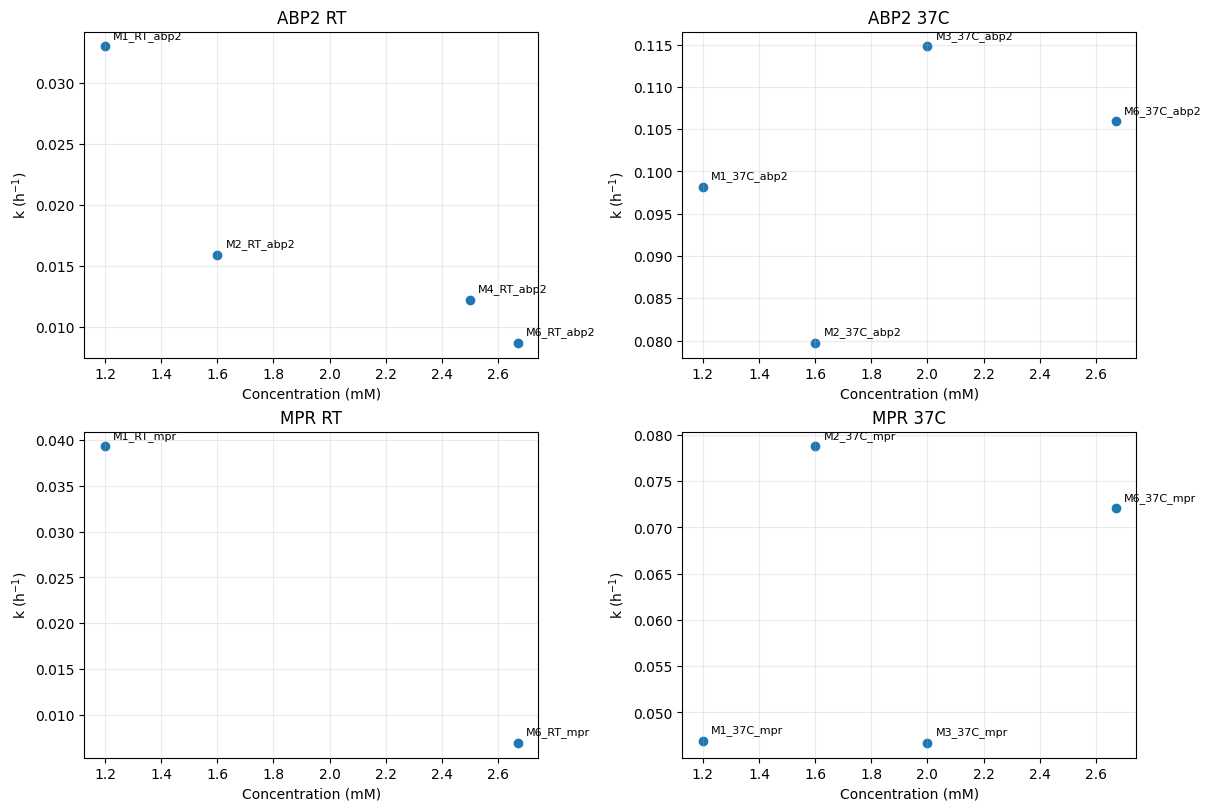

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Fill from your table (only the k values you actually have)
data = [
    # sample, sensor, temp_label, C_mM, k_h1
    ("M1_RT",  "ABP2", "RT",  1.2,  0.0330),
    ("M2_RT",  "ABP2", "RT",  1.6,  0.0159),
    ("M4_RT",  "ABP2", "RT",  2.5,  0.0122),
    ("M6_RT",  "ABP2", "RT",  2.67, 0.0087),

    ("M1_RT",  "MPR",  "RT",  1.2,  0.0393),
    ("M6_RT",  "MPR",  "RT",  2.67, 0.006921),

    ("M1_37C", "ABP2", "37C", 1.2,  0.09818),
    ("M2_37C", "ABP2", "37C", 1.6,  0.07972),
    ("M3_37C", "ABP2", "37C", 2.0,  0.11477),
    ("M6_37C", "ABP2", "37C", 2.67, 0.105906),

    ("M1_37C", "MPR",  "37C", 1.2,  0.04689),
    ("M2_37C", "MPR",  "37C", 1.6,  0.07874),
    ("M3_37C", "MPR",  "37C", 2.0,  0.04671),
    ("M6_37C", "MPR",  "37C", 2.67, 0.072045),
]

# Split by sensor+temp for clean plots
groups = {
    ("ABP2","RT"): [],
    ("ABP2","37C"): [],
    ("MPR","RT"): [],
    ("MPR","37C"): [],
}
for row in data:
    sample, sensor, temp, C, k = row
    groups[(sensor, temp)].append((sample, C, k))

def plot_group(ax, pts, title):
    Cs = [p[1] for p in pts]
    ks = [p[2] for p in pts]
    ax.scatter(Cs, ks)
    for sample, C, k in pts:
        ax.annotate(f"{sample}_{title.split()[0].lower()}",
                    (C, k),
                    textcoords="offset points",
                    xytext=(6, 6),
                    fontsize=8)
    ax.set_xlabel("Concentration (mM)")
    ax.set_ylabel("k (h$^{-1}$)")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

plot_group(axes[0,0], groups[("ABP2","RT")],  "ABP2 RT")
plot_group(axes[0,1], groups[("ABP2","37C")], "ABP2 37C")
plot_group(axes[1,0], groups[("MPR","RT")],  "MPR RT")
plot_group(axes[1,1], groups[("MPR","37C")], "MPR 37C")

plt.show()


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Fill these from your table
# ----------------------------
points = [
    # sample, temp_label, C_mM, k_abp2, k_mpr
    ("M1", "RT", 1.2, 0.0330,   0.0393),
    ("M2", "RT", 1.6, 0.0159,   np.nan),
    ("M4", "RT", 2.5, 0.0122,   np.nan),
    

    ("M1", "37C", 1.2, 0.09818, 0.04689),
    ("M2", "37C", 1.6, 0.07972, 0.07874),
    ("M3", "37C", 2.0, 0.11477, 0.04671),
    
]

# ----------------------------
# Plot helper
# ----------------------------
def plot_k_vs_conc(points, temp_label, sensor_key, title, out_png=None):
    # sensor_key: 3 for ABP2, 4 for MPR (index in points tuple)
    xs, ys, labels = [], [], []
    for s, t, c, kA, kM in points:
        if t != temp_label:
            continue
        k = kA if sensor_key == "ABP2" else kM
        if k is None or (isinstance(k, float) and np.isnan(k)):
            continue
        xs.append(float(c))
        ys.append(float(k))
        labels.append(f"{s}_{t}_{sensor_key.lower()}")

    xs = np.array(xs, dtype=float)
    ys = np.array(ys, dtype=float)

    plt.figure(figsize=(7.5, 5))
    plt.scatter(xs, ys)

    # simple label placement with small offsets (prevents hiding dots a bit)
    for x, y, lab in zip(xs, ys, labels):
        plt.annotate(lab, (x, y), textcoords="offset points", xytext=(6, 6), fontsize=8)

    # fit line (only if >=2 points)
    if len(xs) >= 2:
        m, b = np.polyfit(xs, ys, 1)  # y = m x + b
        xline = np.linspace(xs.min(), xs.max(), 100)
        yline = m * xline + b
        plt.plot(xline, yline, linestyle="--", label=f"fit: k = {m:.4g}·C + {b:.4g}")
        plt.legend()

    plt.xlabel("Concentration (mM)")
    plt.ylabel("k (h$^{-1}$)")
    plt.title(title)
    plt.tight_layout()
    if out_png:
        plt.savefig(out_png, dpi=200)
        plt.close()
    else:
        plt.show()


# ----------------------------
# 4 separate plots
# ----------------------------
plot_k_vs_conc(points, "RT",  "ABP2", "k vs Concentration — ABP2 (RT)",  out_png="k_vs_C_ABP2_RT.png")
plt.tight_layout()
plt.show()
plot_k_vs_conc(points, "RT",  "MPR",  "k vs Concentration — MPR (RT)",   out_png="k_vs_C_MPR_RT.png")
plot_k_vs_conc(points, "37C", "ABP2", "k vs Concentration — ABP2 (37C)", out_png="k_vs_C_ABP2_37C.png")
plot_k_vs_conc(points, "37C", "MPR",  "k vs Concentration — MPR (37C)",  out_png="k_vs_C_MPR_37C.png")

# print("Saved:\n- k_vs_C_ABP2_RT.png\n- k_vs_C_MPR_RT.png\n- k_vs_C_ABP2_37C.png\n- k_vs_C_MPR_37C.png")



<Figure size 640x480 with 0 Axes>

# Trying to model k as a function of C and T

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C

CSV_FOLDER = r"C:\Users\chand\Documents\GitHub\Thesis\csv_combi"
OUT_FOLDER = os.path.join(CSV_FOLDER, "k_vs_concentration_regression")
os.makedirs(OUT_FOLDER, exist_ok=True)

EXCLUDE_SAMPLES = set()  # e.g. {"M6"}

# (sample_id, C_mM, k_h-1)
DATA = {
    ("RT",  "ABP2"): [
        ("M1", 1.2,  0.0330),
        ("M2", 1.6,  0.0159),
        ("M4", 2.5,  0.0122),
        ("M6", 2.67, 0.0087),
    ],
    ("RT",  "MPR"): [
        ("M1", 1.2,  0.03930),
        ("M6", 2.67, 0.006921),
    ],
    ("37C", "ABP2"): [
        ("M1", 1.2,  0.09818),
        ("M2", 1.6,  0.07972),
        ("M3", 2.0,  0.11477),
        ("M6", 2.67, 0.105906),
    ],
    ("37C", "MPR"): [
        ("M1", 1.2,  0.04689),
        ("M2", 1.6,  0.07874),
        ("M3", 2.0,  0.04671),
        ("M6", 2.67, 0.072045),
    ],
}

def annotate_points(ax, xs, ys, labels):
    for i, (x, y, lab) in enumerate(zip(xs, ys, labels)):
        dx = 8 if (i % 2 == 0) else -8
        dy = 6 if (i % 3 == 0) else -6
        ax.annotate(
            lab,
            (x, y),
            textcoords="offset points",
            xytext=(dx, dy),
            ha="left" if dx > 0 else "right",
            va="bottom" if dy > 0 else "top",
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7),
        )

def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return np.nan
    return float(1.0 - ss_res / ss_tot)

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def fit_linear(X, y):
    model = LinearRegression().fit(X, y)
    a = float(model.coef_[0])
    b = float(model.intercept_)
    return model, a, b

def fit_gpr(X, y):
    kernel = (
        C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.3, length_scale_bounds=(1e-2, 1e2))
        + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-12, 1e-1))
    )
    gpr = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=0,
    )
    gpr.fit(X, y)
    return gpr

def loocv_rmse_linear(X, y):
    n = len(y)
    preds = np.zeros(n, float)
    for i in range(n):
        idx = np.arange(n) != i
        m, _, _ = fit_linear(X[idx], y[idx])
        preds[i] = m.predict(X[i:i+1])[0]
    return rmse(y, preds)

def loocv_rmse_gpr(X, y):
    n = len(y)
    preds = np.zeros(n, float)
    for i in range(n):
        idx = np.arange(n) != i
        g = fit_gpr(X[idx], y[idx])
        preds[i] = g.predict(X[i:i+1])[0]
    return rmse(y, preds)

def plot_regime(temp_label, sensor, rows):
    rows = [r for r in rows if r[0] not in EXCLUDE_SAMPLES]
    if len(rows) < 2:
        return

    labels = [f"{sid}_{temp_label}_{sensor.lower()}" for (sid, _, _) in rows]
    C_vals = np.array([c for (_, c, _) in rows], float)
    k_vals = np.array([k for (_, _, k) in rows], float)

    X = C_vals.reshape(-1, 1)
    y = k_vals

    x_min, x_max = float(C_vals.min()), float(C_vals.max())
    x_pad = 0.08 * (x_max - x_min) if (x_max - x_min) > 0 else 0.1
    x_grid = np.linspace(x_min - x_pad, x_max + x_pad, 200)
    X_grid = x_grid.reshape(-1, 1)

    lin_model, a, b = fit_linear(X, y)
    y_lin = lin_model.predict(X)
    y_lin_grid = lin_model.predict(X_grid)

    lin_r2 = r2_score(y, y_lin)
    lin_loocv = loocv_rmse_linear(X, y)

    use_gpr = len(rows) >= 3
    if use_gpr:
        gpr = fit_gpr(X, y)
        y_gpr = gpr.predict(X)
        y_gpr_mean, y_gpr_std = gpr.predict(X_grid, return_std=True)
        gpr_r2 = r2_score(y, y_gpr)
        gpr_loocv = loocv_rmse_gpr(X, y)
    else:
        y_gpr_mean = y_gpr_std = None
        gpr_r2 = gpr_loocv = None

    plt.figure(figsize=(8.5, 5.0))
    ax = plt.gca()

    ax.scatter(C_vals, k_vals, s=55)
    annotate_points(ax, C_vals, k_vals, labels)

    ax.plot(x_grid, y_lin_grid, "--", label=f"Linear: k = {a:.5f}·C + {b:.5f}")

    if use_gpr:
        ax.plot(x_grid, y_gpr_mean, "-", label="GPR mean")
        ax.fill_between(
            x_grid,
            y_gpr_mean - 1.96 * y_gpr_std,
            y_gpr_mean + 1.96 * y_gpr_std,
            alpha=0.2,
            label="GPR 95% CI",
        )

    # ---- Minimal metric box ----
    if use_gpr:
        metric_txt = (
            f"Linear:  R²={lin_r2:.3f}  LOOCV RMSE={lin_loocv:.4g}\n"
            f"GPR:     R²={gpr_r2:.3f}  LOOCV RMSE={gpr_loocv:.4g}"
        )
    else:
        metric_txt = f"Linear:  R²={lin_r2:.3f}  LOOCV RMSE={lin_loocv:.4g}\nGPR: (need ≥3 pts)"

    ax.text(
        0.02, 0.98,
        metric_txt,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.85),
    )

    ax.set_title(f"k vs Concentration — {sensor} ({temp_label})")
    ax.set_xlabel("Concentration (mM)")
    ax.set_ylabel("k (h$^{-1}$)")
    ax.legend()
    plt.tight_layout()

    out = os.path.join(OUT_FOLDER, f"k_vs_C_{temp_label}_{sensor}.png")
    plt.savefig(out, dpi=220)
    plt.close()

for (temp_label, sensor), rows in DATA.items():
    plot_regime(temp_label, sensor, rows)

print(f"Saved plots to: {OUT_FOLDER}")


c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\chand\Documents\Git

Saved plots to: C:\Users\chand\Documents\GitHub\Thesis\csv_combi\k_vs_concentration_regression


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneOut
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel


CSV_FOLDER = r"C:\Users\chand\Documents\GitHub\Thesis\csv_combi"
OUT_FOLDER = os.path.join(CSV_FOLDER, "ml_k_models")
os.makedirs(OUT_FOLDER, exist_ok=True)

TEMP_COL_K = "calibrated temperature (K)"
TEMP_COL_37C_C = "calibrated temperature (K)"


experiments = [
    # (sample, sensor, temp_label, C_mM, Vsol_ml, Vg_ml, csv_file)
    ("M1_RT",  "ABP2", "RT",  1.2,  6.0,  4.0,  "M1_RT_ABP2.csv"),
    ("M2_RT",  "ABP2", "RT",  1.6,  6.0,  4.0,  "M2_RT_ABP2.csv"),
    ("M4_RT",  "ABP2", "RT",  2.5,  6.0,  4.0,  "M4_RT_ABP2.csv"),
    ("M6_RT",  "ABP2", "RT",  2.67, 5.78, 4.22, "M6_RT_ABP2.csv"),

    ("M1_RT",  "MPR",  "RT",  1.2,  6.0,  4.0,  "M1_RT_MPR.csv"),
    ("M6_RT",  "MPR",  "RT",  2.67, 5.78, 4.22, "M6_RT_MPR.csv"),

    ("M1_37C", "ABP2", "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ("M2_37C", "ABP2", "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ("M3_37C", "ABP2", "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
    ("M6_37C", "ABP2", "37C", 2.67, 5.7,  4.3,  "M6_37C_ABP2_MPR.csv"),

    ("M1_37C", "MPR",  "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ("M2_37C", "MPR",  "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ("M3_37C", "MPR",  "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
    ("M6_37C", "MPR",  "37C", 2.67, 6.0,  4.0,  "M6_37C_ABP2_MPR.csv"),
]

K_VALUES = {
    ("M1_RT",  "ABP2"): 0.0330,
    ("M2_RT",  "ABP2"): 0.0159,
    ("M4_RT",  "ABP2"): 0.0122,
    ("M6_RT",  "ABP2"): 0.0087,
    ("M1_RT",  "MPR") : 0.03930,
    ("M6_RT",  "MPR") : 0.006921,

    ("M1_37C", "ABP2"): 0.09818,
    ("M1_37C", "MPR") : 0.04689,

    ("M2_37C", "ABP2"): 0.07972,
    ("M2_37C", "MPR") : 0.07874,

    ("M3_37C", "ABP2"): 0.11477,
    ("M3_37C", "MPR") : 0.04671,

    ("M6_37C", "ABP2"): 0.105906,   # use your updated ones if different
    ("M6_37C", "MPR") : 0.072045,
}


def load_mean_T(csv_file, temp_label):
    df = pd.read_csv(os.path.join(CSV_FOLDER, csv_file))
    if temp_label == "RT":
        Tk = df[TEMP_COL_K].astype(float).values
    else:
        Tk = df[TEMP_COL_37C_C].astype(float).values + 273.15
    return float(np.mean(Tk))


rows = []
for (sample, sensor, temp_label, C_mM, Vsol_ml, Vg_ml, csv_file) in experiments:
    k = K_VALUES.get((sample, sensor), None)
    if k is None:
        raise ValueError(f"Missing k for {(sample, sensor)} in K_VALUES")
    Tmean = load_mean_T(csv_file, temp_label)
    rows.append({
        "sample": sample,
        "sensor": sensor,
        "temp_label": temp_label,
        "C_mM": float(C_mM),
        "T_mean_K": float(Tmean),
        "Vsol_ml": float(Vsol_ml),
        "Vg_ml": float(Vg_ml),
        "Vratio": float(Vsol_ml / Vg_ml),
        "k": float(k),
        "id": f"{sample}_{sensor}".replace(" ", "")
    })

dfk = pd.DataFrame(rows)
dfk.to_csv(os.path.join(OUT_FOLDER, "k_dataset.csv"), index=False)


FEATURE_COLS_NUM = ["C_mM", "T_mean_K", "Vratio"]
FEATURE_COLS_CAT = ["sensor", "temp_label"]


X = dfk[FEATURE_COLS_NUM + FEATURE_COLS_CAT].copy()
y = dfk["k"].values.astype(float)


pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("sc", StandardScaler())]), FEATURE_COLS_NUM),
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURE_COLS_CAT),
    ],
    remainder="drop"
)


def loocv_predict(model, X, y):
    loo = LeaveOneOut()
    yhat = np.zeros_like(y, dtype=float)
    for train_idx, test_idx in loo.split(X):
        model.fit(X.iloc[train_idx], y[train_idx])
        yhat[test_idx[0]] = float(model.predict(X.iloc[test_idx])[0])
    return yhat


def metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2


ridge = Pipeline([
    ("pre", pre),
    ("mdl", Ridge(alpha=1.0))
])

kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e-1))
gpr = Pipeline([
    ("pre", pre),
    ("mdl", GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=10, random_state=0))
])


yhat_ridge = loocv_predict(ridge, X, y)
yhat_gpr   = loocv_predict(gpr, X, y)

rmse_r, mae_r, r2_r = metrics(y, yhat_ridge)
rmse_g, mae_g, r2_g = metrics(y, yhat_gpr)

ridge.fit(X, y)
gpr.fit(X, y)
r2_train_r = ridge.score(X, y)
r2_train_g = gpr.score(X, y)

summary = pd.DataFrame([{
    "model": "Ridge",
    "train_R2": r2_train_r,
    "LOOCV_RMSE": rmse_r,
    "LOOCV_MAE": mae_r,
    "LOOCV_R2": r2_r
},{
    "model": "GPR",
    "train_R2": r2_train_g,
    "LOOCV_RMSE": rmse_g,
    "LOOCV_MAE": mae_g,
    "LOOCV_R2": r2_g
}])
print(summary)
summary.to_csv(os.path.join(OUT_FOLDER, "ml_metrics.csv"), index=False)


def plot_pred_vs_true(y_true, preds, title, outpath, labels):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, preds)
    for yt, yp, lab in zip(y_true, preds, labels):
        plt.text(yt, yp, lab, fontsize=8, ha="left", va="bottom")
    lo = min(np.min(y_true), np.min(preds))
    hi = max(np.max(y_true), np.max(preds))
    plt.plot([lo, hi], [lo, hi], "--")
    plt.xlabel("True k")
    plt.ylabel("Predicted k (LOOCV)")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(outpath, dpi=200)
    plt.close()


plot_pred_vs_true(y, yhat_ridge, f"Ridge LOOCV (RMSE={rmse_r:.4g})",
                  os.path.join(OUT_FOLDER, "pred_vs_true_ridge.png"), dfk["id"].tolist())

plot_pred_vs_true(y, yhat_gpr, f"GPR LOOCV (RMSE={rmse_g:.4g})",
                  os.path.join(OUT_FOLDER, "pred_vs_true_gpr.png"), dfk["id"].tolist())


def gpr_curve_over_C(temp_label, sensor):
    sub = dfk[(dfk["temp_label"] == temp_label) & (dfk["sensor"] == sensor)].copy()
    if len(sub) < 2:
        return

    Cmin, Cmax = float(sub["C_mM"].min()), float(sub["C_mM"].max())
    Cgrid = np.linspace(Cmin, Cmax, 200)

    Tmean = float(sub["T_mean_K"].mean())
    Vratio = float(sub["Vratio"].mean())

    Xgrid = pd.DataFrame({
        "C_mM": Cgrid,
        "T_mean_K": np.full_like(Cgrid, Tmean),
        "Vratio": np.full_like(Cgrid, Vratio),
        "sensor": [sensor]*len(Cgrid),
        "temp_label": [temp_label]*len(Cgrid)
    })

    pre_Xgrid = gpr.named_steps["pre"].transform(Xgrid)
    pre_Xsub  = gpr.named_steps["pre"].transform(sub[FEATURE_COLS_NUM + FEATURE_COLS_CAT])

    mu, std = gpr.named_steps["mdl"].predict(pre_Xgrid, return_std=True)

    plt.figure(figsize=(9, 5))
    plt.scatter(sub["C_mM"], sub["k"], s=80)
    for _, r in sub.iterrows():
        plt.text(r["C_mM"], r["k"], r["id"], fontsize=9, ha="left", va="bottom")

    plt.plot(Cgrid, mu)
    plt.fill_between(Cgrid, mu - 1.96*std, mu + 1.96*std, alpha=0.2)

    txt = (f"Ridge LOOCV RMSE={rmse_r:.4g}\n"
           f"GPR   LOOCV RMSE={rmse_g:.4g}")
    plt.gca().text(0.02, 0.98, txt, transform=plt.gca().transAxes, va="top",
                   bbox=dict(boxstyle="round", alpha=0.2))

    plt.xlabel("Concentration (mM)")
    plt.ylabel("k (h$^{-1}$)")
    plt.title(f"GPR k(C) — {sensor} ({temp_label})  (T≈{Tmean:.1f}K, Vsol/Vg≈{Vratio:.2f})")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_FOLDER, f"gpr_curve_{sensor}_{temp_label}.png"), dpi=200)
    plt.close()


for temp_label in ["RT", "37C"]:
    for sensor in ["ABP2", "MPR"]:
        gpr_curve_over_C(temp_label, sensor)

print(f"Saved to: {OUT_FOLDER}")


c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\chand\Documents\GitHub\Th

   model  train_R2  LOOCV_RMSE  LOOCV_MAE  LOOCV_R2
0  Ridge  0.838138    0.021263   0.018132  0.651570
1    GPR  0.917995    0.024997   0.021249  0.518445
Saved to: C:\Users\chand\Documents\GitHub\Thesis\csv_combi\ml_k_models


# Comparison between Ridge regression vs GPR and how it performs in comprison with mathematical model predictions on a leave one out sample

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as Ck

CSV_FOLDER = r"C:\Users\chand\Documents\GitHub\Thesis\csv_combi"
OUT_FOLDER = os.path.join(CSV_FOLDER, "loo_pressure_with_ml_k")
os.makedirs(OUT_FOLDER, exist_ok=True)

TIME_COL = "Time (h)"
TEMP_COL_K = "calibrated temperature (K)"
TEMP_COL_37C_C = "calibrated temperature (K)"

PRESS_COL_RT_ABP2 = "ABP2 DWT denoised pressure (kPa)"
PRESS_COL_RT_MPR  = "MPR SG pressure (kPa)"
PRESS_COL_37C_ABP2 = "ABP2 SG smoothed pressure (kPa)"
PRESS_COL_37C_MPR  = "MPR SG smoothed pressure (kPa)"

R_J = 8.314

def ml_to_m3(ml):
    return ml * 1e-6

def mM_ml_to_mol(C_mM, V_ml):
    V_L = V_ml / 1000.0
    mmol = C_mM * V_L
    return mmol / 1000.0

battino_T  = np.array([273.15, 278.15, 283.15, 288.15, 293.15,
                       298.15, 303.15, 308.15, 313.15, 318.15,
                       323.15, 328.15, 333.15, 338.15, 343.15, 348.15])
battino_dH = np.array([-17.60, -16.18, -15.16, -14.15, -13.13,
                       -12.11, -11.10, -10.08,  -9.06,  -8.05,
                        -7.03,  -6.01,  -5.00,  -3.98,  -2.97,  -1.95])

kH_ref = 1.3e-3
T_ref  = 298.15
dH_ref = -12.11
R_GAS = 8.314
R_ATM = 0.082057

def interpolate_dH(Tk):
    return np.interp(Tk, battino_T, battino_dH)

def calc_kH(Tk):
    dH_T = interpolate_dH(Tk)
    dH_avg = (dH_ref + dH_T) / 2 * 1000
    return kH_ref * np.exp(-(dH_avg / R_GAS) * (1/Tk - 1/T_ref))

def gamma_from_T_series(Tk_series, Vsol_ml, Vg_ml):
    Tk_series = pd.Series(Tk_series)
    kH = Tk_series.apply(calc_kH)
    return (kH * R_ATM * Tk_series * (Vsol_ml / Vg_ml)).values.astype(float)

def P_model_eta(t, Tk, eta_hat, C_mM, Vsol_ml, Vg_ml, k):
    n_stoich = mM_ml_to_mol(C_mM, Vsol_ml)
    n_gas = eta_hat * n_stoich * (1 - np.exp(-k * t))
    P_Pa = (n_gas * R_J * Tk) / ml_to_m3(Vg_ml)
    return P_Pa / 1000.0

def P_model_beta(t, Tk, beta_hat, gamma_t, C_mM, Vsol_ml, Vg_ml, k):
    n_stoich = mM_ml_to_mol(C_mM, Vsol_ml)
    n_total = beta_hat * n_stoich * (1 - np.exp(-k * t))
    n_gas = n_total / (1.0 + gamma_t)
    P_Pa = (n_gas * R_J * Tk) / ml_to_m3(Vg_ml)
    return P_Pa / 1000.0

def get_pressure_col(temp_label, sensor):
    if temp_label == "RT":
        return PRESS_COL_RT_ABP2 if sensor == "ABP2" else PRESS_COL_RT_MPR
    return PRESS_COL_37C_ABP2 if sensor == "ABP2" else PRESS_COL_37C_MPR

def rmse(y, yhat):
    y = np.asarray(y); yhat = np.asarray(yhat)
    return float(np.sqrt(np.mean((y - yhat)**2)))

def mae(y, yhat):
    y = np.asarray(y); yhat = np.asarray(yhat)
    return float(np.mean(np.abs(y - yhat)))

def interp_k_piecewise(C_train, k_train, Cq):
    C_train = np.asarray(C_train, float)
    k_train = np.asarray(k_train, float)
    order = np.argsort(C_train)
    return float(np.interp(float(Cq), C_train[order], k_train[order]))

experiments = [
    ("M1_RT",  "ABP2", "RT",  1.2,  6.0,  4.0,  "M1_RT_ABP2.csv"),
    ("M2_RT",  "ABP2", "RT",  1.6,  6.0,  4.0,  "M2_RT_ABP2.csv"),
    ("M4_RT",  "ABP2", "RT",  2.5,  6.0,  4.0,  "M4_RT_ABP2.csv"),
    ("M6_RT",  "ABP2", "RT",  2.67, 5.78, 4.22, "M6_RT_ABP2.csv"),

    ("M1_RT",  "MPR",  "RT",  1.2,  6.0,  4.0,  "M1_RT_MPR.csv"),
    ("M6_RT",  "MPR",  "RT",  2.67, 5.78, 4.22, "M6_RT_MPR.csv"),

    ("M1_37C", "ABP2", "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ("M2_37C", "ABP2", "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ("M3_37C", "ABP2", "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
    ("M6_37C", "ABP2", "37C", 2.67, 5.7,  4.3,  "M6_37C_ABP2_MPR.csv"),

    ("M1_37C", "MPR",  "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ("M2_37C", "MPR",  "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ("M3_37C", "MPR",  "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
    ("M6_37C", "MPR",  "37C", 2.67, 6.0,  4.0,  "M6_37C_ABP2_MPR.csv"),
]

K_VALUES = {
    ("M1_RT",  "ABP2"): 0.0330,
    ("M2_RT",  "ABP2"): 0.0159,
    ("M4_RT",  "ABP2"): 0.0122,
    ("M6_RT",  "ABP2"): 0.0087,
    ("M1_RT",  "MPR") : 0.03930,
    ("M6_RT",  "MPR") : 0.006921,

    ("M1_37C", "ABP2"): 0.09818,
    ("M2_37C", "ABP2"): 0.07972,
    ("M3_37C", "ABP2"): 0.11477,
    ("M6_37C", "ABP2"): 0.105906,

    ("M1_37C", "MPR") : 0.04689,
    ("M2_37C", "MPR") : 0.07874,
    ("M3_37C", "MPR") : 0.04671,
    ("M6_37C", "MPR") : 0.072045,
}

rows = []
for (sample, sensor, temp_label, C_mM, Vsol_ml, Vg_ml, csv_file) in experiments:
    k = K_VALUES[(sample, sensor)]
    df = pd.read_csv(os.path.join(CSV_FOLDER, csv_file))

    P_col = get_pressure_col(temp_label, sensor)
    t = df[TIME_COL].values.astype(float)
    t = t - t[0]
    P_meas = df[P_col].values.astype(float)

    if temp_label == "RT":
        Tk = df[TEMP_COL_K].values.astype(float)
    else:
        Tk = (df[TEMP_COL_37C_C].values.astype(float) + 273.15)

    gamma_t = gamma_from_T_series(Tk, Vsol_ml, Vg_ml)

    P_end_kPa = float(np.max(P_meas))
    idx_end = int(np.argmax(P_meas))
    T_end = float(Tk[idx_end])
    gamma_end = float(gamma_t[idx_end])

    P_end_Pa = P_end_kPa * 1000.0
    n_gas_end = (P_end_Pa * ml_to_m3(Vg_ml)) / (R_J * T_end)

    n_stoich = mM_ml_to_mol(C_mM, Vsol_ml)
    eta_end = n_gas_end / n_stoich
    beta_end = eta_end * (1.0 + gamma_end)

    rows.append({
        "sample": sample, "sensor": sensor, "temp_label": temp_label,
        "C_mM": float(C_mM), "Vsol_ml": float(Vsol_ml), "Vg_ml": float(Vg_ml),
        "k": float(k), "eta_end": float(eta_end), "beta_end": float(beta_end),
        "csv": csv_file
    })

df_sum = pd.DataFrame(rows)

def fit_models_kC(C_train, k_train):
    X = np.asarray(C_train, float).reshape(-1, 1)
    y = np.asarray(k_train, float)

    ridge = Ridge(alpha=1e-6)
    ridge.fit(X, y)

    kernel = Ck(1.0, (1e-3, 1e3)) * RBF(length_scale=0.3, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
    gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=10, random_state=0)
    gpr.fit(X, y)

    return ridge, gpr

def predict_k_models(ridge, gpr, Cq):
    Xq = np.array([[float(Cq)]], float)
    k_ridge = float(ridge.predict(Xq)[0])
    k_gpr = float(gpr.predict(Xq)[0])
    return k_ridge, k_gpr

def load_timeseries(sample, sensor, temp_label, csv_file, Vsol_ml, Vg_ml):
    df = pd.read_csv(os.path.join(CSV_FOLDER, csv_file))
    P_col = get_pressure_col(temp_label, sensor)
    t = df[TIME_COL].values.astype(float)
    t = t - t[0]
    P_meas = df[P_col].values.astype(float)
    if temp_label == "RT":
        Tk = df[TEMP_COL_K].values.astype(float)
    else:
        Tk = (df[TEMP_COL_37C_C].values.astype(float) + 273.15)
    gamma_t = gamma_from_T_series(Tk, Vsol_ml, Vg_ml)
    return t, Tk, gamma_t, P_meas

test_samples = sorted(df_sum["sample"].unique())

results = []
for sensor in ["ABP2", "MPR"]:
    for temp_label in ["RT", "37C"]:
        df_grp = df_sum[(df_sum["sensor"] == sensor) & (df_sum["temp_label"] == temp_label)].copy()
        if len(df_grp) < 3:
            continue

        for test_sample in sorted(df_grp["sample"].unique()):
            df_train = df_grp[df_grp["sample"] != test_sample].copy()
            df_test  = df_grp[df_grp["sample"] == test_sample].copy()
            if len(df_test) != 1 or len(df_train) < 2:
                continue

            tr = df_test.iloc[0]
            C_test = float(tr["C_mM"])
            Vsol_ml = float(tr["Vsol_ml"])
            Vg_ml = float(tr["Vg_ml"])
            csv_test = tr["csv"]

            ridge, gpr = fit_models_kC(df_train["C_mM"], df_train["k"])
            k_interp = interp_k_piecewise(df_train["C_mM"], df_train["k"], C_test)
            k_ridge, k_gpr = predict_k_models(ridge, gpr, C_test)

            eta_hat = float(np.interp(C_test, np.sort(df_train["C_mM"].values), df_train.sort_values("C_mM")["eta_end"].values))
            beta_hat = float(np.interp(C_test, np.sort(df_train["C_mM"].values), df_train.sort_values("C_mM")["beta_end"].values))

            t, Tk, gamma_t, P_meas = load_timeseries(test_sample, sensor, temp_label, csv_test, Vsol_ml, Vg_ml)

            P_eta_interp  = P_model_eta(t, Tk, eta_hat, C_test, Vsol_ml, Vg_ml, k_interp)
            P_beta_interp = P_model_beta(t, Tk, beta_hat, gamma_t, C_test, Vsol_ml, Vg_ml, k_interp)

            P_eta_ridge   = P_model_eta(t, Tk, eta_hat, C_test, Vsol_ml, Vg_ml, k_ridge)
            P_beta_ridge  = P_model_beta(t, Tk, beta_hat, gamma_t, C_test, Vsol_ml, Vg_ml, k_ridge)

            P_eta_gpr     = P_model_eta(t, Tk, eta_hat, C_test, Vsol_ml, Vg_ml, k_gpr)
            P_beta_gpr    = P_model_beta(t, Tk, beta_hat, gamma_t, C_test, Vsol_ml, Vg_ml, k_gpr)

            def add_res(tag, yhat):
                results.append({
                    "test_sample": test_sample,
                    "sensor": sensor,
                    "temp_label": temp_label,
                    "method": tag,
                    "rmse": rmse(P_meas, yhat),
                    "mae": mae(P_meas, yhat),
                    "k_used": float({"interp": k_interp, "ridge": k_ridge, "gpr": k_gpr}[tag.split("_")[1]])
                })

            add_res("eta_interp", P_eta_interp)
            add_res("beta_interp", P_beta_interp)
            add_res("eta_ridge", P_eta_ridge)
            add_res("beta_ridge", P_beta_ridge)
            add_res("eta_gpr", P_eta_gpr)
            add_res("beta_gpr", P_beta_gpr)

            plt.figure(figsize=(10, 5))
            plt.plot(t, P_meas, label="Measured P")
            plt.plot(t, P_beta_interp, "--", label=f"β-model + k_interp ({k_interp:.4f})")
            plt.plot(t, P_beta_ridge,  "--", label=f"β-model + k_ridge ({k_ridge:.4f})")
            plt.plot(t, P_beta_gpr,    "--", label=f"β-model + k_gpr ({k_gpr:.4f})")
            plt.plot(t, P_eta_interp,  ":", label=f"η-model + k_interp")
            plt.plot(t, P_eta_ridge,   ":", label=f"η-model + k_ridge")
            plt.plot(t, P_eta_gpr,     ":", label=f"η-model + k_gpr")

            rmse_eta_i = rmse(P_meas, P_eta_interp)
            rmse_beta_i = rmse(P_meas, P_beta_interp)
            rmse_eta_r = rmse(P_meas, P_eta_ridge)
            rmse_beta_r = rmse(P_meas, P_beta_ridge)
            rmse_eta_g = rmse(P_meas, P_eta_gpr)
            rmse_beta_g = rmse(P_meas, P_beta_gpr)

            txt = (
                f"RMSE (interp): η={rmse_eta_i:.3f}, β={rmse_beta_i:.3f}\n"
                f"RMSE (ridge):  η={rmse_eta_r:.3f}, β={rmse_beta_r:.3f}\n"
                f"RMSE (gpr):    η={rmse_eta_g:.3f}, β={rmse_beta_g:.3f}"
            )
            plt.gca().text(0.02, 0.98, txt, transform=plt.gca().transAxes,
                           va="top", ha="left",
                           bbox=dict(boxstyle="round", alpha=0.2))

            plt.xlabel("Time (h)")
            plt.ylabel("Pressure (kPa)")
            plt.title(f"LOO Pressure: {test_sample} {sensor} ({temp_label})")
            plt.legend(loc="best")
            plt.tight_layout()
            out_png = os.path.join(OUT_FOLDER, f"loo_pressure_{test_sample}_{sensor}_{temp_label}.png")
            plt.savefig(out_png, dpi=200)
            plt.close()

df_res = pd.DataFrame(results)
df_res.to_csv(os.path.join(OUT_FOLDER, "loo_pressure_metrics.csv"), index=False)

print(df_res.sort_values(["sensor", "temp_label", "test_sample", "method"]))
print(f"\nSaved plots + metrics to: {OUT_FOLDER}")


c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\chand\D

   test_sample sensor temp_label       method      rmse       mae    k_used
29      M1_37C   ABP2        37C     beta_gpr  1.079780  1.012750  0.100132
25      M1_37C   ABP2        37C  beta_interp  0.958663  0.837317  0.079720
27      M1_37C   ABP2        37C   beta_ridge  0.972757  0.859077  0.081812
28      M1_37C   ABP2        37C      eta_gpr  1.079862  1.012833  0.100132
24      M1_37C   ABP2        37C   eta_interp  0.958738  0.837396  0.079720
..         ...    ...        ...          ...       ...       ...       ...
67      M6_37C    MPR        37C  beta_interp  1.211649  0.990519  0.046710
69      M6_37C    MPR        37C   beta_ridge  0.744438  0.583373  0.057206
70      M6_37C    MPR        37C      eta_gpr  0.735243  0.575847  0.057447
66      M6_37C    MPR        37C   eta_interp  1.211623  0.990496  0.046710
68      M6_37C    MPR        37C    eta_ridge  0.744411  0.583354  0.057206

[72 rows x 7 columns]

Saved plots + metrics to: C:\Users\chand\Documents\GitHub\Thesis

No it should work this way, graph between Graph 1: 1. eta + mean_K_37 and mean_k_37, 2. Measured P 3. beta + k_interpolated, 4. beta+ k_ridge and graph 2: 1. eta + mean_K_37 and mean_k_37, 2. Measured P 3. beta + k_interpolated, 4. beta+ k_gpr... all of this for onky 1 sample (eg sample M1) which is the test set (unseen). The k values of the rest of the samples should be used to compute this for M1 

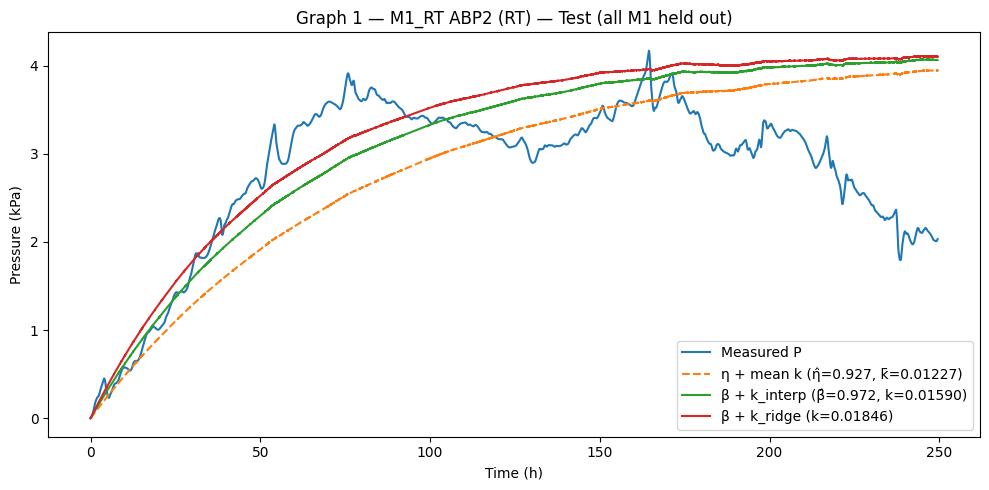

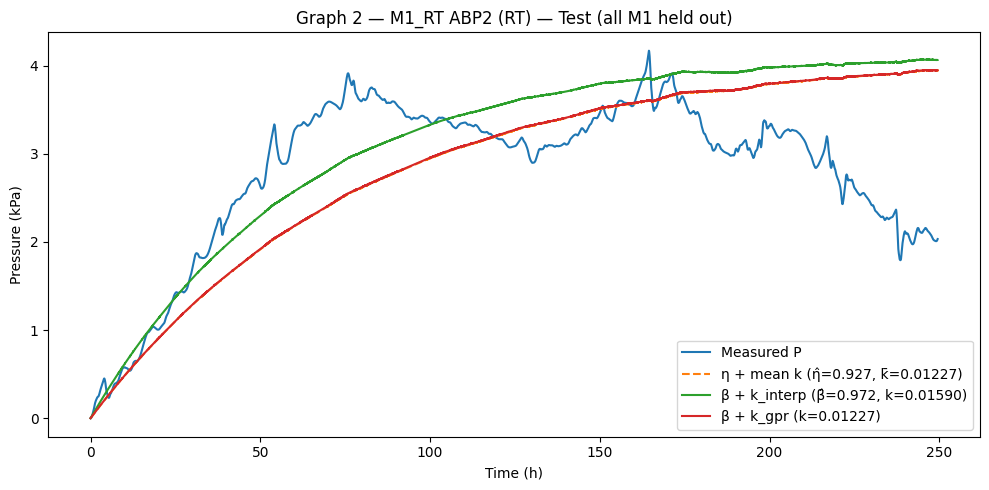

Skip M1_RT MPR RT: not enough training points.


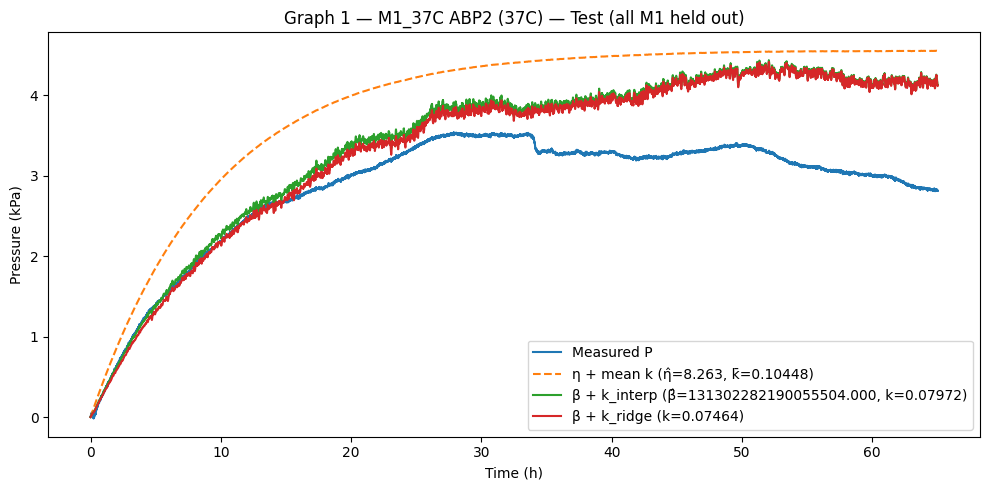

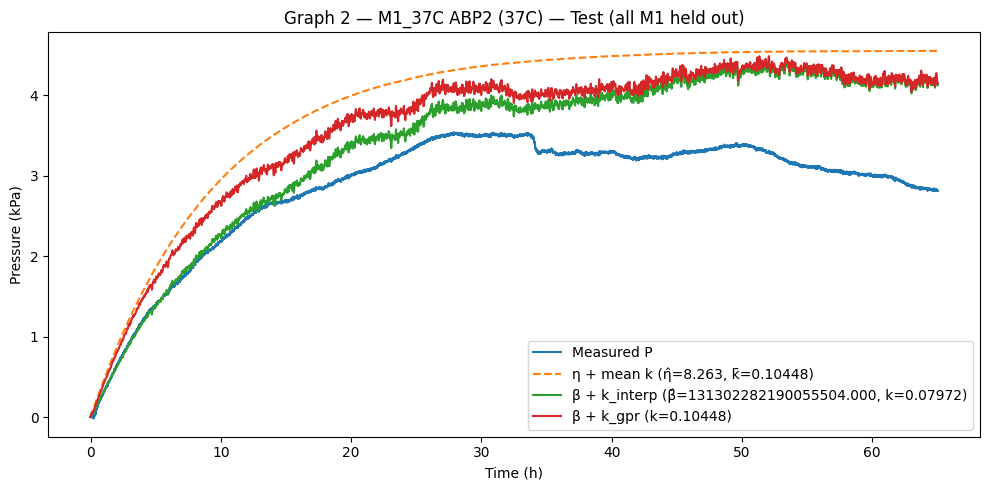

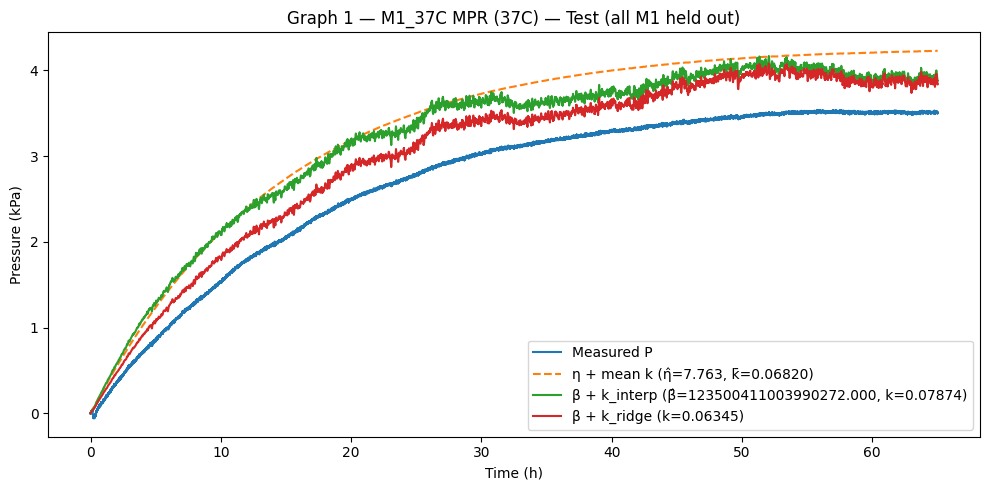

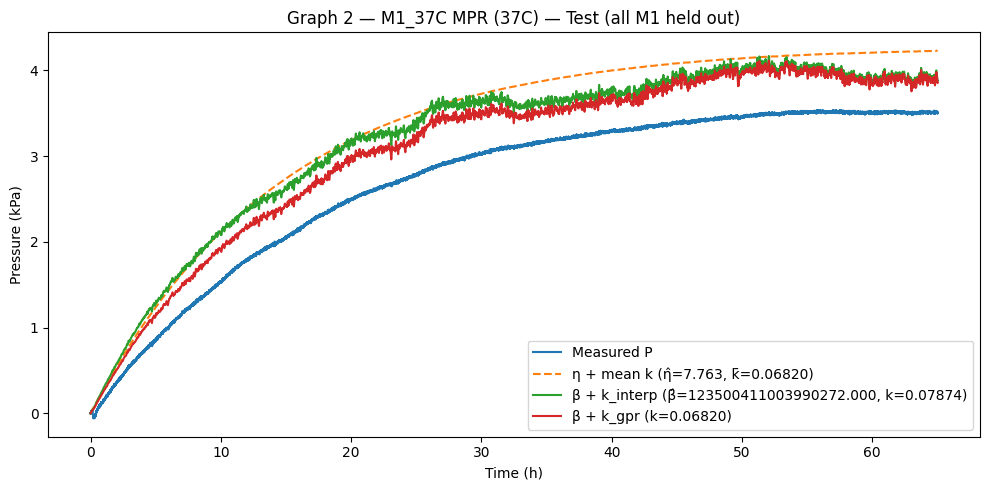

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel



CSV_FOLDER = r"C:\Users\chand\Documents\GitHub\Thesis\csv_combi"


TIME_COL = "Time (h)"
TEMP_COL_K = "calibrated temperature (K)"
TEMP_COL_37C = "calibrated temperature (K)"   #check this: set TEMP_37C_IS_K=False if this column is actually in °C :checked
TEMP_37C_IS_K = True
PRESS_COL_RT_ABP2  = "ABP2 DWT denoised pressure (kPa)"
PRESS_COL_RT_MPR   = "MPR SG pressure (kPa)"
PRESS_COL_37C_ABP2 = "ABP2 SG smoothed pressure (kPa)"
PRESS_COL_37C_MPR  = "MPR SG smoothed pressure (kPa)"

R_J = 8.314


def ml_to_m3(ml):
    return ml * 1e-6

def mM_ml_to_mol(C_mM, V_ml):  #to convert to moles
    V_L = V_ml / 1000.0
    mmol = C_mM * V_L
    return mmol / 1000.0

def mM_ml_to_umol(C_mM, V_ml):
    return C_mM * V_ml  # because mM == µmol/mL

def get_pressure_col(temp_label, sensor):
    if temp_label == "RT":
        return PRESS_COL_RT_ABP2 if sensor == "ABP2" else PRESS_COL_RT_MPR
    return PRESS_COL_37C_ABP2 if sensor == "ABP2" else PRESS_COL_37C_MPR

# from Battino et al. 1983, "The Solubility of Oxygen and Ozone in Liquids"
battino_T  = np.array([273.15, 278.15, 283.15, 288.15, 293.15,
                       298.15, 303.15, 308.15, 313.15, 318.15,
                       323.15, 328.15, 333.15, 338.15, 343.15, 348.15])

battino_dH = np.array([-17.60, -16.18, -15.16, -14.15, -13.13,
                       -12.11, -11.10, -10.08,  -9.06,  -8.05,
                        -7.03,  -6.01,  -5.00,  -3.98,  -2.97,  -1.95])

kH_ref = 1.3e-3
T_ref  = 298.15
dH_ref = -12.11
R_GAS  = 8.314
R_ATM  = 0.082057

def interpolate_dH(Tk):
    return np.interp(Tk, battino_T, battino_dH)

def calc_kH(Tk):             #computinh Henry’s constant at temperature Tk using  Van’t Hoff exponential relation.
    dH_T = interpolate_dH(Tk)
    dH_avg = (dH_ref + dH_T) / 2 * 1000.0
    return kH_ref * np.exp(-(dH_avg / R_GAS) * (1.0 / Tk - 1.0 / T_ref))

def gamma_from_T_series(Tk_series, Vsol_ml, Vg_ml):
    kH = Tk_series.apply(calc_kH)       #computes kH at each time point
    return kH * R_ATM * Tk_series * (Vsol_ml / Vg_ml)    # This is gamma from my calculations before computing beta



#pressure models
def P_model_eta(t, Tk, eta_hat, C_mM, Vsol_ml, Vg_ml, k):
    n_stoich_umol = mM_ml_to_umol(C_mM, Vsol_ml)
    n_gas_umol = eta_hat * n_stoich_umol * (1.0 - np.exp(-k * t))
    n_gas_mol = n_gas_umol * 1e-6  # IMPORTANT: µmol -> mol

    P_Pa = (n_gas_mol * R_J * Tk) / ml_to_m3(Vg_ml)
    return P_Pa / 1000.0

def P_model_beta(t, Tk, beta_hat, gamma_t, C_mM, Vsol_ml, Vg_ml, k):
    n_stoich_umol = mM_ml_to_umol(C_mM, Vsol_ml)
    n_total_umol = beta_hat * n_stoich_umol * (1.0 - np.exp(-k * t))
    n_gas_umol = n_total_umol / (1.0 + gamma_t)
    n_gas_mol = n_gas_umol * 1e-6
    P_Pa = (n_gas_mol * R_J * Tk) / ml_to_m3(Vg_ml)
    return P_Pa / 1000.0   #convert to kPa

#dataset values
experiments = [
    ("M1_RT",  "ABP2", False,  "RT",  1.2,  6.0,  4.0,  "M1_RT_ABP2.csv"),
    ("M2_RT",  "ABP2", False, "RT",  1.6,  6.0,  4.0,  "M2_RT_ABP2.csv"),
    ("M4_RT",  "ABP2", False, "RT",  2.5,  6.0,  4.0,  "M4_RT_ABP2.csv"),
    ("M6_RT",  "ABP2", True, "RT",  2.67, 5.78, 4.22, "M6_RT_ABP2.csv"),

    ("M1_RT",  "MPR",  False,  "RT",  1.2,  6.0,  4.0,  "M1_RT_MPR.csv"),
    ("M6_RT",  "MPR",  True, "RT",  2.67, 5.78, 4.22, "M6_RT_MPR.csv"),

    ("M1_37C", "ABP2", False,  "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ("M2_37C", "ABP2", False, "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ("M3_37C", "ABP2", False, "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
    ("M6_37C", "ABP2", True, "37C", 2.67, 5.7,  4.3,  "M6_37C_ABP2_MPR.csv"),

    ("M1_37C", "MPR",  False,  "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ("M2_37C", "MPR",  False, "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ("M3_37C", "MPR",  False, "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
    ("M6_37C", "MPR",  True, "37C", 2.67, 6.0,  4.0,  "M6_37C_ABP2_MPR.csv"),
]

#k per (sample,temp,sensor)
K_VALUES = {
    ("M1_RT",  "ABP2"): 0.0330,
    ("M2_RT",  "ABP2"): 0.0159,
    ("M4_RT",  "ABP2"): 0.0122,
    ("M6_RT",  "ABP2"): 0.0087,

    ("M1_RT",  "MPR") : 0.03930,
    ("M6_RT",  "MPR") : 0.006921,

    ("M1_37C", "ABP2"): 0.09818,
    ("M2_37C", "ABP2"): 0.07972,
    ("M3_37C", "ABP2"): 0.11477,
    ("M6_37C", "ABP2"): 0.118947,

    ("M1_37C", "MPR") : 0.04689,
    ("M2_37C", "MPR") : 0.07874,
    ("M3_37C", "MPR") : 0.04671,
    ("M6_37C", "MPR") : 0.079144,
}

#interpolate piecewise linearly (1D) for any x_query within the range of x_train
#This is used to estimate eta_end, beta_end, and k at a new concentration C_test.
def interp_piecewise(x_train, y_train, x_query):
    x = np.asarray(x_train, float)
    y = np.asarray(y_train, float)
    order = np.argsort(x)
    x = x[order]; y = y[order]
    return float(np.interp(float(x_query), x, y))

#
rows = []
for (sample, sensor, is_test, temp_label, C_mM, Vsol_ml, Vg_ml, csv_file) in experiments:
    k = K_VALUES.get((sample, sensor), None)
    if k is None:
        raise ValueError(f"Missing k for {(sample, sensor)} in K_VALUES")

    df = pd.read_csv(os.path.join(CSV_FOLDER, csv_file))

    P_col = get_pressure_col(temp_label, sensor)
    t = df[TIME_COL].values.astype(float)
    t = t - t[0]
    P_meas = df[P_col].values.astype(float)
    P_meas = P_meas - P_meas[0]   # IMPORTANT: work in delta-pressure (kPa)

    if temp_label == "RT":
        Tk = df[TEMP_COL_K].values.astype(float)
    else:
        Tk_raw = df[TEMP_COL_37C].values.astype(float)
        Tk = Tk_raw if TEMP_37C_IS_K else (Tk_raw + 273.15)

    gamma_t = gamma_from_T_series(pd.Series(Tk), Vsol_ml, Vg_ml).values.astype(float)

    # peak / max values in the experiment
    idx_peak = int(np.argmax(P_meas))

    P_peak_kPa = float(P_meas[idx_peak])
    T_peak     = float(Tk[idx_peak])
    gamma_peak = float(gamma_t[idx_peak])

    # Convert peak pressure to gas moles (ideal gas law) -> mol
    P_peak_Pa = P_peak_kPa * 1000.0
    n_gas_peak_mol = (P_peak_Pa * ml_to_m3(Vg_ml)) / (R_J * T_peak)

    # Stoichiometric amount from C and Vsol -> µmol (because 1 mM == 1 µmol/mL)
    n_stoich_umol = mM_ml_to_umol(C_mM, Vsol_ml)

    # Make units consistent: convert gas mol -> µmol before forming ratios
    n_gas_peak_umol = n_gas_peak_mol * 1e6

    # End/peak parameters (dimensionless)
    eta_peak  = n_gas_peak_umol / n_stoich_umol          # gas fraction at peak
    beta_peak = eta_peak * (1.0 + gamma_peak)            # total fraction at peak (gas + dissolved)

    rows.append({
        "sample": sample,
        "sensor": sensor,
        "temp_label": temp_label,
        "is_test": is_test,   # True for M1* rows
        "C_mM": float(C_mM),
        "Vsol_ml": float(Vsol_ml),
        "Vg_ml": float(Vg_ml),
        "n_stoich_umol": float(n_stoich_umol),
        "k": float(k),
        "eta_peak": float(eta_peak),
        "beta_peak": float(beta_peak),
        "gamma_peak": float(gamma_peak),
        "csv": csv_file
    })

df_sum = pd.DataFrame(rows)

#he intention is: use non-M1 experiments as training, and test on M1.


def fit_k_models(df_train):
    X = df_train[["C_mM"]].values.astype(float)
    y = df_train["k"].values.astype(float)

    ridge = Ridge(alpha=1e-6)  
    '''
    *alpha is regularisation strength.Usually in the log space between 1e-6 and 1e3. Later
    # I can explore which alpha gives the best val score using RidgeCV and use it instead! BUT this is for later.
    '''
    
    ridge.fit(X, y)

    # reason to choose this kernel? 

    kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=0.5, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-1))
    
    '''constant kernel, from the ridge formula, c is 1 mostly and 1e-3 to -+3 bounds used by the optimizer when it 
    fits hyperparameters. if optimizer struggles, expand bounds
    length scale is initial l : how quickly the function can vary. if ismall , lines will be wiggly / rapid changes. 
    Try less than 0.1 later for less wiggly lines
    whitenoisekernel addsa lil noise to prevent GP from overfitting. its a slight variance added.
    
    Later: Try other kernels like RBF ,Matern, RationalQuadratic, or combinations to see if they capture the k vs C relationship better instead of
    constant kernel.
    
    '''
    gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=0)
    gpr.fit(X, y)

    return ridge, gpr

def predict_k_ridge(ridge, C):
    return float(ridge.predict(np.array([[float(C)]]))[0])

def predict_k_gpr(gpr, C):
    mu = float(gpr.predict(np.array([[float(C)]]), return_std=False)[0])
    return mu

# plot
test_rows = df_sum[df_sum["is_test"] == True].copy()



# Test loop to  evaluate on M1 rows
for _, tr in test_rows.iterrows():
    sensor = tr["sensor"]
    temp_label = tr["temp_label"]
    sample = tr["sample"]          # "M1_RT" or "M1_37C"
    csv_test = tr["csv"]
    C_test = float(tr["C_mM"])
    Vsol_ml = float(tr["Vsol_ml"])
    Vg_ml = float(tr["Vg_ml"])

    df_train = df_sum[
        (df_sum["is_test"] == False) &
        (df_sum["sensor"] == sensor) &
        (df_sum["temp_label"] == temp_label)
    ].copy()

    if len(df_train) < 2:
        print(f"Skip {sample} {sensor} {temp_label}: not enough training points.")
        continue

    mean_k = float(df_train["k"].mean())

    eta_hat = interp_piecewise(df_train["C_mM"], df_train["eta_peak"], C_test)
    beta_hat = interp_piecewise(df_train["C_mM"], df_train["beta_peak"], C_test)

    k_interp = interp_piecewise(df_train["C_mM"], df_train["k"], C_test)

    ridge, gpr = fit_k_models(df_train)
    k_ridge = predict_k_ridge(ridge, C_test)
    k_gpr   = predict_k_gpr(gpr, C_test)

    df = pd.read_csv(os.path.join(CSV_FOLDER, csv_test))
    P_col = get_pressure_col(temp_label, sensor)

    t = df[TIME_COL].values.astype(float)
    t = t - t[0]
    P_meas = df[P_col].values.astype(float)
    P_meas = P_meas - P_meas[0]   # IMPORTANT: plot delta-pressure

    if temp_label == "RT":
        Tk = df[TEMP_COL_K].values.astype(float)
    else:
        Tk_raw = df[TEMP_COL_37C].values.astype(float)
        Tk = Tk_raw if TEMP_37C_IS_K else (Tk_raw + 273.15)

    gamma_t = gamma_from_T_series(pd.Series(Tk), Vsol_ml, Vg_ml).values.astype(float)

    P_eta_meanK     = P_model_eta(t, Tk, eta_hat, C_test, Vsol_ml, Vg_ml, mean_k)
    P_beta_kinterp  = P_model_beta(t, Tk, beta_hat, gamma_t, C_test, Vsol_ml, Vg_ml, k_interp)
    P_beta_kridge   = P_model_beta(t, Tk, beta_hat, gamma_t, C_test, Vsol_ml, Vg_ml, k_ridge)
    P_beta_kgpr     = P_model_beta(t, Tk, beta_hat, gamma_t, C_test, Vsol_ml, Vg_ml, k_gpr)

    title_base = f"{sample} {sensor} ({temp_label}) — Test (all M1 held out)"

    # Graph 1: eta+meanK, measured, beta+k_interp, beta+k_ridge
    plt.figure(figsize=(10, 5))
    plt.plot(t, P_meas, label="Measured P")
    plt.plot(t, P_eta_meanK, "--", label=f"η + mean k (η̂={eta_hat:.3f}, k̄={mean_k:.5f})")
    plt.plot(t, P_beta_kinterp, "-", label=f"β + k_interp (β̂={beta_hat:.3f}, k={k_interp:.5f})")
    plt.plot(t, P_beta_kridge, "-", label=f"β + k_ridge (k={k_ridge:.5f})")
    plt.xlabel("Time (h)")
    plt.ylabel("Pressure (kPa)")
    plt.title("Graph 1 — " + title_base)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Graph 2: eta+meanK, measured, beta+k_interp, beta+k_gpr
    plt.figure(figsize=(10, 5))
    plt.plot(t, P_meas, label="Measured P")
    plt.plot(t, P_eta_meanK, "--", label=f"η + mean k (η̂={eta_hat:.3f}, k̄={mean_k:.5f})")
    plt.plot(t, P_beta_kinterp, "-", label=f"β + k_interp (β̂={beta_hat:.3f}, k={k_interp:.5f})")
    plt.plot(t, P_beta_kgpr, "-", label=f"β + k_gpr (k={k_gpr:.5f})")
    plt.xlabel("Time (h)")
    plt.ylabel("Pressure (kPa)")
    plt.title("Graph 2 — " + title_base)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Trying M6 as test set now


================ SUMMARY TABLE ================

    sample sample_prefix sensor temp_label  C_mM  Vsol_ml  Vg_ml  \
0    M1_RT            M1   ABP2         RT  1.20     6.00   4.00   
1    M2_RT            M2   ABP2         RT  1.60     6.00   4.00   
2    M4_RT            M4   ABP2         RT  2.50     6.00   4.00   
3    M6_RT            M6   ABP2         RT  2.67     5.78   4.22   
4    M1_RT            M1    MPR         RT  1.20     6.00   4.00   
5    M6_RT            M6    MPR         RT  2.67     5.78   4.22   
6   M1_37C            M1   ABP2        37C  1.20     6.00   4.00   
7   M2_37C            M2   ABP2        37C  1.60     6.00   4.00   
8   M3_37C            M3   ABP2        37C  2.00     6.00   4.00   
9   M6_37C            M6   ABP2        37C  2.67     5.70   4.30   
10  M1_37C            M1    MPR        37C  1.20     6.00   4.00   
11  M2_37C            M2    MPR        37C  1.60     6.00   4.00   
12  M3_37C            M3    MPR        37C  2.00     6.00   4.00  

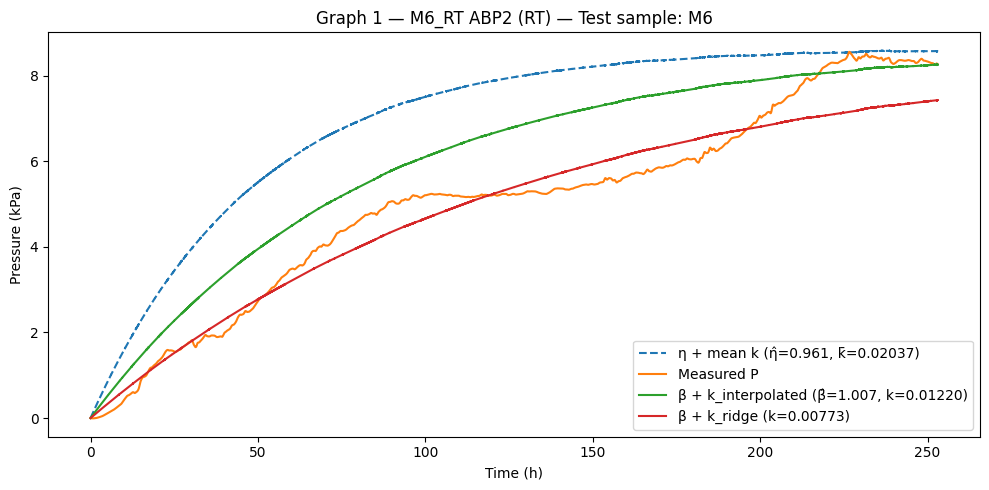

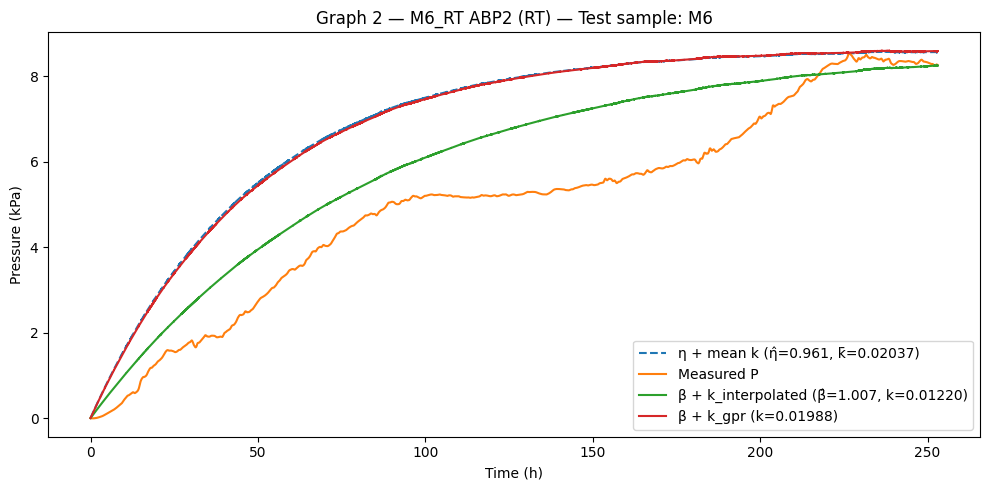


Skip M6_RT MPR RT: not enough training points.
Need at least 2 non-test samples for interpolation/model fitting.


c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



UNSEEN TEST SAMPLE: M6_37C | Sensor=ABP2 | Temp=37C
Training samples used:
   sample sensor temp_label  C_mM        k  eta_peak  beta_peak
6  M1_37C   ABP2        37C   1.2  0.09818  0.762828   0.794806
7  M2_37C   ABP2        37C   1.6  0.07972  0.983285   1.024493
8  M3_37C   ABP2        37C   2.0  0.11477  0.901824   0.939632

Predicted parameters for M6_37C:
  C_test      = 2.67000 mM
  eta_hat     = 0.901824
  beta_hat    = 0.939632
  mean_k      = 0.097557
  k_interp    = 0.114770
  k_ridge     = 0.119746
  k_gpr       = 0.097557


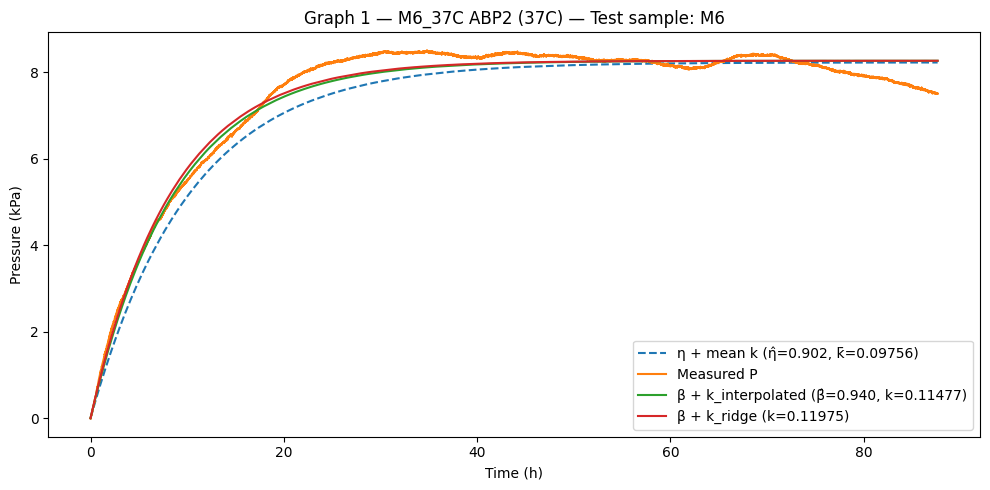

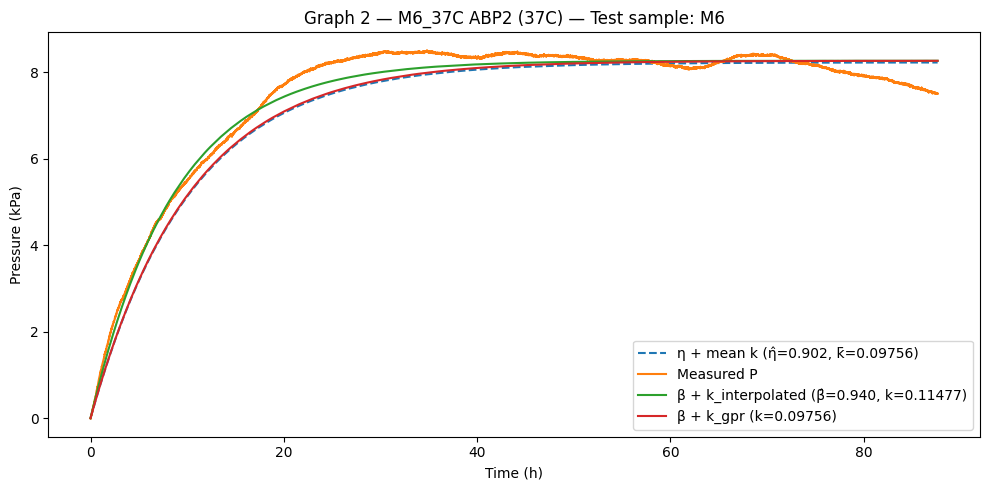

c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



UNSEEN TEST SAMPLE: M6_37C | Sensor=MPR | Temp=37C
Training samples used:
    sample sensor temp_label  C_mM        k  eta_peak  beta_peak
10  M1_37C    MPR        37C   1.2  0.04689  0.762497   0.794461
11  M2_37C    MPR        37C   1.6  0.07874  0.923696   0.962407
12  M3_37C    MPR        37C   2.0  0.04671  0.971480   1.012203

Predicted parameters for M6_37C:
  C_test      = 2.67000 mM
  eta_hat     = 0.971480
  beta_hat    = 1.012203
  mean_k      = 0.057447
  k_interp    = 0.046710
  k_ridge     = 0.057206
  k_gpr       = 0.057447


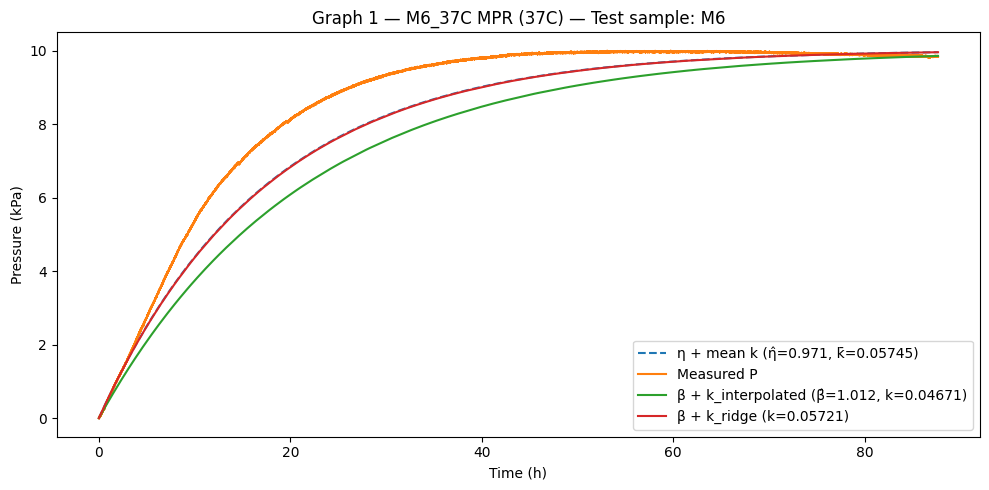

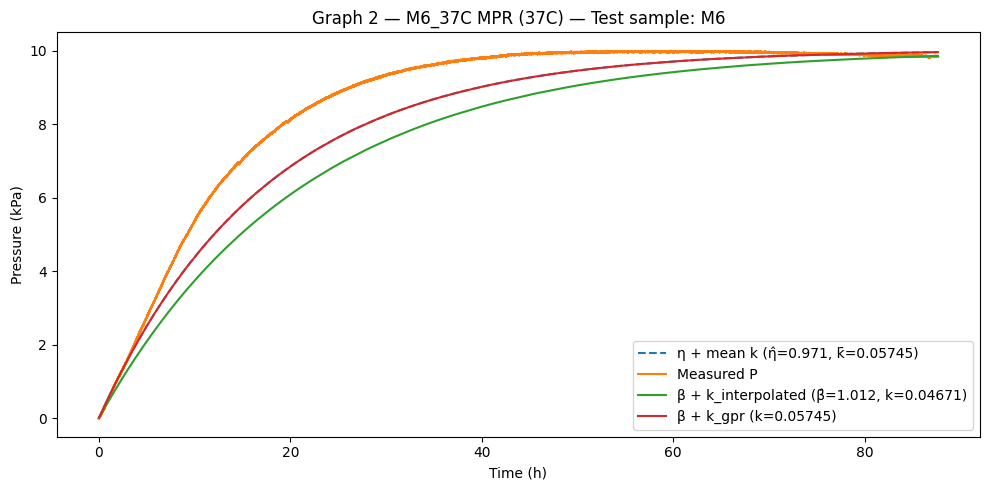

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel


# =========================
# USER SETTINGS
# =========================
CSV_FOLDER = r"C:\Users\chand\Documents\GitHub\Thesis\csv_combi"

TIME_COL = "Time (h)"
TEMP_COL_K = "calibrated temperature (K)"
TEMP_COL_37C = "calibrated temperature (K)"   # set TEMP_37C_IS_K=False if actually in °C


PRESS_COL_RT_ABP2  = "ABP2 DWT denoised pressure (kPa)"
PRESS_COL_RT_MPR   = "MPR SG pressure (kPa)"
PRESS_COL_37C_ABP2 = "ABP2 SG smoothed pressure (kPa)"
PRESS_COL_37C_MPR  = "MPR SG smoothed pressure (kPa)"

R_J = 8.314
R_GAS = 8.314
R_ATM = 0.082057

# Choose ONE unseen/test sample family here
# Examples: "M6", "M1", "M3"
TEST_SAMPLE_PREFIX = "M6"


# =========================
# HELPER FUNCTIONS
# =========================
def ml_to_m3(ml):
    return ml * 1e-6

def mM_ml_to_mol(C_mM, V_ml):
    V_L = V_ml / 1000.0
    mmol = C_mM * V_L
    return mmol / 1000.0

def mM_ml_to_umol(C_mM, V_ml):
    return C_mM * V_ml  # because mM == µmol/mL

def get_pressure_col(temp_label, sensor):
    if temp_label == "RT":
        return PRESS_COL_RT_ABP2 if sensor == "ABP2" else PRESS_COL_RT_MPR
    return PRESS_COL_37C_ABP2 if sensor == "ABP2" else PRESS_COL_37C_MPR


# =========================
# HENRY / BATTINO DATA
# =========================
# from Battino et al. 1983, "The Solubility of Oxygen and Ozone in Liquids"
battino_T  = np.array([273.15, 278.15, 283.15, 288.15, 293.15,
                       298.15, 303.15, 308.15, 313.15, 318.15,
                       323.15, 328.15, 333.15, 338.15, 343.15, 348.15])

battino_dH = np.array([-17.60, -16.18, -15.16, -14.15, -13.13,
                       -12.11, -11.10, -10.08,  -9.06,  -8.05,
                        -7.03,  -6.01,  -5.00,  -3.98,  -2.97,  -1.95])

kH_ref = 1.3e-3
T_ref  = 298.15
dH_ref = -12.11

def interpolate_dH(Tk):
    return np.interp(Tk, battino_T, battino_dH)

def calc_kH(Tk):
    dH_T = interpolate_dH(Tk)
    dH_avg = (dH_ref + dH_T) / 2 * 1000.0
    return kH_ref * np.exp(-(dH_avg / R_GAS) * (1.0 / Tk - 1.0 / T_ref))

def gamma_from_T_series(Tk_series, Vsol_ml, Vg_ml):
    kH = Tk_series.apply(calc_kH)
    return kH * R_ATM * Tk_series * (Vsol_ml / Vg_ml)


# =========================
# PRESSURE MODELS
# =========================
def P_model_eta(t, Tk, eta_hat, C_mM, Vsol_ml, Vg_ml, k):
    n_stoich_umol = mM_ml_to_umol(C_mM, Vsol_ml)
    n_gas_umol = eta_hat * n_stoich_umol * (1.0 - np.exp(-k * t))
    n_gas_mol = n_gas_umol * 1e-6
    P_Pa = (n_gas_mol * R_J * Tk) / ml_to_m3(Vg_ml)
    return P_Pa / 1000.0

def P_model_beta(t, Tk, beta_hat, gamma_t, C_mM, Vsol_ml, Vg_ml, k):
    n_stoich_umol = mM_ml_to_umol(C_mM, Vsol_ml)
    n_total_umol = beta_hat * n_stoich_umol * (1.0 - np.exp(-k * t))
    n_gas_umol = n_total_umol / (1.0 + gamma_t)
    n_gas_mol = n_gas_umol * 1e-6
    P_Pa = (n_gas_mol * R_J * Tk) / ml_to_m3(Vg_ml)
    return P_Pa / 1000.0


# =========================
# EXPERIMENT METADATA
# =========================
# IMPORTANT:
# - Put ALL available samples here
# - The code will automatically use only non-M6 rows for training
# - The code will use only M6 rows as unseen test rows
experiments = [
    ("M1_RT",  "ABP2", "RT",  1.2,  6.0,  4.0,  "M1_RT_ABP2.csv"),
    ("M2_RT",  "ABP2", "RT",  1.6,  6.0,  4.0,  "M2_RT_ABP2.csv"),
    ("M4_RT",  "ABP2", "RT",  2.5,  6.0,  4.0,  "M4_RT_ABP2.csv"),
    ("M6_RT",  "ABP2", "RT",  2.67, 5.78, 4.22, "M6_RT_ABP2.csv"),

    ("M1_RT",  "MPR",  "RT",  1.2,  6.0,  4.0,  "M1_RT_MPR.csv"),
    ("M6_RT",  "MPR",  "RT",  2.67, 5.78, 4.22, "M6_RT_MPR.csv"),

    ("M1_37C", "ABP2", "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ("M2_37C", "ABP2", "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ("M3_37C", "ABP2", "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
    ("M6_37C", "ABP2", "37C", 2.67, 5.7,  4.3,  "M6_37C_ABP2_MPR.csv"),

    ("M1_37C", "MPR",  "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ("M2_37C", "MPR",  "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ("M3_37C", "MPR",  "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
    ("M6_37C", "MPR",  "37C", 2.67, 6.0,  4.0,  "M6_37C_ABP2_MPR.csv"),
]

# k per (sample, sensor)
K_VALUES = {
    ("M1_RT",  "ABP2"): 0.0330,
    ("M2_RT",  "ABP2"): 0.0159,
    ("M4_RT",  "ABP2"): 0.0122,
    ("M6_RT",  "ABP2"): 0.0087,

    ("M1_RT",  "MPR") : 0.03930,
    ("M6_RT",  "MPR") : 0.006921,

    ("M1_37C", "ABP2"): 0.09818,
    ("M2_37C", "ABP2"): 0.07972,
    ("M3_37C", "ABP2"): 0.11477,
    ("M6_37C", "ABP2"): 0.118947,

    ("M1_37C", "MPR") : 0.04689,
    ("M2_37C", "MPR") : 0.07874,
    ("M3_37C", "MPR") : 0.04671,
    ("M6_37C", "MPR") : 0.079144,
}


# =========================
# INTERPOLATION / EXTRAPOLATION
# =========================
# Use linear interpolation inside the range and linear extrapolation outside.
# This is important because M6 may be outside the training concentration range.
def interp_piecewise_clamped(x_train, y_train, x_query):
    x = np.asarray(x_train, dtype=float)
    y = np.asarray(y_train, dtype=float)

    order = np.argsort(x)
    x = x[order]
    y = y[order]
    xq = float(x_query)

    if len(x) < 2:
        raise ValueError("Need at least 2 points for interpolation.")

    # np.interp automatically clamps to the end values outside the range
    return float(np.interp(xq, x, y))


# =========================
# MODEL FITTING
# =========================
def fit_k_models(df_train):
    X = df_train[["C_mM"]].values.astype(float)
    y = df_train["k"].values.astype(float)

    ridge = Ridge(alpha=1e-6)
    ridge.fit(X, y)

    kernel = (
        ConstantKernel(1.0, (1e-3, 1e3))
        * RBF(length_scale=0.5, length_scale_bounds=(1e-2, 1e2))
        + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-1))
    )

    gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=0)
    gpr.fit(X, y)

    return ridge, gpr

def predict_k_ridge(ridge, C):
    return float(ridge.predict(np.array([[float(C)]]))[0])

def predict_k_gpr(gpr, C):
    return float(gpr.predict(np.array([[float(C)]]), return_std=False)[0])


# =========================
# BUILD SUMMARY TABLE
# =========================
rows = []

for (sample, sensor, temp_label, C_mM, Vsol_ml, Vg_ml, csv_file) in experiments:
    k = K_VALUES.get((sample, sensor), None)
    if k is None:
        raise ValueError(f"Missing k for {(sample, sensor)} in K_VALUES")

    csv_path = os.path.join(CSV_FOLDER, csv_file)
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV file not found: {csv_path}")

    df = pd.read_csv(csv_path)

    P_col = get_pressure_col(temp_label, sensor)
    if P_col not in df.columns:
        raise KeyError(f"Column '{P_col}' not found in file: {csv_file}")

    t = df[TIME_COL].values.astype(float)
    t = t - t[0]

    P_meas = df[P_col].values.astype(float)
    P_meas = P_meas - P_meas[0]   # delta-pressure

    if temp_label == "RT":
    # RT files already store temperature in Kelvin
        Tk = df[TEMP_COL_K].values.astype(float)
    else:  # 37C files
    # Column is labeled Kelvin but actually contains Celsius
        Tk = df[TEMP_COL_37C].values.astype(float) + 273.15
    
    if np.mean(Tk) < 200:
        raise ValueError("Temperature unit error detected.")

    gamma_t = gamma_from_T_series(pd.Series(Tk), Vsol_ml, Vg_ml).values.astype(float)

    idx_peak = int(np.argmax(P_meas))

    P_peak_kPa = float(P_meas[idx_peak])
    T_peak = float(Tk[idx_peak])
    gamma_peak = float(gamma_t[idx_peak])

    P_peak_Pa = P_peak_kPa * 1000.0
    n_gas_peak_mol = (P_peak_Pa * ml_to_m3(Vg_ml)) / (R_J * T_peak)

    n_stoich_umol = mM_ml_to_umol(C_mM, Vsol_ml)
    n_gas_peak_umol = n_gas_peak_mol * 1e6

    eta_peak = n_gas_peak_umol / n_stoich_umol
    beta_peak = eta_peak * (1.0 + gamma_peak)

    rows.append({
        "sample": sample,
        "sample_prefix": sample.split("_")[0],   # e.g. M1, M6
        "sensor": sensor,
        "temp_label": temp_label,
        "C_mM": float(C_mM),
        "Vsol_ml": float(Vsol_ml),
        "Vg_ml": float(Vg_ml),
        "n_stoich_umol": float(n_stoich_umol),
        "k": float(k),
        "eta_peak": float(eta_peak),
        "beta_peak": float(beta_peak),
        "gamma_peak": float(gamma_peak),
        "csv": csv_file
    })

df_sum = pd.DataFrame(rows)

print("\n================ SUMMARY TABLE ================\n")
print(df_sum)


# =========================
# TEST ON ONLY ONE SAMPLE FAMILY (e.g. M6)
# =========================
target_rows = df_sum[df_sum["sample_prefix"] == TEST_SAMPLE_PREFIX].copy()

if len(target_rows) == 0:
    raise ValueError(f"No rows found for TEST_SAMPLE_PREFIX = '{TEST_SAMPLE_PREFIX}'")

for _, tr in target_rows.iterrows():
    sensor = tr["sensor"]
    temp_label = tr["temp_label"]
    sample = tr["sample"]              # e.g. M6_RT or M6_37C
    csv_test = tr["csv"]
    C_test = float(tr["C_mM"])
    Vsol_ml = float(tr["Vsol_ml"])
    Vg_ml = float(tr["Vg_ml"])

    # Training uses all other sample families except the chosen test family
    # and stays within same sensor + same temperature label.
    df_train = df_sum[
        (df_sum["sample_prefix"] != TEST_SAMPLE_PREFIX) &
        (df_sum["sensor"] == sensor) &
        (df_sum["temp_label"] == temp_label)
    ].copy()

    if len(df_train) < 2:
        print(f"\nSkip {sample} {sensor} {temp_label}: not enough training points.")
        print("Need at least 2 non-test samples for interpolation/model fitting.")
        continue

    # Mean k of the training set for this sensor/temp
    mean_k = float(df_train["k"].mean())

    # eta_hat, beta_hat, and k_interp predicted from NON-TEST samples only
    eta_hat = interp_piecewise_clamped(df_train["C_mM"], df_train["eta_peak"], C_test)
    beta_hat = interp_piecewise_clamped(df_train["C_mM"], df_train["beta_peak"], C_test)
    k_interp = interp_piecewise_clamped(df_train["C_mM"], df_train["k"], C_test)
    

    # Fit ridge/GPR for k using training samples only
    ridge, gpr = fit_k_models(df_train)
    k_ridge = predict_k_ridge(ridge, C_test)
    k_gpr = predict_k_gpr(gpr, C_test)
    
    k_interp = max(k_interp, 1e-6)
    k_ridge = max(k_ridge, 1e-6)
    k_gpr = max(k_gpr, 1e-6)

    # Load original measured test data
    df = pd.read_csv(os.path.join(CSV_FOLDER, csv_test))
    P_col = get_pressure_col(temp_label, sensor)

    t = df[TIME_COL].values.astype(float)
    t = t - t[0]

    P_meas = df[P_col].values.astype(float)
    P_meas = P_meas - P_meas[0]

    if temp_label == "RT":
    # RT files already store temperature in Kelvin
        Tk = df[TEMP_COL_K].values.astype(float)

    else:  # 37C files
    # Column is labeled Kelvin but actually contains Celsius
        Tk = df[TEMP_COL_37C].values.astype(float) + 273.15
    
    if np.mean(Tk) < 200:
        raise ValueError("Temperature unit error detected.")

    gamma_t = gamma_from_T_series(pd.Series(Tk), Vsol_ml, Vg_ml).values.astype(float)

    # Curves requested by you:
    # Graph 1:
    #   1. eta + mean_k
    #   2. measured P
    #   3. beta + k_interpolated
    #   4. beta + k_ridge
    #
    # Graph 2:
    #   1. eta + mean_k
    #   2. measured P
    #   3. beta + k_interpolated
    #   4. beta + k_gpr
    P_eta_meanK = P_model_eta(t, Tk, eta_hat, C_test, Vsol_ml, Vg_ml, mean_k)
    P_beta_kinterp = P_model_beta(t, Tk, beta_hat, gamma_t, C_test, Vsol_ml, Vg_ml, k_interp)
    P_beta_kridge = P_model_beta(t, Tk, beta_hat, gamma_t, C_test, Vsol_ml, Vg_ml, k_ridge)
    P_beta_kgpr = P_model_beta(t, Tk, beta_hat, gamma_t, C_test, Vsol_ml, Vg_ml, k_gpr)

    print("\n" + "=" * 80)
    print(f"UNSEEN TEST SAMPLE: {sample} | Sensor={sensor} | Temp={temp_label}")
    print("Training samples used:")
    print(df_train[["sample", "sensor", "temp_label", "C_mM", "k", "eta_peak", "beta_peak"]])
    print(f"\nPredicted parameters for {sample}:")
    print(f"  C_test      = {C_test:.5f} mM")
    print(f"  eta_hat     = {eta_hat:.6f}")
    print(f"  beta_hat    = {beta_hat:.6f}")
    print(f"  mean_k      = {mean_k:.6f}")
    print(f"  k_interp    = {k_interp:.6f}")
    print(f"  k_ridge     = {k_ridge:.6f}")
    print(f"  k_gpr       = {k_gpr:.6f}")

    title_base = f"{sample} {sensor} ({temp_label}) — Test sample: {TEST_SAMPLE_PREFIX}"

    # =========================
    # GRAPH 1
    # =========================
    plt.figure(figsize=(10, 5))
    plt.plot(t, P_eta_meanK, "--", label=f"η + mean k (η̂={eta_hat:.3f}, k̄={mean_k:.5f})")
    plt.plot(t, P_meas, label="Measured P")
    plt.plot(t, P_beta_kinterp, "-", label=f"β + k_interpolated (β̂={beta_hat:.3f}, k={k_interp:.5f})")
    plt.plot(t, P_beta_kridge, "-", label=f"β + k_ridge (k={k_ridge:.5f})")
    plt.xlabel("Time (h)")
    plt.ylabel("Pressure (kPa)")
    plt.title("Graph 1 — " + title_base)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # =========================
    # GRAPH 2
    # =========================
    plt.figure(figsize=(10, 5))
    plt.plot(t, P_eta_meanK, "--", label=f"η + mean k (η̂={eta_hat:.3f}, k̄={mean_k:.5f})")
    plt.plot(t, P_meas, label="Measured P")
    plt.plot(t, P_beta_kinterp, "-", label=f"β + k_interpolated (β̂={beta_hat:.3f}, k={k_interp:.5f})")
    plt.plot(t, P_beta_kgpr, "-", label=f"β + k_gpr (k={k_gpr:.5f})")
    plt.xlabel("Time (h)")
    plt.ylabel("Pressure (kPa)")
    plt.title("Graph 2 — " + title_base)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Formula changed according to AS

To try out:

1. M6 as test set after changing formula according to AS
2. The row wise thing that he suggested instead of row wise interpolation for k values instead of column wise interpolation for k values.
3. know the difference between interpolation, ridge and gpr


TEST SAMPLE : M6_RT | Sensor = ABP2 | Temp = RT
RMSE / R² against measured pressure:
  mean_k   : RMSE = 2.0855 kPa, R² = 0.1742
  k_interp : RMSE = 1.0843 kPa, R² = 0.7767
  k_ridge  : RMSE = 0.5866 kPa, R² = 0.9347
  k_gpr    : RMSE = 2.0432 kPa, R² = 0.2073


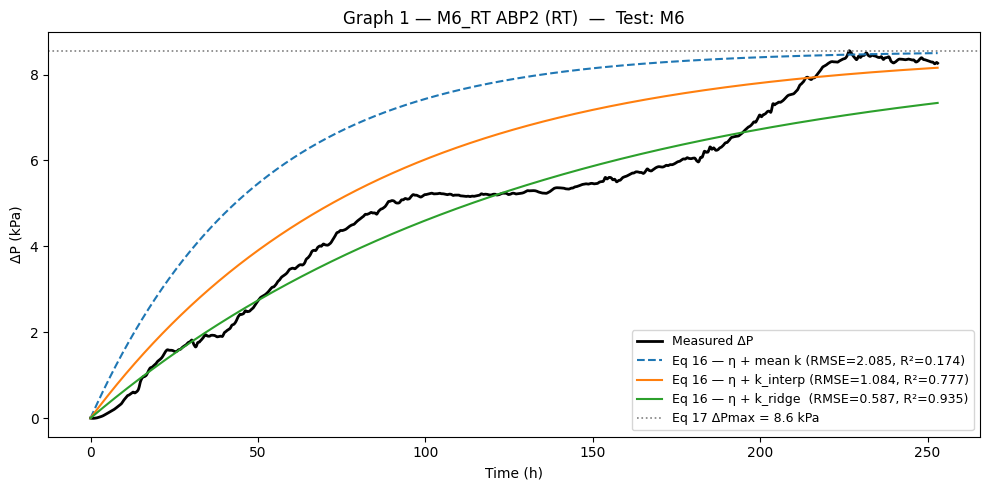

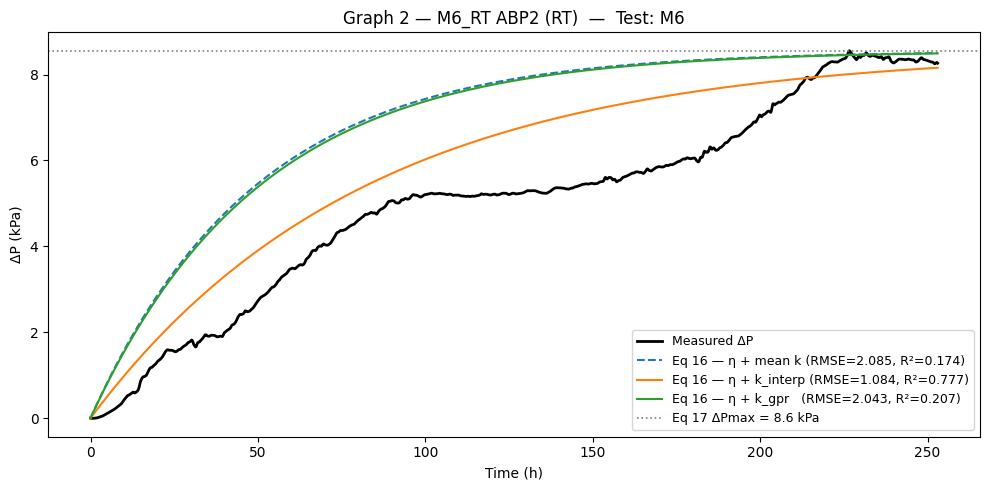

c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



TEST SAMPLE : M6_RT | Sensor = MPR | Temp = RT
RMSE / R² against measured pressure:
  mean_k   : RMSE = 2.4744 kPa, R² = -0.0656
  k_interp : RMSE = 2.4744 kPa, R² = -0.0656
  k_ridge  : RMSE = 2.4744 kPa, R² = -0.0656
  k_gpr    : RMSE = 2.4744 kPa, R² = -0.0656


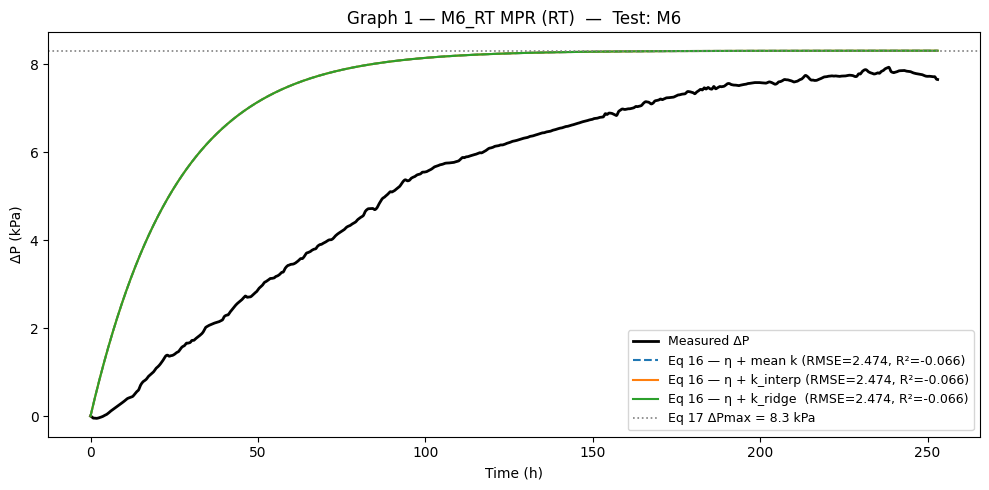

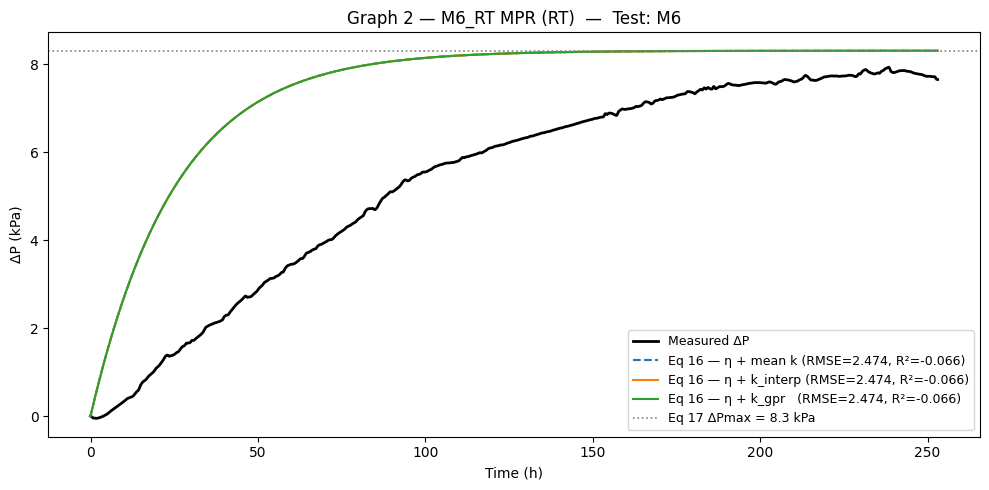

c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



TEST SAMPLE : M6_37C | Sensor = ABP2 | Temp = 37C
RMSE / R² against measured pressure:
  mean_k   : RMSE = 0.4727 kPa, R² = 0.9188
  k_interp : RMSE = 0.3317 kPa, R² = 0.9600
  k_ridge  : RMSE = 0.3136 kPa, R² = 0.9643
  k_gpr    : RMSE = 0.4727 kPa, R² = 0.9188


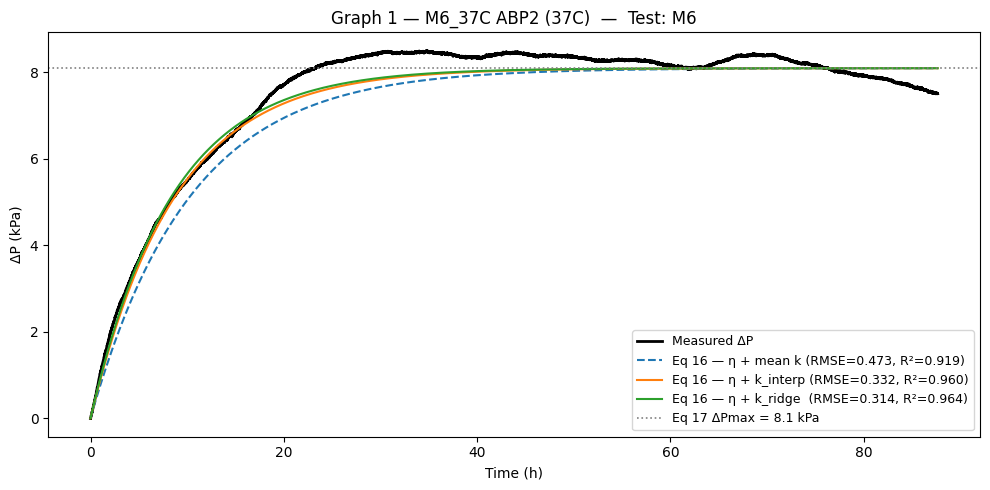

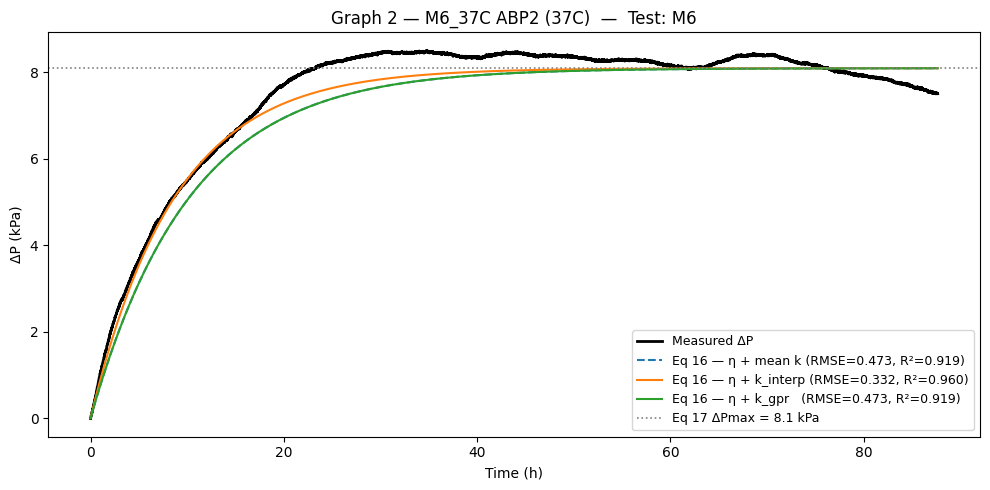

c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



TEST SAMPLE : M6_37C | Sensor = MPR | Temp = 37C
RMSE / R² against measured pressure:
  mean_k   : RMSE = 1.3474 kPa, R² = 0.6812
  k_interp : RMSE = 1.7794 kPa, R² = 0.4441
  k_ridge  : RMSE = 1.3555 kPa, R² = 0.6774
  k_gpr    : RMSE = 1.3474 kPa, R² = 0.6812


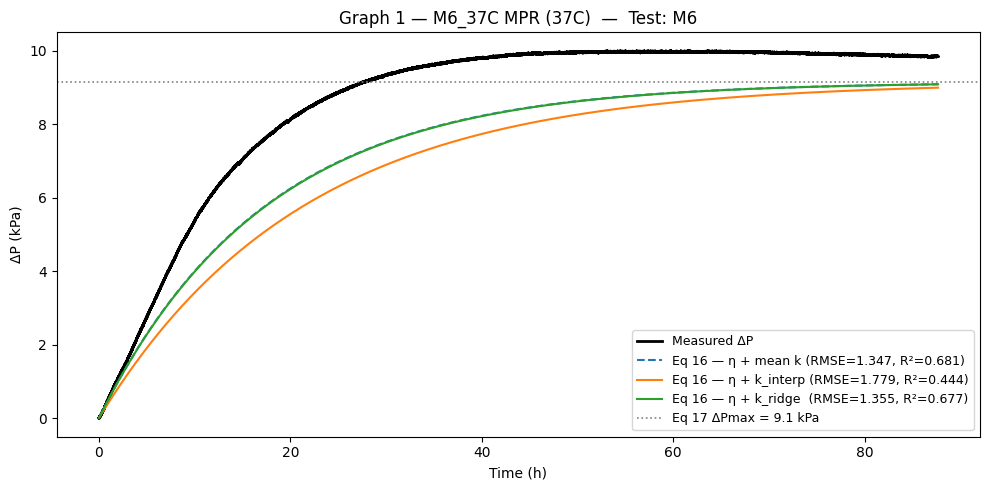

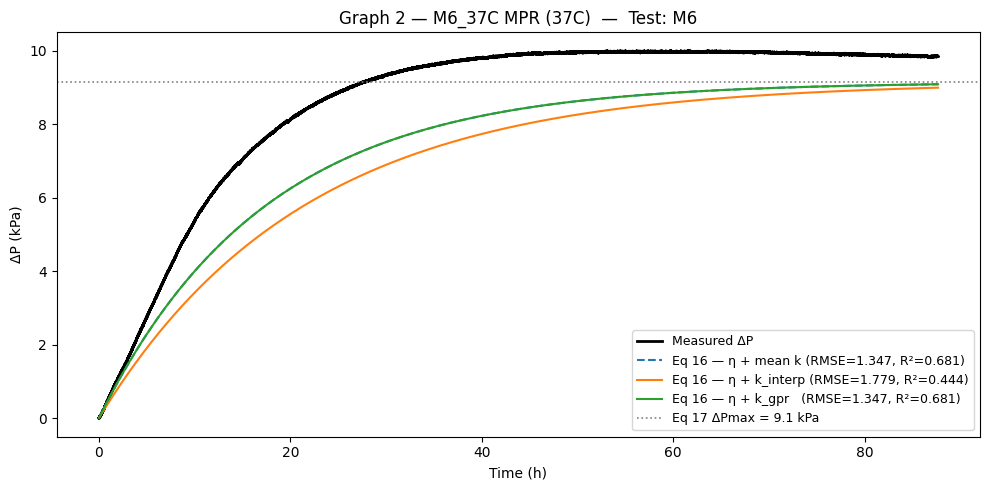

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.metrics import mean_squared_error, r2_score


CSV_FOLDER = r"C:\Users\chand\Documents\GitHub\Thesis\csv_combi"
TIME_COL     = "Time (h)"
TEMP_COL_K   = "calibrated temperature (K)"
TEMP_COL_37C = "calibrated temperature (K)"   # column is labelled K but stores Celsius for 37C files  // this has to be fixed soon, not a problem for now
PRESS_COL_RT_ABP2  = "ABP2 DWT denoised pressure (kPa)"
PRESS_COL_RT_MPR   = "MPR SG pressure (kPa)"
PRESS_COL_37C_ABP2 = "ABP2 SG smoothed pressure (kPa)"
PRESS_COL_37C_MPR  = "MPR SG smoothed pressure (kPa)"
R_J = 8.314         #J/(mol·K)  
TEST_SAMPLE_PREFIX = "M6"



def ml_to_m3(ml):
    return ml * 1e-6


def mM_ml_to_mol(C_mM, V_ml):
    return C_mM * V_ml * 1e-6


def get_pressure_col(temp_label, sensor):
    if temp_label == "RT":
        return PRESS_COL_RT_ABP2 if sensor == "ABP2" else PRESS_COL_RT_MPR
    return PRESS_COL_37C_ABP2 if sensor == "ABP2" else PRESS_COL_37C_MPR

def calc_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return rmse, r2



#Source: Battino et al. 1983, "The Solubility of Oxygen and Ozone in Liquids"
#kH_ref = 1.3e-3 mol/(L·atm) at T_ref = 298.15 K
_battino_T  = np.array([273.15, 278.15, 283.15, 288.15, 293.15,
                         298.15, 303.15, 308.15, 313.15, 318.15,
                         323.15, 328.15, 333.15, 338.15, 343.15, 348.15])

_battino_dH = np.array([-17.60, -16.18, -15.16, -14.15, -13.13,
                         -12.11, -11.10, -10.08,  -9.06,  -8.05,
                          -7.03,  -6.01,  -5.00,  -3.98,  -2.97,  -1.95])
_kH_ref = 1.3e-3      
_T_ref  = 298.15      
_dH_ref = -12.11      


def calc_H_SI(Tk):                     # H(T) is calculated for every time stamp  and then for the max pressure equation (17), it only 
    dH_T   = np.interp(Tk, _battino_T, _battino_dH)
    dH_avg = ((_dH_ref + dH_T) / 2.0) * 1000.0     # kJ/mol to J/mol
    kH_mol_per_L_per_atm = _kH_ref * np.exp(
        -(dH_avg / R_J) * (1.0 / Tk - 1.0 / _T_ref)
    )
    return kH_mol_per_L_per_atm * 1e3 / 101325.0





def calc_eta(P_peak_kPa, T_peak_K, C_mM, Vsol_ml, Vg_ml):
    P_peak_Pa = P_peak_kPa * 1000.0
    Vg_m3     = ml_to_m3(Vg_ml)
    Vsol_m3   = ml_to_m3(Vsol_ml)
    H_T       = calc_H_SI(T_peak_K)              
    n_gas_max = P_peak_Pa * Vg_m3 / (R_J * T_peak_K)   
    n_aq_max  = H_T * P_peak_Pa * Vsol_m3               
    n_gen_max = mM_ml_to_mol(C_mM, Vsol_ml)             
    return (n_gas_max + n_aq_max) / n_gen_max



def P_model(t, Tk, eta_hat, C_mM, Vsol_ml, Vg_ml, k):
    Vg_m3   = ml_to_m3(Vg_ml)
    Vsol_m3 = ml_to_m3(Vsol_ml)
    H_T     = calc_H_SI(Tk)                             
    n_gen_mol   = mM_ml_to_mol(C_mM, Vsol_ml)           
    numerator   = eta_hat * n_gen_mol * (1.0 - np.exp(-k * t))
    denominator = Vg_m3 / (R_J * Tk) + H_T * Vsol_m3   
    return (numerator / denominator) / 1000.0           



def P_max_model_Hmean(H_mean, eta_hat, C_mM, Vsol_ml, Vg_ml, T_mean):
    Vg_m3   = ml_to_m3(Vg_ml)
    Vsol_m3 = ml_to_m3(Vsol_ml)
    n_gen_mol   = mM_ml_to_mol(C_mM, Vsol_ml)
    denominator = Vg_m3 / (R_J * T_mean) + H_mean * Vsol_m3
    return (eta_hat * n_gen_mol / denominator) / 1000.0  



def interp_piecewise_clamped(x_train, y_train, x_query):
    x = np.asarray(x_train, dtype=float)
    y = np.asarray(y_train, dtype=float)
    order = np.argsort(x)
    return float(np.interp(float(x_query), x[order], y[order]))



def fit_k_models(df_train):
    X = df_train[["C_mM"]].values.astype(float)
    y = df_train["k"].values.astype(float)

    ridge = Ridge(alpha=1e-6)
    ridge.fit(X, y)

    kernel = (
        ConstantKernel(1.0, (1e-3, 1e3))            # Chose this based on the bets choice from the options i this website: https://scikit-learn.org/stable/modules/gaussian_process.html
        * RBF(length_scale=0.5, length_scale_bounds=(1e-2, 1e2))
        + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-1))
    )
    gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=0)
    gpr.fit(X, y)

    return ridge, gpr


def predict_k_ridge(ridge, C):
    return float(ridge.predict(np.array([[float(C)]]))[0])


def predict_k_gpr(gpr, C):
    return float(gpr.predict(np.array([[float(C)]]), return_std=False)[0])



experiments = [
    ("M1_RT",  "ABP2", "RT",  1.2,  6.0,  4.0,  "M1_RT_ABP2.csv"),
    ("M2_RT",  "ABP2", "RT",  1.6,  6.0,  4.0,  "M2_RT_ABP2.csv"),
    ("M4_RT",  "ABP2", "RT",  2.5,  6.0,  4.0,  "M4_RT_ABP2.csv"),
   

    ("M1_RT",  "MPR",  "RT",  1.2,  6.0,  4.0,  "M1_RT_MPR.csv"),
   

    ("M1_37C", "ABP2", "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ("M2_37C", "ABP2", "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ("M3_37C", "ABP2", "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
   

    ("M1_37C", "MPR",  "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ("M2_37C", "MPR",  "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ("M3_37C", "MPR",  "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv")
    
]

test_experiments = [
    ("M6_RT",  "ABP2", "RT",  2.67, 5.78, 4.22, "M6_RT_ABP2.csv"),
    ("M6_RT",  "MPR",  "RT",  2.67, 5.78, 4.22, "M6_RT_MPR.csv"),
    ("M6_37C", "ABP2", "37C", 2.67, 5.7,  4.3,  "M6_37C_ABP2_MPR.csv"),
    ("M6_37C", "MPR",  "37C", 2.67, 6.0,  4.0,  "M6_37C_ABP2_MPR.csv"),
]


K_VALUES = {
    ("M1_RT",  "ABP2"): 0.0330,
    ("M2_RT",  "ABP2"): 0.0159,
    ("M4_RT",  "ABP2"): 0.0122,


    ("M1_RT",  "MPR") : 0.03930,
    

    ("M1_37C", "ABP2"): 0.09818,
    ("M2_37C", "ABP2"): 0.07972,
    ("M3_37C", "ABP2"): 0.11477,
    

    ("M1_37C", "MPR") : 0.04689,
    ("M2_37C", "MPR") : 0.07874,
    ("M3_37C", "MPR") : 0.04671
   
}



rows = []

for (sample, sensor, temp_label, C_mM, Vsol_ml, Vg_ml, csv_file) in experiments:
    k = K_VALUES.get((sample, sensor))
    csv_path = os.path.join(CSV_FOLDER, csv_file)
    df = pd.read_csv(csv_path)
    P_col = get_pressure_col(temp_label, sensor)
    t      = df[TIME_COL].values.astype(float);  t -= t[0]
    P_meas = df[P_col].values.astype(float);     P_meas -= P_meas[0]
    Tk = df[TEMP_COL_K].values.astype(float)
    if temp_label == "37C":
        Tk = Tk + 273.15          # column labelled K but stores Celsius
    idx_peak   = int(np.argmax(P_meas))
    P_peak_kPa = float(P_meas[idx_peak])
    T_peak_K   = float(Tk[idx_peak])

    eta_peak = calc_eta(P_peak_kPa, T_peak_K, C_mM, Vsol_ml, Vg_ml)

    rows.append({
        "sample":        sample,
        "sample_prefix": sample.split("_")[0],
        "sensor":        sensor,
        "temp_label":    temp_label,
        "C_mM":          float(C_mM),
        "Vsol_ml":       float(Vsol_ml),
        "Vg_ml":         float(Vg_ml),
        "k":             float(k),
        "eta_peak":      float(eta_peak),   # η from Eq 13
        "csv":           csv_file,
    })

df_sum = pd.DataFrame(rows)



#
#VALIDATION
for (sample, sensor, temp_label, C_test, Vsol_ml, Vg_ml, csv_test) in test_experiments:

    
    df_train = df_sum[
        (df_sum["sample_prefix"] != TEST_SAMPLE_PREFIX) &
        (df_sum["sensor"]        == sensor) &
        (df_sum["temp_label"]    == temp_label)
    ].copy()


    #Interpolate k from training samples and suse the mean of each temp group for η
    eta_hat = float(df_train["eta_peak"].mean())
    k_interp = interp_piecewise_clamped(df_train["C_mM"], df_train["k"],        C_test)
    mean_k   = float(df_train["k"].mean())

    
    ridge, gpr = fit_k_models(df_train)
    k_ridge = max(predict_k_ridge(ridge, C_test), 1e-6)
    k_gpr   = max(predict_k_gpr(gpr,   C_test), 1e-6)
    k_interp = max(k_interp, 1e-6)

    
    df_test = pd.read_csv(os.path.join(CSV_FOLDER, csv_test))
    P_col   = get_pressure_col(temp_label, sensor)
    t      = df_test[TIME_COL].values.astype(float);  t -= t[0]
    P_meas = df_test[P_col].values.astype(float);     P_meas -= P_meas[0]
    T_nominal = 298.15 if temp_label == "RT" else 310.15
    Tk = np.full(len(t), T_nominal)

   #for plotting
    P_mean_k   = P_model(t, Tk, eta_hat, C_test, Vsol_ml, Vg_ml, mean_k)
    P_k_interp = P_model(t, Tk, eta_hat, C_test, Vsol_ml, Vg_ml, k_interp)
    P_k_ridge  = P_model(t, Tk, eta_hat, C_test, Vsol_ml, Vg_ml, k_ridge)
    P_k_gpr    = P_model(t, Tk, eta_hat, C_test, Vsol_ml, Vg_ml, k_gpr)
    T_mean = T_nominal
    H_mean = float(calc_H_SI(T_nominal))
    Pmax_pred = P_max_model_Hmean(H_mean, eta_hat, C_test, Vsol_ml, Vg_ml, T_mean)
    
    
    rmse_mean_k,   r2_mean_k   = calc_metrics(P_meas, P_mean_k)
    rmse_interp,   r2_interp   = calc_metrics(P_meas, P_k_interp)
    rmse_ridge,    r2_ridge    = calc_metrics(P_meas, P_k_ridge)
    rmse_gpr,      r2_gpr      = calc_metrics(P_meas, P_k_gpr)

    print("\n" + "=" * 80)
    print(f"TEST SAMPLE : {sample} | Sensor = {sensor} | Temp = {temp_label}")
    print(f"RMSE / R² against measured pressure:")
    print(f"  mean_k   : RMSE = {rmse_mean_k:.4f} kPa, R² = {r2_mean_k:.4f}")
    print(f"  k_interp : RMSE = {rmse_interp:.4f} kPa, R² = {r2_interp:.4f}")
    print(f"  k_ridge  : RMSE = {rmse_ridge:.4f} kPa, R² = {r2_ridge:.4f}")
    print(f"  k_gpr    : RMSE = {rmse_gpr:.4f} kPa, R² = {r2_gpr:.4f}")
    

    title_base = f"{sample} {sensor} ({temp_label})  —  Test: {TEST_SAMPLE_PREFIX}"
    plt.figure(figsize=(10, 5))
    plt.plot(t, P_meas,     "k-",  lw=2,   label="Measured ΔP")
    plt.plot(t, P_mean_k,   "--",          label=f"Eq 16 — η + mean k (RMSE={rmse_mean_k:.3f}, R²={r2_mean_k:.3f})")
    plt.plot(t, P_k_interp, "-",           label=f"Eq 16 — η + k_interp (RMSE={rmse_interp:.3f}, R²={r2_interp:.3f})")
    plt.plot(t, P_k_ridge,  "-",           label=f"Eq 16 — η + k_ridge  (RMSE={rmse_ridge:.3f}, R²={r2_ridge:.3f})")
    plt.axhline(Pmax_pred, color="grey", ls=":", lw=1.2,
                label=f"Eq 17 ΔPmax = {Pmax_pred:.1f} kPa")
    plt.xlabel("Time (h)")
    plt.ylabel("ΔP (kPa)")
    plt.title("Graph 1 — " + title_base)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(10, 5))
    plt.plot(t, P_meas,     "k-",  lw=2,   label="Measured ΔP")
    plt.plot(t, P_mean_k,   "--",          label=f"Eq 16 — η + mean k (RMSE={rmse_mean_k:.3f}, R²={r2_mean_k:.3f})")
    plt.plot(t, P_k_interp, "-",           label=f"Eq 16 — η + k_interp (RMSE={rmse_interp:.3f}, R²={r2_interp:.3f})")
    plt.plot(t, P_k_gpr,    "-",           label=f"Eq 16 — η + k_gpr   (RMSE={rmse_gpr:.3f}, R²={r2_gpr:.3f})")
    plt.axhline(Pmax_pred, color="grey", ls=":", lw=1.2,
                label=f"Eq 17 ΔPmax = {Pmax_pred:.1f} kPa")
    plt.xlabel("Time (h)")
    plt.ylabel("ΔP (kPa)")
    plt.title("Graph 2 — " + title_base)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


# In code

clarify what is 1. x_train and y_train  in def_interp_piecewise_linear_extrap(x_train, y_train, x_query) and 2. what is x_query?

2. also ive fit ridge between c and k, didnt he say we debunked this? clarify this.

3. should the bgraoph be plotted for ngas instead

4. why does some eta_aya_peak have 1 in it?


# With updated 45C AND 50C measurements

Skipping M3_45C ABP2 — k not yet available
Skipping M6_45C ABP2 — k not yet available
Skipping M3_50C ABP2 — k not yet available
Skipping M6_50C ABP2 — k not yet available
TEST SAMPLE : M6_RT | Sensor = ABP2 | Temp = RT
RMSE / R² against measured pressure:
  mean_k   : RMSE = 2.0855 kPa, R² = 0.1742
  k_interp : RMSE = 1.0843 kPa, R² = 0.7767
  k_ridge  : RMSE = 0.5866 kPa, R² = 0.9347
  k_gpr    : RMSE = 2.0432 kPa, R² = 0.2073


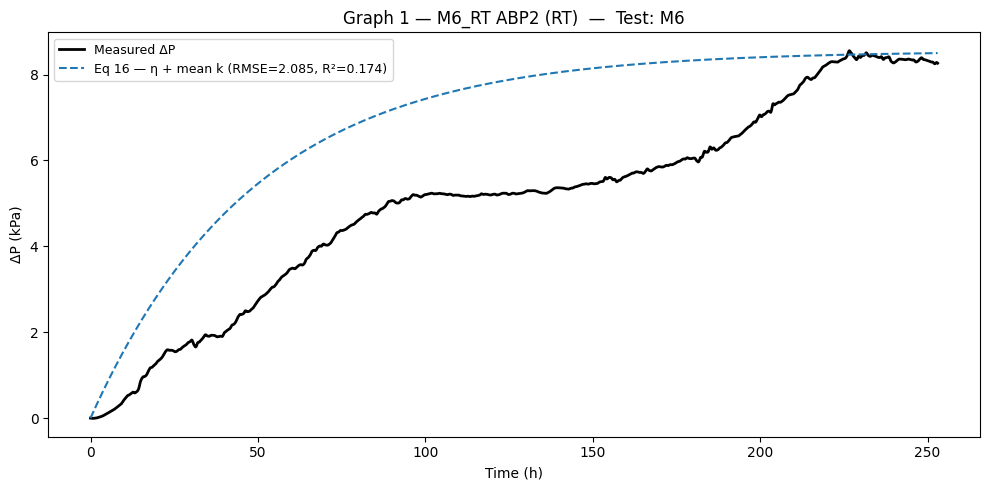

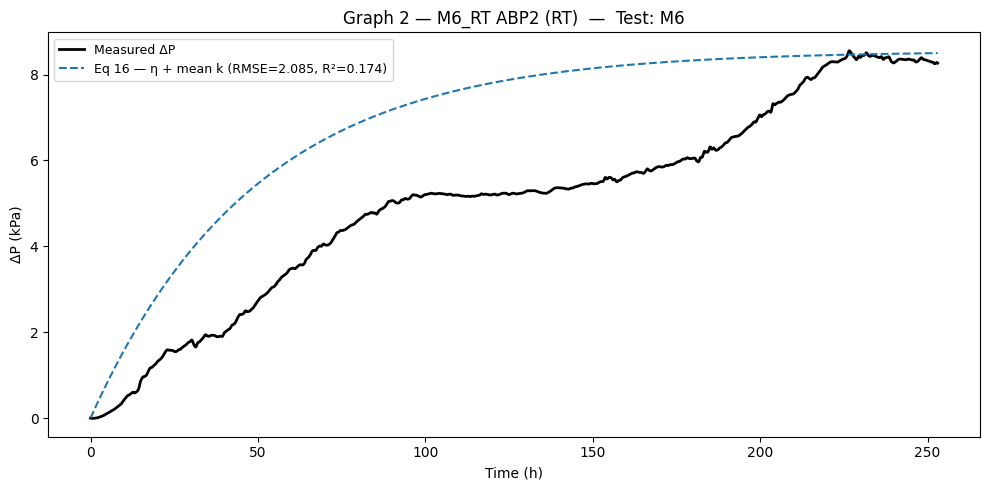

c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


TEST SAMPLE : M6_RT | Sensor = MPR | Temp = RT
RMSE / R² against measured pressure:
  mean_k   : RMSE = 2.4744 kPa, R² = -0.0656
  k_interp : RMSE = 2.4744 kPa, R² = -0.0656
  k_ridge  : RMSE = 2.4744 kPa, R² = -0.0656
  k_gpr    : RMSE = 2.4744 kPa, R² = -0.0656


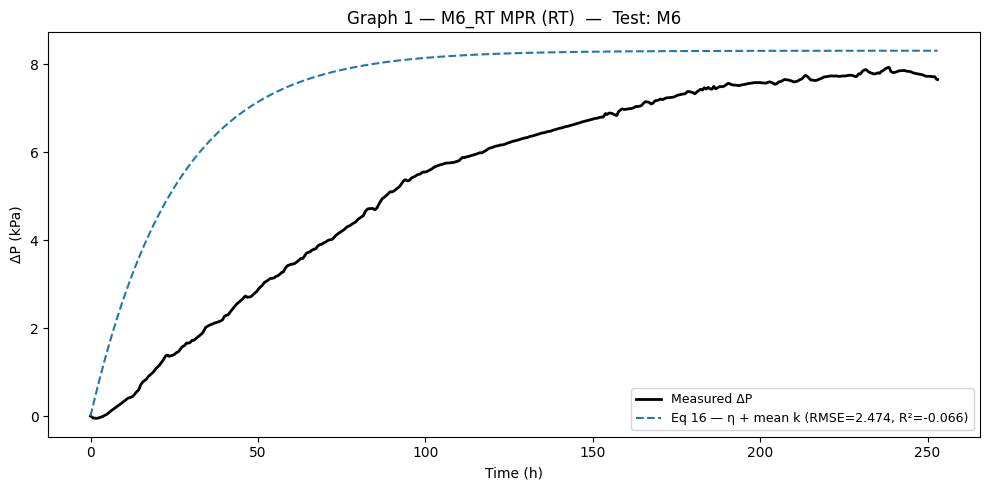

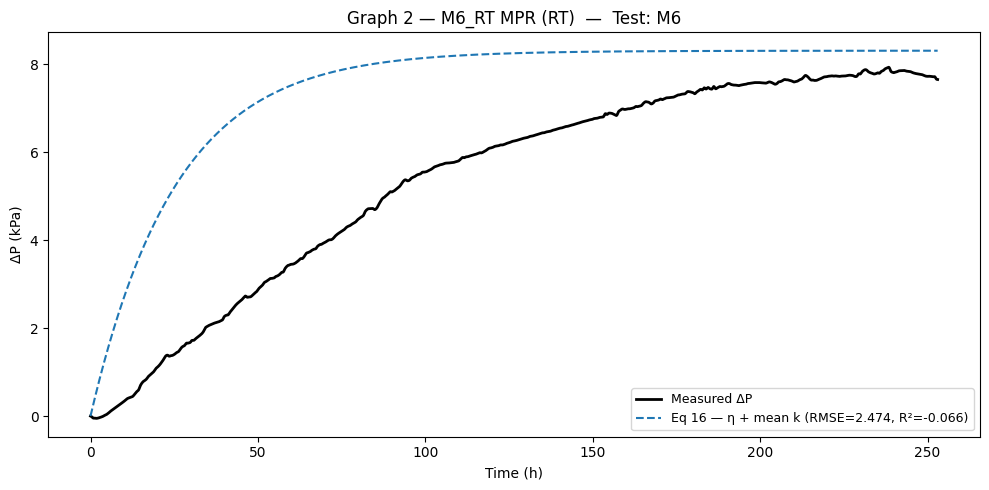

c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


TEST SAMPLE : M6_37C | Sensor = ABP2 | Temp = 37C
RMSE / R² against measured pressure:
  mean_k   : RMSE = 0.4727 kPa, R² = 0.9188
  k_interp : RMSE = 0.3317 kPa, R² = 0.9600
  k_ridge  : RMSE = 0.3136 kPa, R² = 0.9643
  k_gpr    : RMSE = 0.4727 kPa, R² = 0.9188


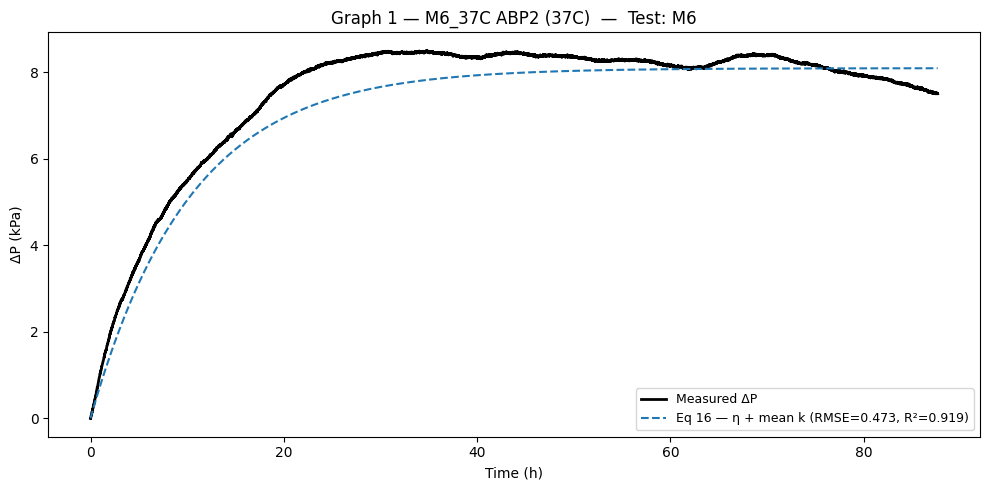

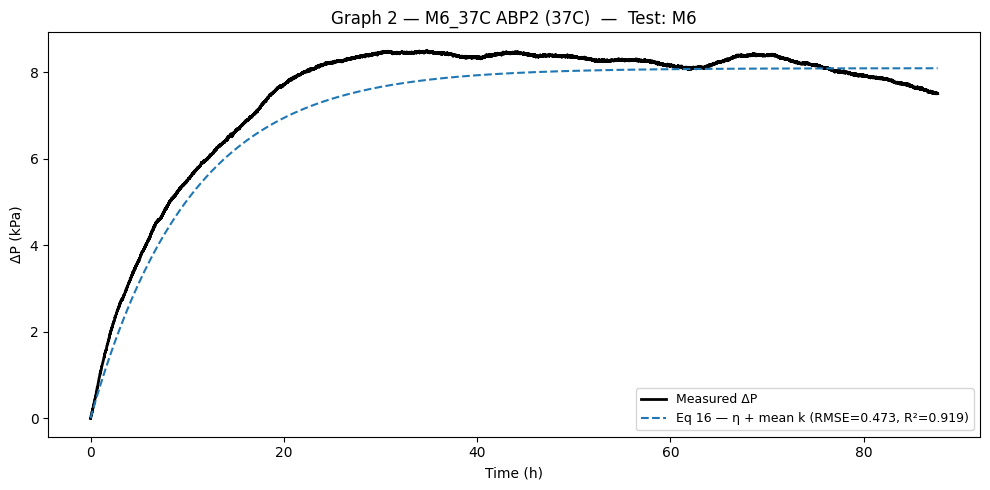

c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


TEST SAMPLE : M6_37C | Sensor = MPR | Temp = 37C
RMSE / R² against measured pressure:
  mean_k   : RMSE = 1.3474 kPa, R² = 0.6812
  k_interp : RMSE = 1.7794 kPa, R² = 0.4441
  k_ridge  : RMSE = 1.3555 kPa, R² = 0.6774
  k_gpr    : RMSE = 1.3474 kPa, R² = 0.6812


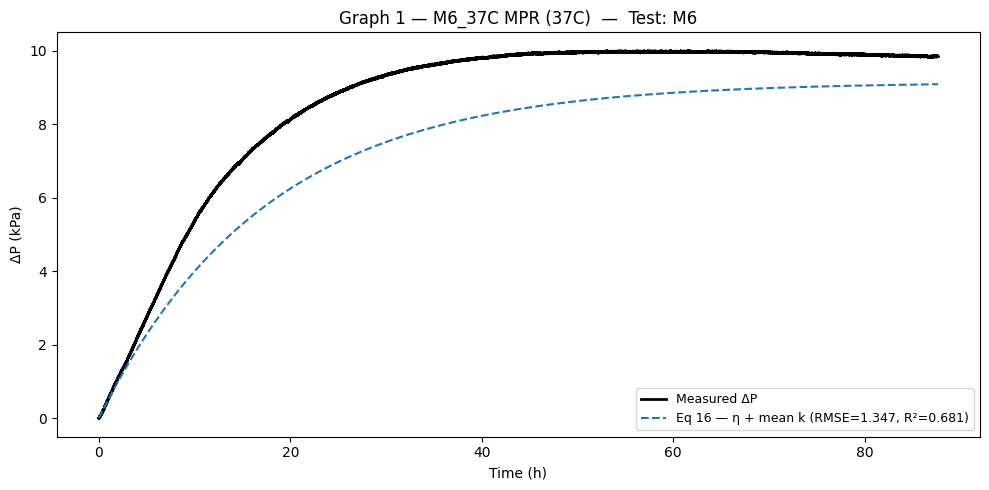

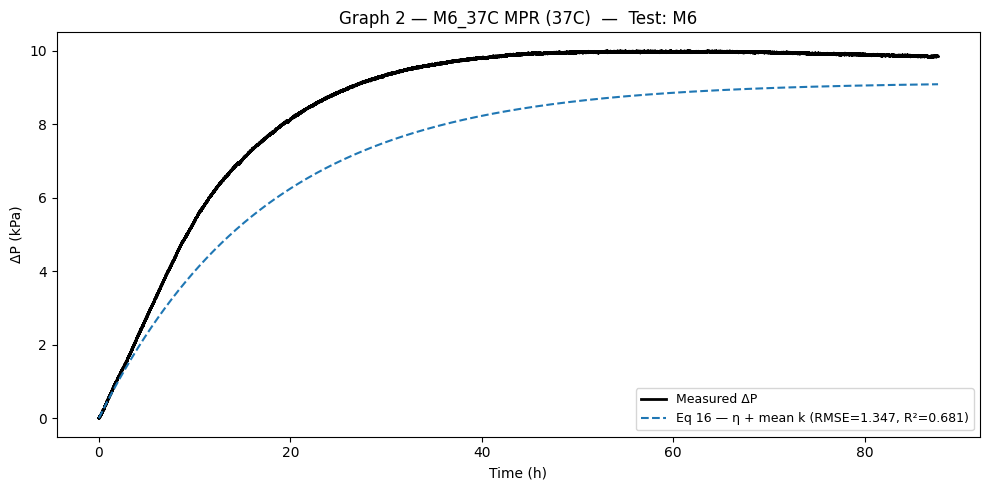

Skipping validation for M6_45C ABP2 (45C) — no training data available yet


c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


TEST SAMPLE : M6_45C | Sensor = MPR | Temp = 45C
RMSE / R² against measured pressure:
  mean_k   : RMSE = 0.3608 kPa, R² = 0.9688
  k_interp : RMSE = 0.3608 kPa, R² = 0.9688
  k_ridge  : RMSE = 0.3608 kPa, R² = 0.9688
  k_gpr    : RMSE = 0.3608 kPa, R² = 0.9688


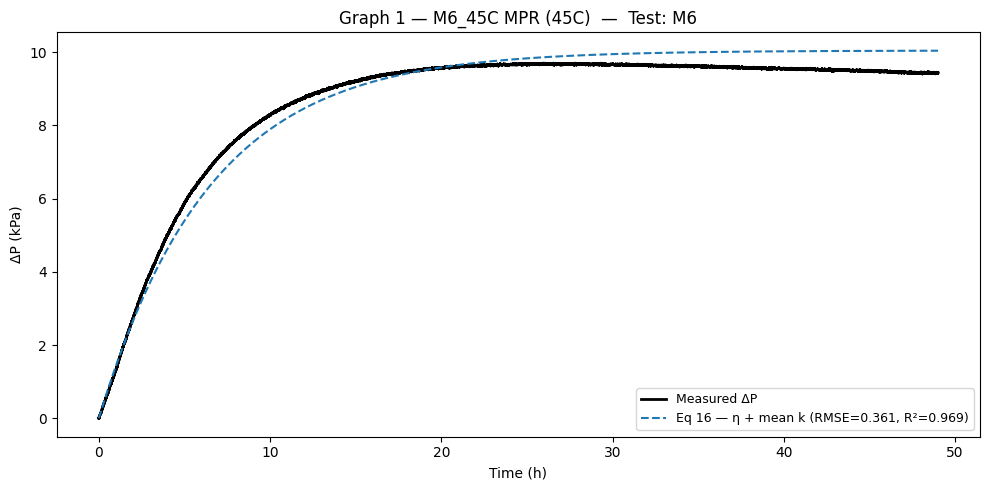

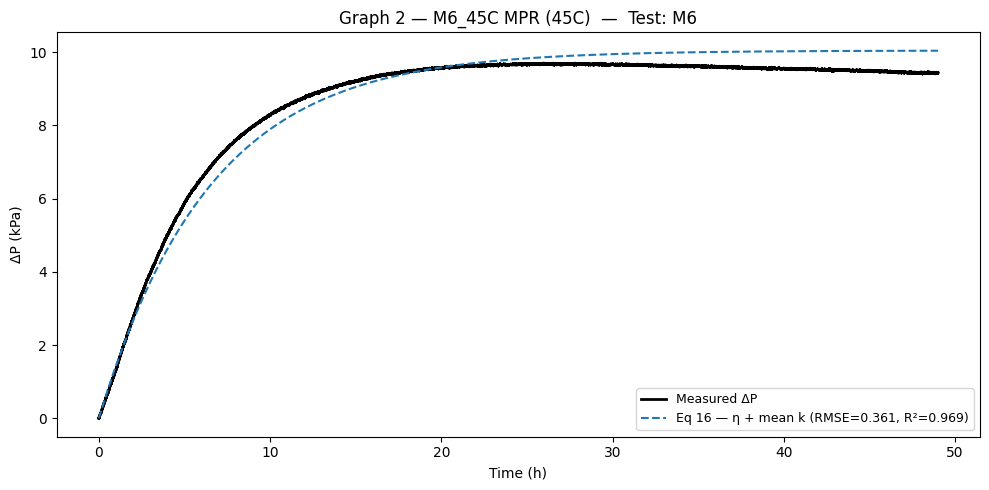

Skipping validation for M6_50C ABP2 (50C) — no training data available yet


c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


TEST SAMPLE : M6_50C | Sensor = MPR | Temp = 50C
RMSE / R² against measured pressure:
  mean_k   : RMSE = 0.6423 kPa, R² = 0.8547
  k_interp : RMSE = 0.6423 kPa, R² = 0.8547
  k_ridge  : RMSE = 0.6423 kPa, R² = 0.8547
  k_gpr    : RMSE = 0.6423 kPa, R² = 0.8547


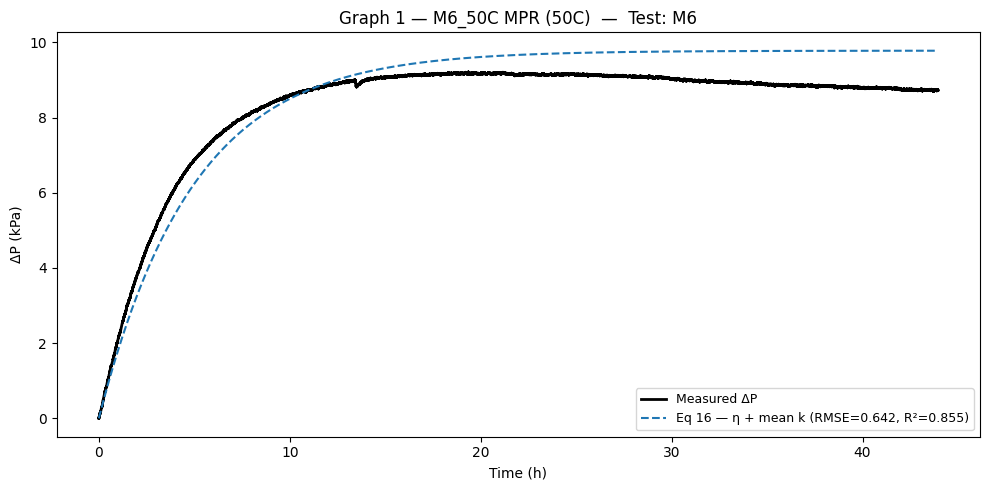

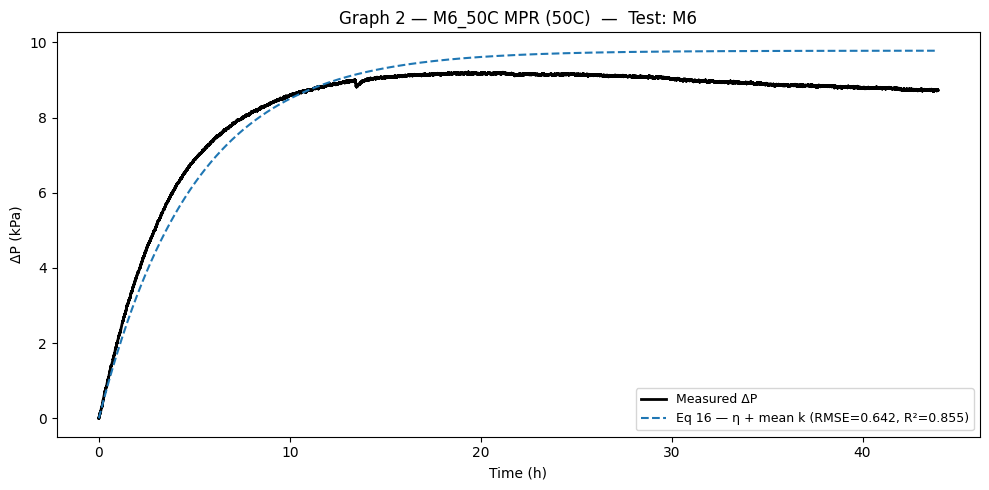

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.metrics import mean_squared_error, r2_score


CSV_FOLDER = r"C:\Users\chand\Documents\GitHub\Thesis\csv_combi"
TIME_COL     = "Time (h)"
TEMP_COL_K   = "calibrated temperature (K)"
TEMP_COL_37C = "calibrated temperature (K)"   # column is labelled K but stores Celsius for 37C files  // this has to be fixed soon, not a problem for now
PRESS_COL_RT_ABP2  = "ABP2 DWT denoised pressure (kPa)"
PRESS_COL_RT_MPR   = "MPR SG pressure (kPa)"
# All elevated-temperature runs (37C, 45C, 50C) share SG-smoothed columns
PRESS_COL_ELEV_ABP2 = "ABP2 SG smoothed pressure (kPa)"
PRESS_COL_ELEV_MPR  = "MPR SG smoothed pressure (kPa)"

# Nominal temperature (K) for each label — used where per-row T is unavailable
TEMP_NOMINAL_K = {"RT": 298.15, "37C": 310.15, "45C": 318.15, "50C": 323.15}
R_J = 8.314         #J/(mol·K)  
TEST_SAMPLE_PREFIX = "M6"



def ml_to_m3(ml):
    return ml * 1e-6


def mM_ml_to_mol(C_mM, V_ml):
    return C_mM * V_ml * 1e-6


def get_pressure_col(temp_label, sensor):
    if temp_label == "RT":
        return PRESS_COL_RT_ABP2 if sensor == "ABP2" else PRESS_COL_RT_MPR
    # 37C, 45C, 50C all use SG-smoothed columns (combined ABP2_MPR files)
    return PRESS_COL_ELEV_ABP2 if sensor == "ABP2" else PRESS_COL_ELEV_MPR

def calc_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return rmse, r2



#Source: Battino et al. 1983, "The Solubility of Oxygen and Ozone in Liquids"
#kH_ref = 1.3e-3 mol/(L·atm) at T_ref = 298.15 K
_battino_T  = np.array([273.15, 278.15, 283.15, 288.15, 293.15,
                         298.15, 303.15, 308.15, 313.15, 318.15,
                         323.15, 328.15, 333.15, 338.15, 343.15, 348.15])

_battino_dH = np.array([-17.60, -16.18, -15.16, -14.15, -13.13,
                         -12.11, -11.10, -10.08,  -9.06,  -8.05,
                          -7.03,  -6.01,  -5.00,  -3.98,  -2.97,  -1.95])
_kH_ref = 1.3e-3      
_T_ref  = 298.15      
_dH_ref = -12.11      


def calc_H_SI(Tk):                     # H(T) is calculated for every time stamp  and then for the max pressure equation (17), it only 
    dH_T   = np.interp(Tk, _battino_T, _battino_dH)
    dH_avg = ((_dH_ref + dH_T) / 2.0) * 1000.0     # kJ/mol to J/mol
    kH_mol_per_L_per_atm = _kH_ref * np.exp(
        -(dH_avg / R_J) * (1.0 / Tk - 1.0 / _T_ref)
    )
    return kH_mol_per_L_per_atm * 1e3 / 101325.0





def calc_eta(P_peak_kPa, T_peak_K, C_mM, Vsol_ml, Vg_ml):
    P_peak_Pa = P_peak_kPa * 1000.0
    Vg_m3     = ml_to_m3(Vg_ml)
    Vsol_m3   = ml_to_m3(Vsol_ml)
    H_T       = calc_H_SI(T_peak_K)              
    n_gas_max = P_peak_Pa * Vg_m3 / (R_J * T_peak_K)   
    n_aq_max  = H_T * P_peak_Pa * Vsol_m3               
    n_gen_max = mM_ml_to_mol(C_mM, Vsol_ml)             
    return (n_gas_max + n_aq_max) / n_gen_max



def P_model(t, Tk, eta_hat, C_mM, Vsol_ml, Vg_ml, k):
    Vg_m3   = ml_to_m3(Vg_ml)
    Vsol_m3 = ml_to_m3(Vsol_ml)
    H_T     = calc_H_SI(Tk)                             
    n_gen_mol   = mM_ml_to_mol(C_mM, Vsol_ml)           
    numerator   = eta_hat * n_gen_mol * (1.0 - np.exp(-k * t))
    denominator = Vg_m3 / (R_J * Tk) + H_T * Vsol_m3   
    return (numerator / denominator) / 1000.0           



def P_max_model_Hmean(H_mean, eta_hat, C_mM, Vsol_ml, Vg_ml, T_mean):
    Vg_m3   = ml_to_m3(Vg_ml)
    Vsol_m3 = ml_to_m3(Vsol_ml)
    n_gen_mol   = mM_ml_to_mol(C_mM, Vsol_ml)
    denominator = Vg_m3 / (R_J * T_mean) + H_mean * Vsol_m3
    return (eta_hat * n_gen_mol / denominator) / 1000.0  



def interp_piecewise_clamped(x_train, y_train, x_query):
    x = np.asarray(x_train, dtype=float)
    y = np.asarray(y_train, dtype=float)
    order = np.argsort(x)
    return float(np.interp(float(x_query), x[order], y[order]))



def fit_k_models(df_train):
    X = df_train[["C_mM"]].values.astype(float)
    y = df_train["k"].values.astype(float)

    ridge = Ridge(alpha=1e-6)
    ridge.fit(X, y)

    kernel = (
        ConstantKernel(1.0, (1e-3, 1e3))            # Chose this based on the bets choice from the options i this website: https://scikit-learn.org/stable/modules/gaussian_process.html
        * RBF(length_scale=0.5, length_scale_bounds=(1e-2, 1e2))
        + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-1))
    )
    gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=0)
    gpr.fit(X, y)

    return ridge, gpr


def predict_k_ridge(ridge, C):
    return float(ridge.predict(np.array([[float(C)]]))[0])


def predict_k_gpr(gpr, C):
    return float(gpr.predict(np.array([[float(C)]]), return_std=False)[0])



experiments = [
    ("M1_RT",  "ABP2", "RT",  1.2,  6.0,  4.0,  "M1_RT_ABP2.csv"),
    ("M2_RT",  "ABP2", "RT",  1.6,  6.0,  4.0,  "M2_RT_ABP2.csv"),
    ("M4_RT",  "ABP2", "RT",  2.5,  6.0,  4.0,  "M4_RT_ABP2.csv"),
   

    ("M1_RT",  "MPR",  "RT",  1.2,  6.0,  4.0,  "M1_RT_MPR.csv"),
   

    ("M1_37C", "ABP2", "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ("M2_37C", "ABP2", "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ("M3_37C", "ABP2", "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
   

    ("M1_37C", "MPR",  "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ("M2_37C", "MPR",  "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ("M3_37C", "MPR",  "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),

    # --- 45C ---
    ("M3_45C", "ABP2", "45C", 2.0,  6.0,  4.0,  "M3_45C_ABP2_MPR.csv"),
    ("M3_45C", "MPR",  "45C", 2.0,  6.0,  4.0,  "M3_45C_ABP2_MPR.csv"),
    ("M6_45C", "ABP2", "45C", 2.67, 6.0,  4.0,  "M6_45C_ABP2_MPR.csv"),
    ("M6_45C", "MPR",  "45C", 2.67, 6.0,  4.0,  "M6_45C_ABP2_MPR.csv"),

    # --- 50C ---
    ("M3_50C", "ABP2", "50C", 2.0,  6.0,  4.0,  "M3_50C_ABP2_MPR.csv"),
    ("M3_50C", "MPR",  "50C", 2.0,  6.0,  4.0,  "M3_50C_ABP2_MPR.csv"),
    ("M6_50C", "ABP2", "50C", 2.67, 6.0,  4.0,  "M6_50C_ABP2_MPR.csv"),
    ("M6_50C", "MPR",  "50C", 2.67, 6.0,  4.0,  "M6_50C_ABP2_MPR.csv"),
]

test_experiments = [
    ("M6_RT",  "ABP2", "RT",  2.67, 5.78, 4.22, "M6_RT_ABP2.csv"),
    ("M6_RT",  "MPR",  "RT",  2.67, 5.78, 4.22, "M6_RT_MPR.csv"),
    ("M6_37C", "ABP2", "37C", 2.67, 5.7,  4.3,  "M6_37C_ABP2_MPR.csv"),
    ("M6_37C", "MPR",  "37C", 2.67, 6.0,  4.0,  "M6_37C_ABP2_MPR.csv"),
    ("M6_45C", "ABP2", "45C", 2.67, 6.0,  4.0,  "M6_45C_ABP2_MPR.csv"),
    ("M6_45C", "MPR",  "45C", 2.67, 6.0,  4.0,  "M6_45C_ABP2_MPR.csv"),
    ("M6_50C", "ABP2", "50C", 2.67, 6.0,  4.0,  "M6_50C_ABP2_MPR.csv"),
    ("M6_50C", "MPR",  "50C", 2.67, 6.0,  4.0,  "M6_50C_ABP2_MPR.csv"),
]


K_VALUES = {
    ("M1_RT",  "ABP2"): 0.0330,
    ("M2_RT",  "ABP2"): 0.0159,
    ("M4_RT",  "ABP2"): 0.0122,


    ("M1_RT",  "MPR") : 0.03930,
    

    ("M1_37C", "ABP2"): 0.09818,
    ("M2_37C", "ABP2"): 0.07972,
    ("M3_37C", "ABP2"): 0.11477,
    

    ("M1_37C", "MPR") : 0.04689,
    ("M2_37C", "MPR") : 0.07874,
    ("M3_37C", "MPR") : 0.04671,

    # --- 45C (fill in once experiments are processed) ---
    ("M3_45C", "ABP2"): None,
    ("M3_45C", "MPR") : 0.154140,
    ("M6_45C", "ABP2"): None,
    ("M6_45C", "MPR") : 0.156097
,

    # --- 50C (fill in once experiments are processed) ---
    ("M3_50C", "ABP2"): None,
    ("M3_50C", "MPR") : 0.203281,
    ("M6_50C", "ABP2"): None,
    ("M6_50C", "MPR") : 0.219068,
}



rows = []

for (sample, sensor, temp_label, C_mM, Vsol_ml, Vg_ml, csv_file) in experiments:
    k = K_VALUES.get((sample, sensor))
    if k is None:
        print(f"Skipping {sample} {sensor} — k not yet available")
        continue
    csv_path = os.path.join(CSV_FOLDER, csv_file)
    df = pd.read_csv(csv_path)
    P_col = get_pressure_col(temp_label, sensor)
    t      = df[TIME_COL].values.astype(float);  t -= t[0]
    P_meas = df[P_col].values.astype(float);     P_meas -= P_meas[0]
    Tk = df[TEMP_COL_K].values.astype(float)
    if temp_label != "RT":         # elevated-temp CSVs store °C despite column name saying K
        Tk = Tk + 273.15
    idx_peak   = int(np.argmax(P_meas))
    P_peak_kPa = float(P_meas[idx_peak])
    T_peak_K   = float(Tk[idx_peak])

    eta_peak = calc_eta(P_peak_kPa, T_peak_K, C_mM, Vsol_ml, Vg_ml)

    rows.append({
        "sample":        sample,
        "sample_prefix": sample.split("_")[0],
        "sensor":        sensor,
        "temp_label":    temp_label,
        "C_mM":          float(C_mM),
        "Vsol_ml":       float(Vsol_ml),
        "Vg_ml":         float(Vg_ml),
        "k":             float(k),
        "eta_peak":      float(eta_peak),   # η from Eq 13
        "csv":           csv_file,
    })

df_sum = pd.DataFrame(rows)



#
#VALIDATION
for (sample, sensor, temp_label, C_test, Vsol_ml, Vg_ml, csv_test) in test_experiments:

    
    df_train = df_sum[
        (df_sum["sample_prefix"] != TEST_SAMPLE_PREFIX) &
        (df_sum["sensor"]        == sensor) &
        (df_sum["temp_label"]    == temp_label)
    ].copy()

    if len(df_train) == 0:
        print(f"Skipping validation for {sample} {sensor} ({temp_label}) — no training data available yet")
        continue

    #Interpolate k from training samples and use the mean of each temp group for η
    eta_hat = float(df_train["eta_peak"].mean())
    k_interp = interp_piecewise_clamped(df_train["C_mM"], df_train["k"],        C_test)
    mean_k   = float(df_train["k"].mean())

    
    ridge, gpr = fit_k_models(df_train)
    k_ridge = max(predict_k_ridge(ridge, C_test), 1e-6)
    k_gpr   = max(predict_k_gpr(gpr,   C_test), 1e-6)
    k_interp = max(k_interp, 1e-6)

    
    df_test = pd.read_csv(os.path.join(CSV_FOLDER, csv_test))
    P_col   = get_pressure_col(temp_label, sensor)
    t      = df_test[TIME_COL].values.astype(float);  t -= t[0]
    P_meas = df_test[P_col].values.astype(float);     P_meas -= P_meas[0]
    T_nominal = TEMP_NOMINAL_K[temp_label]
    Tk = np.full(len(t), T_nominal)

   #for plotting
    P_mean_k   = P_model(t, Tk, eta_hat, C_test, Vsol_ml, Vg_ml, mean_k)
    P_k_interp = P_model(t, Tk, eta_hat, C_test, Vsol_ml, Vg_ml, k_interp)
    P_k_ridge  = P_model(t, Tk, eta_hat, C_test, Vsol_ml, Vg_ml, k_ridge)
    P_k_gpr    = P_model(t, Tk, eta_hat, C_test, Vsol_ml, Vg_ml, k_gpr)
    T_mean = T_nominal
    H_mean = float(calc_H_SI(T_nominal))
    Pmax_pred = P_max_model_Hmean(H_mean, eta_hat, C_test, Vsol_ml, Vg_ml, T_mean)
    
    
    rmse_mean_k,   r2_mean_k   = calc_metrics(P_meas, P_mean_k)
    rmse_interp,   r2_interp   = calc_metrics(P_meas, P_k_interp)
    rmse_ridge,    r2_ridge    = calc_metrics(P_meas, P_k_ridge)
    rmse_gpr,      r2_gpr      = calc_metrics(P_meas, P_k_gpr)

    
    print(f"TEST SAMPLE : {sample} | Sensor = {sensor} | Temp = {temp_label}")
    print(f"RMSE / R² against measured pressure:")
    print(f"  mean_k   : RMSE = {rmse_mean_k:.4f} kPa, R² = {r2_mean_k:.4f}")
    print(f"  k_interp : RMSE = {rmse_interp:.4f} kPa, R² = {r2_interp:.4f}")
    print(f"  k_ridge  : RMSE = {rmse_ridge:.4f} kPa, R² = {r2_ridge:.4f}")
    print(f"  k_gpr    : RMSE = {rmse_gpr:.4f} kPa, R² = {r2_gpr:.4f}")
    

    title_base = f"{sample} {sensor} ({temp_label})  —  Test: {TEST_SAMPLE_PREFIX}"
    plt.figure(figsize=(10, 5))
    plt.plot(t, P_meas,     "k-",  lw=2,   label="Measured ΔP")
    plt.plot(t, P_mean_k,   "--",          label=f"Eq 16 — η + mean k (RMSE={rmse_mean_k:.3f}, R²={r2_mean_k:.3f})")
    # plt.plot(t, P_k_interp, "-",           label=f"Eq 16 — η + k_interp (RMSE={rmse_interp:.3f}, R²={r2_interp:.3f})")
    # plt.plot(t, P_k_ridge,  "-",           label=f"Eq 16 — η + k_ridge  (RMSE={rmse_ridge:.3f}, R²={r2_ridge:.3f})")
    # plt.axhline(Pmax_pred, color="grey", ls=":", lw=1.2,
    #             label=f"Eq 17 ΔPmax = {Pmax_pred:.1f} kPa")
    plt.xlabel("Time (h)")
    plt.ylabel("ΔP (kPa)")
    plt.title("Graph 1 — " + title_base)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(10, 5))
    plt.plot(t, P_meas,     "k-",  lw=2,   label="Measured ΔP")
    plt.plot(t, P_mean_k,   "--",          label=f"Eq 16 — η + mean k (RMSE={rmse_mean_k:.3f}, R²={r2_mean_k:.3f})")
    # plt.plot(t, P_k_interp, "-",           label=f"Eq 16 — η + k_interp (RMSE={rmse_interp:.3f}, R²={r2_interp:.3f})")
    # plt.plot(t, P_k_gpr,    "-",           label=f"Eq 16 — η + k_gpr   (RMSE={rmse_gpr:.3f}, R²={r2_gpr:.3f})")
    # plt.axhline(Pmax_pred, color="grey", ls=":", lw=1.2,
    #             label=f"Eq 17 ΔPmax = {Pmax_pred:.1f} kPa")
    plt.xlabel("Time (h)")
    plt.ylabel("ΔP (kPa)")
    plt.title("Graph 2 — " + title_base)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()




Saved: k_vs_concentration.png


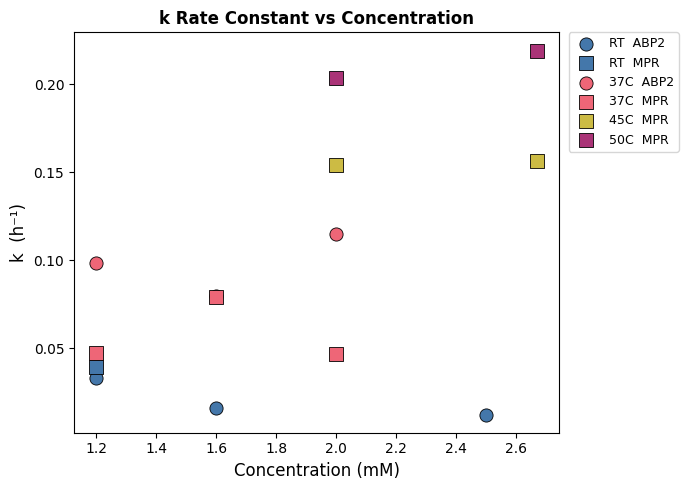

In [11]:
"""
k vs Temperature Analysis
Two separate figures:
  1. k vs concentration coloured by temperature
  2. Arrhenius plot (ln k_mean vs 1/T)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ── Raw data ─────────────────────────────────────────────────────────────────
RAW = [
    # RT
    ("M1_RT",  "ABP2", "RT",  1.2,  0.0330),
    ("M2_RT",  "ABP2", "RT",  1.6,  0.0159),
    ("M4_RT",  "ABP2", "RT",  2.5,  0.0122),
    ("M1_RT",  "MPR",  "RT",  1.2,  0.03930),
    # 37C
    ("M1_37C", "ABP2", "37C", 1.2,  0.09818),
    ("M2_37C", "ABP2", "37C", 1.6,  0.07972),
    ("M3_37C", "ABP2", "37C", 2.0,  0.11477),
    ("M1_37C", "MPR",  "37C", 1.2,  0.04689),
    ("M2_37C", "MPR",  "37C", 1.6,  0.07874),
    ("M3_37C", "MPR",  "37C", 2.0,  0.04671),
    # 45C  (MPR only so far)
    ("M3_45C", "MPR",  "45C", 2.0,  0.154140),
    ("M6_45C", "MPR",  "45C", 2.67, 0.156097),
    # 50C  (MPR only so far)
    ("M3_50C", "MPR",  "50C", 2.0,  0.203281),
    ("M6_50C", "MPR",  "50C", 2.67, 0.219068),
]

TEMP_C     = {"RT": 25.0, "37C": 37.0, "45C": 45.0, "50C": 50.0}
TEMP_K     = {lbl: C + 273.15 for lbl, C in TEMP_C.items()}
TEMP_ORDER = ["RT", "37C", "45C", "50C"]
COLORS     = {"RT": "#4477AA", "37C": "#EE6677", "45C": "#CCBB44", "50C": "#AA3377"}
MARKERS    = {"ABP2": "o", "MPR": "s"}

df = pd.DataFrame(RAW, columns=["sample", "sensor", "temp_label", "conc_mM", "k"])
df["temp_C"] = df["temp_label"].map(TEMP_C)
df["temp_K"] = df["temp_label"].map(TEMP_K)

# ── Per-group statistics ──────────────────────────────────────────────────────
stats = (df.groupby("temp_label")["k"]
           .agg(n="count", mean="mean", std="std")
           .reindex(TEMP_ORDER)
           .dropna())
stats["cv_pct"] = (stats["std"] / stats["mean"] * 100).fillna(0)
stats["temp_C"] = stats.index.map(TEMP_C)
stats["temp_K"] = stats.index.map(TEMP_K)

# ── Figure 1: k vs Concentration ─────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(7, 5))

for tlbl in TEMP_ORDER:
    grp = df[df["temp_label"] == tlbl]
    if grp.empty:
        continue
    for sensor, sg in grp.groupby("sensor"):
        ax1.scatter(sg["conc_mM"], sg["k"],
                    color=COLORS[tlbl], marker=MARKERS[sensor],
                    s=90, edgecolors="black", linewidths=0.6, zorder=3,
                    label=f"{tlbl}  {sensor}")

ax1.set_xlabel("Concentration (mM)", fontsize=12)
ax1.set_ylabel("k  (h⁻¹)", fontsize=12)
ax1.set_title("k Rate Constant vs Concentration", fontsize=12, fontweight="bold")
ax1.legend(fontsize=9, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

fig1.tight_layout()
fig1.savefig("k_vs_concentration.png", dpi=300, bbox_inches="tight")
print("Saved: k_vs_concentration.png")
plt.show()

# # ── Figure 2: Arrhenius plot ──────────────────────────────────────────────────
# fig2, ax2 = plt.subplots(figsize=(7, 5))

# inv_T = 1.0 / stats["temp_K"].values
# ln_k  = np.log(stats["mean"].values)

# slope, intercept, r, *_ = linregress(inv_T, ln_k)
# R_J  = 8.314
# Ea   = -slope * R_J / 1000   # kJ/mol
# ln_A = intercept

# fit_x = np.linspace(inv_T.min() * 0.998, inv_T.max() * 1.002, 200)
# fit_y = slope * fit_x + intercept

# ax2.plot(fit_x, fit_y, color="black", lw=1.5, alpha=0.5)

# for tlbl in stats.index:
#     row = stats.loc[tlbl]
#     x   = 1.0 / row["temp_K"]
#     y   = np.log(row["mean"])
#     ax2.scatter(x, y, color=COLORS[tlbl], s=110,
#                 edgecolors="black", linewidths=0.7, zorder=3, label=tlbl)
#     if row["std"] > 0:
#         ax2.errorbar(x, y, yerr=row["std"] / row["mean"],
#                      fmt="none", color=COLORS[tlbl], capsize=4, lw=1.2)

# ax2.set_xlabel("1 / T  (K⁻¹)", fontsize=12)
# ax2.set_ylabel("ln(k_mean)", fontsize=12)
# ax2.set_title("Arrhenius Plot", fontsize=12, fontweight="bold")
# ax2.legend(fontsize=9, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

# # secondary x-axis showing °C
# ax2b = ax2.twiny()
# tick_temps = [25, 37, 45, 50]
# ax2b.set_xlim(ax2.get_xlim())
# ax2b.set_xticks([1.0 / (t + 273.15) for t in tick_temps])
# ax2b.set_xticklabels([f"{t}°C" for t in tick_temps], fontsize=9)

# fig2.tight_layout()
# fig2.savefig("k_arrhenius.png", dpi=300, bbox_inches="tight")
# print("Saved: k_arrhenius.png")
# plt.show()




# For graphs with ngas

Skipping M3_45C ABP2 — k not yet available
Skipping M6_45C ABP2 — k not yet available
Skipping M3_50C ABP2 — k not yet available
Skipping M6_50C ABP2 — k not yet available

TEST SAMPLE : M6_RT | Sensor = ABP2 | Temp = RT
  Pressure  — RMSE = 2.0414 kPa,  R² = 0.2087
  O2        — RMSE = 4.2612 µmol, R² = -0.3010


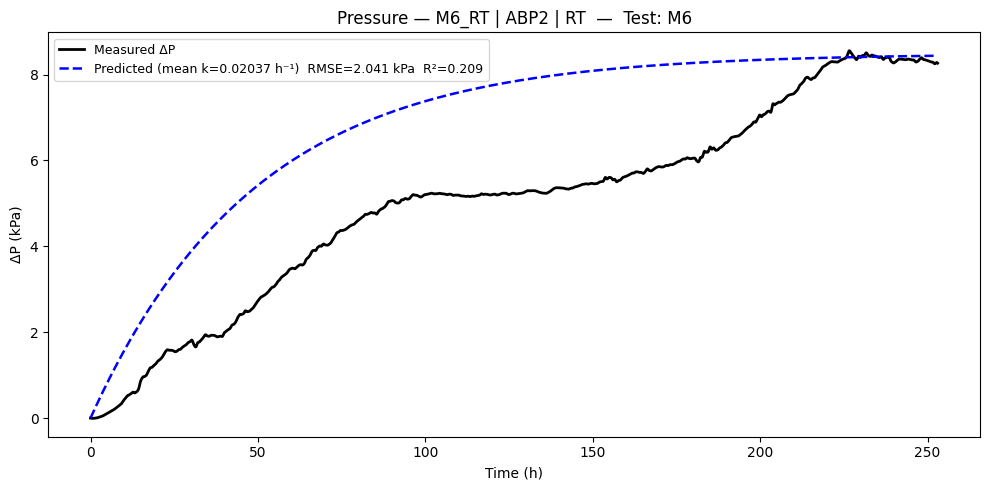

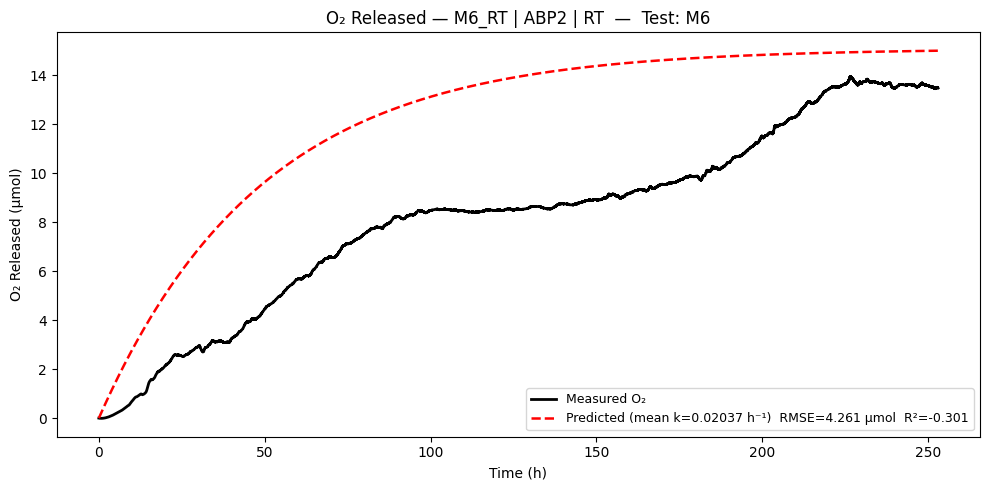

c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



TEST SAMPLE : M6_RT | Sensor = MPR | Temp = RT
  Pressure  — RMSE = 2.6105 kPa,  R² = -0.1861
  O2        — RMSE = 5.2379 µmol, R² = -0.8005


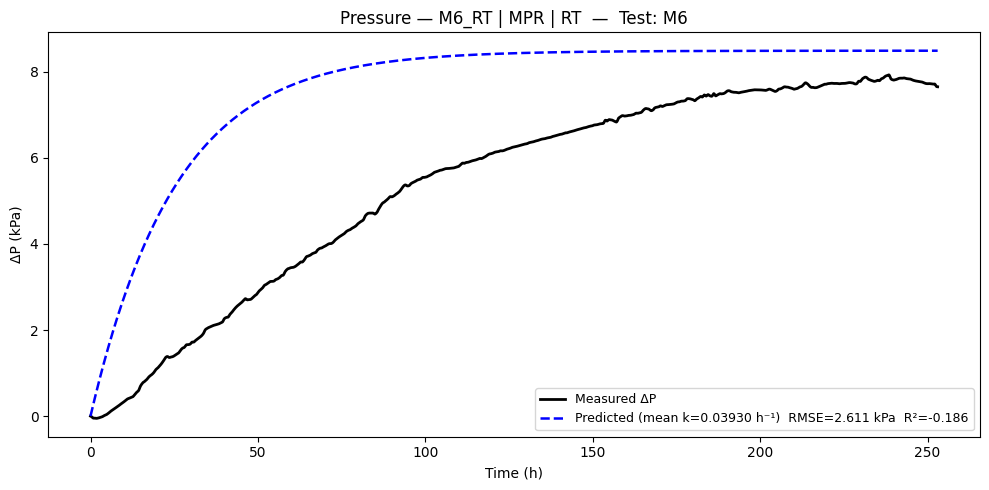

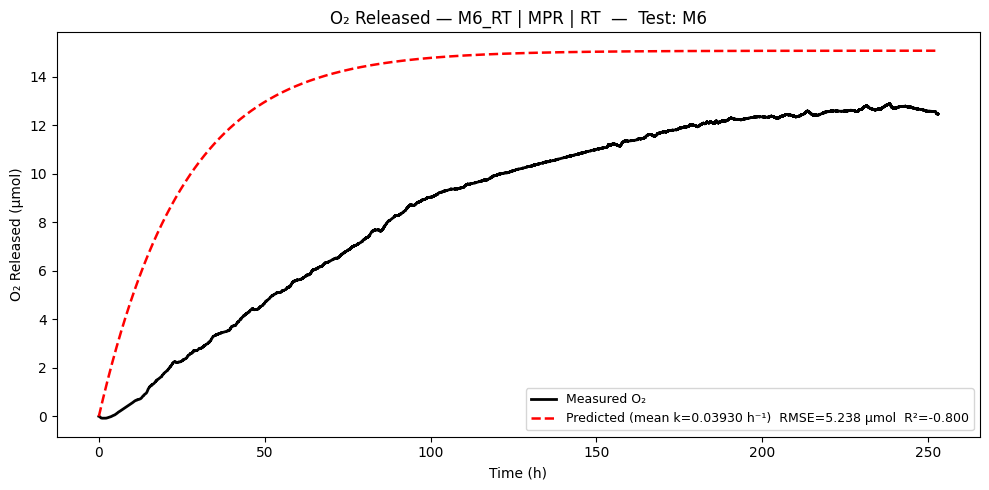

c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



TEST SAMPLE : M6_37C | Sensor = ABP2 | Temp = 37C
  Pressure  — RMSE = 0.4640 kPa,  R² = 0.9218
  O2        — RMSE = 0.5959 µmol, R² = 0.9536


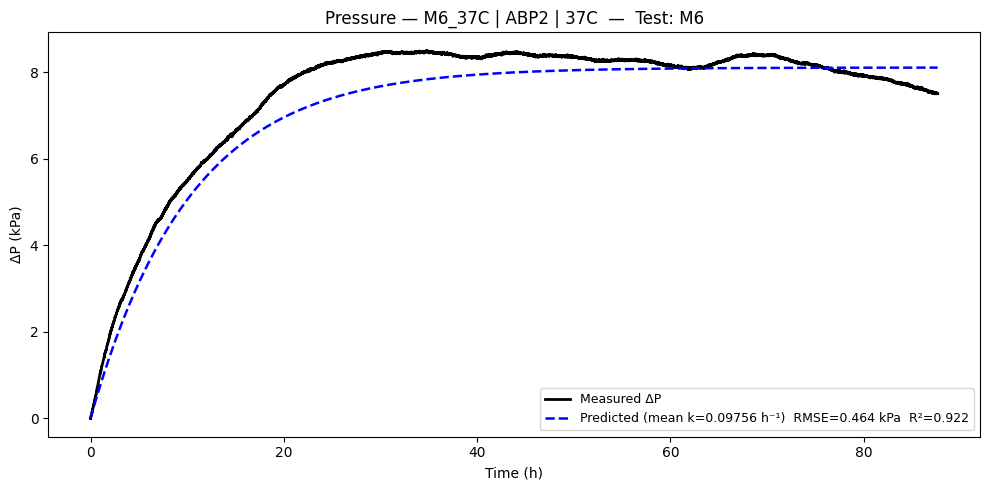

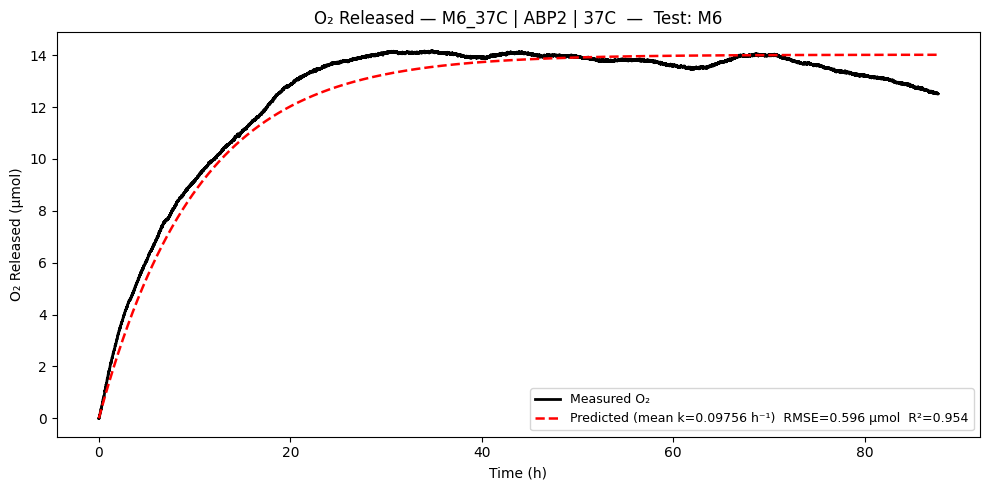

c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



TEST SAMPLE : M6_37C | Sensor = MPR | Temp = 37C
  Pressure  — RMSE = 1.3603 kPa,  R² = 0.6751
  O2        — RMSE = 1.6698 µmol, R² = 0.7967


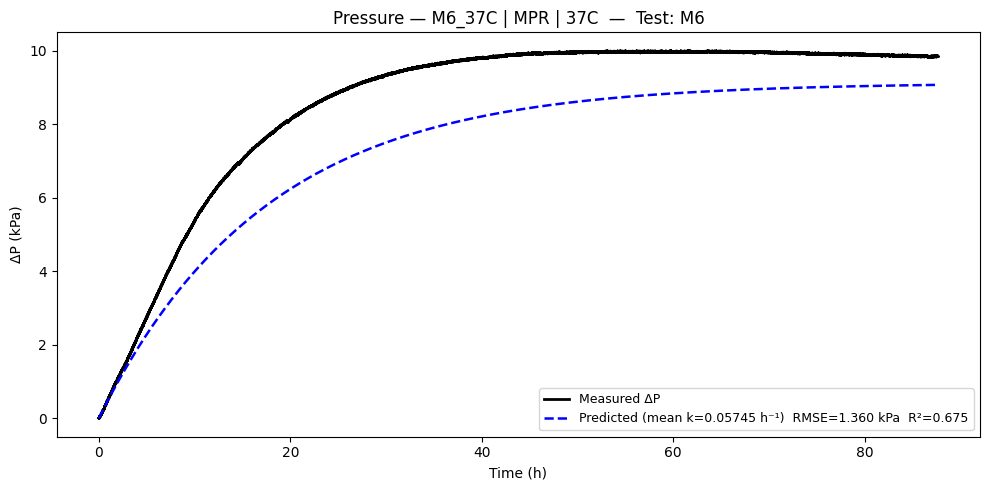

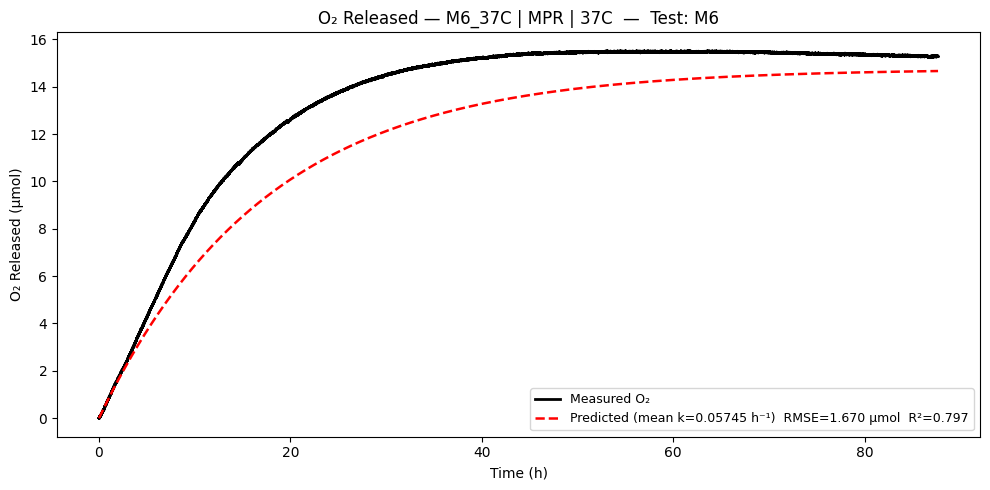

Skipping validation for M6_45C ABP2 (45C) — no k training data available yet


c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



TEST SAMPLE : M6_45C | Sensor = MPR | Temp = 45C
  Pressure  — RMSE = 0.3608 kPa,  R² = 0.9688
  O2        — RMSE = 0.9148 µmol, R² = 0.9122


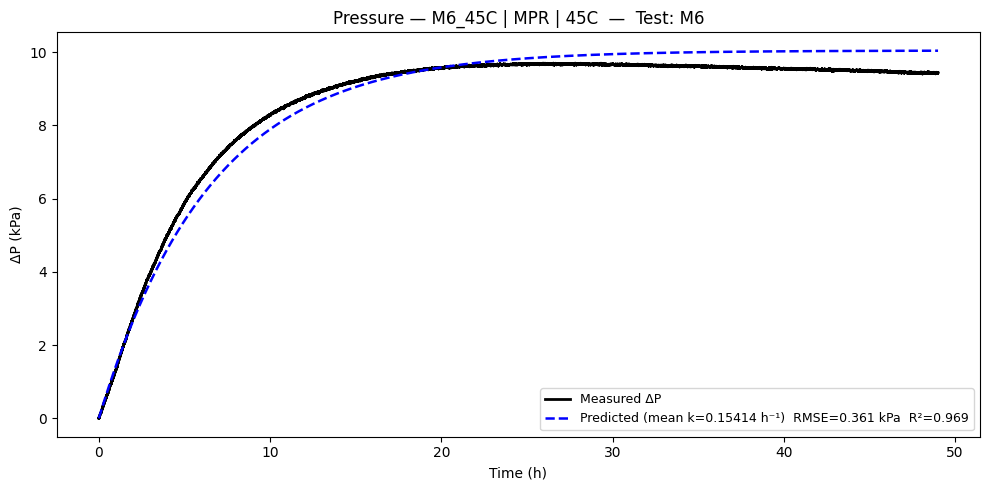

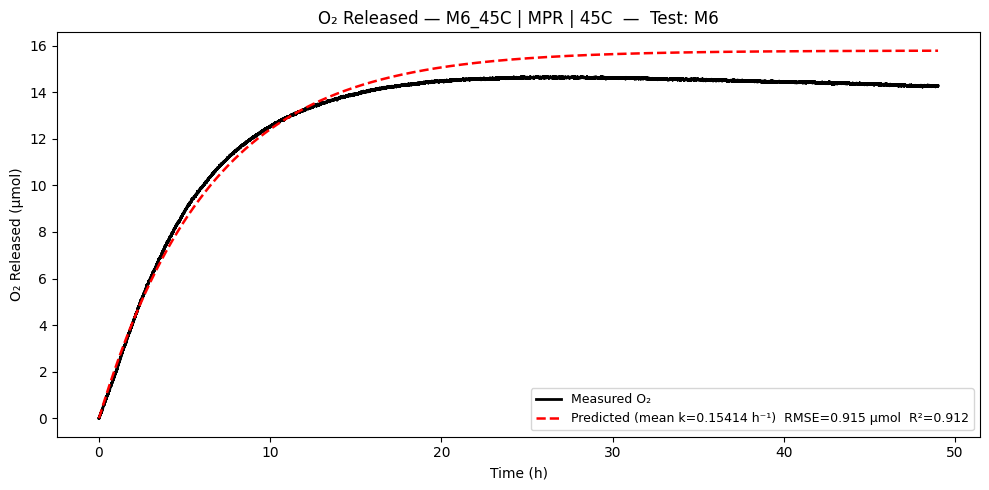

Skipping validation for M6_50C ABP2 (50C) — no k training data available yet


c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



TEST SAMPLE : M6_50C | Sensor = MPR | Temp = 50C
  Pressure  — RMSE = 0.6423 kPa,  R² = 0.8547
  O2        — RMSE = 1.3679 µmol, R² = 0.7027


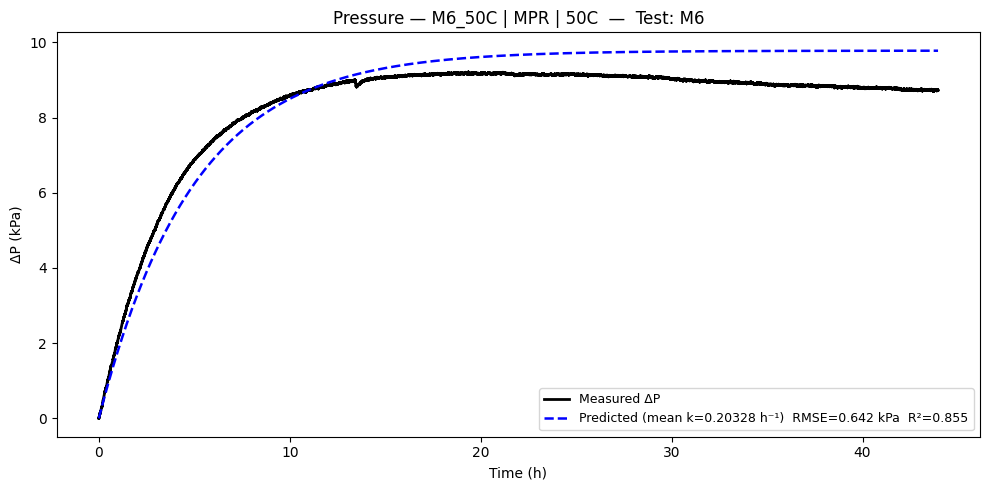

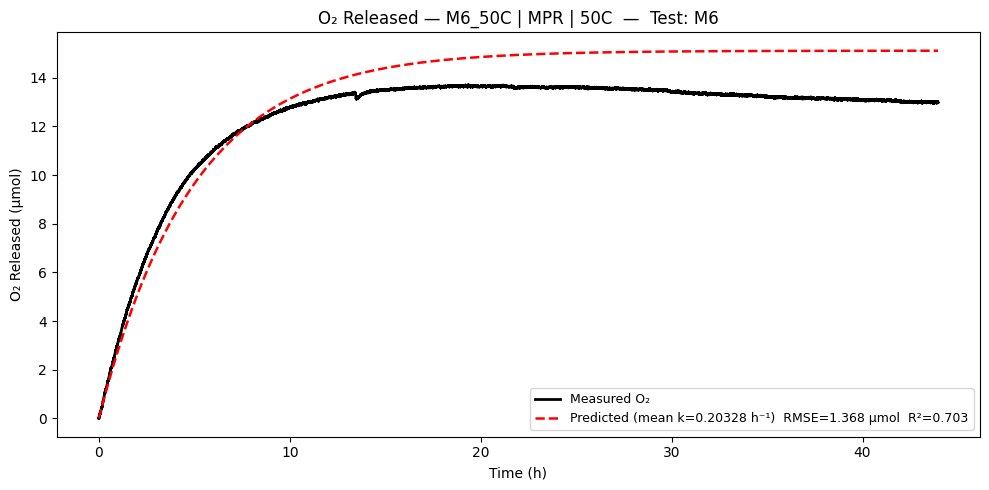

In [ ]:
  # Not using GPR and Ridge predictions for now since they are very close to the mean_k prediction, can be added later for comparison

import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.metrics import mean_squared_error, r2_score


CSV_FOLDER = r"C:\Users\chand\Documents\GitHub\Thesis\csv_combi"
TIME_COL     = "Time (h)"
TEMP_COL_K   = "calibrated temperature (K)"
TEMP_COL_37C = "calibrated temperature (K)"   # column is labelled K but stores Celsius for 37C files  // this has to be fixed soon, not a problem for now
PRESS_COL_RT_ABP2  = "ABP2 DWT denoised pressure (kPa)"
PRESS_COL_RT_MPR   = "MPR SG pressure (kPa)"

PRESS_COL_ELEV_ABP2 = "ABP2 SG smoothed pressure (kPa)"
PRESS_COL_ELEV_MPR  = "MPR SG smoothed pressure (kPa)"

O2_COL_ABP2 = "ABP2 O2 Released (µmol)"
O2_COL_MPR  = "MPR O2 Released (µmol)"


TEMP_NOMINAL_K = {"RT": 298.15, "37C": 310.15, "45C": 318.15, "50C": 323.15}
R_J = 8.314         
TEST_SAMPLE_PREFIX = "M6"



def ml_to_m3(ml):
    return ml * 1e-6


def mM_ml_to_mol(C_mM, V_ml):
    return C_mM * V_ml * 1e-6


def get_pressure_col(temp_label, sensor):
    if temp_label == "RT":
        return PRESS_COL_RT_ABP2 if sensor == "ABP2" else PRESS_COL_RT_MPR
    return PRESS_COL_ELEV_ABP2 if sensor == "ABP2" else PRESS_COL_ELEV_MPR


def get_o2_col(sensor):
    return O2_COL_ABP2 if sensor == "ABP2" else O2_COL_MPR


def O2_model_umol(t, eta_hat, C_mM, Vsol_ml, k):
    """Predicted O2 released (µmol) = η × N0 × (1 − exp(−k·t))"""
    n_gen_mol = mM_ml_to_mol(C_mM, Vsol_ml)
    return eta_hat * n_gen_mol * (1.0 - np.exp(-k * t)) * 1e6

def calc_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return rmse, r2



#Source: Battino et al. 1983, "The Solubility of Oxygen and Ozone in Liquids"
#kH_ref = 1.3e-3 mol/(L·atm) at T_ref = 298.15 K
_battino_T  = np.array([273.15, 278.15, 283.15, 288.15, 293.15,
                         298.15, 303.15, 308.15, 313.15, 318.15,
                         323.15, 328.15, 333.15, 338.15, 343.15, 348.15])

_battino_dH = np.array([-17.60, -16.18, -15.16, -14.15, -13.13,
                         -12.11, -11.10, -10.08,  -9.06,  -8.05,
                          -7.03,  -6.01,  -5.00,  -3.98,  -2.97,  -1.95])
_kH_ref = 1.3e-3      
_T_ref  = 298.15      
_dH_ref = -12.11      


def calc_H_SI(Tk):                     # H(T) is calculated for every time stamp   and then for the max pressure equation (17), it only 
    dH_T   = np.interp(Tk, _battino_T, _battino_dH)
    dH_avg = ((_dH_ref + dH_T) / 2.0) * 1000.0     
    kH_mol_per_L_per_atm = _kH_ref * np.exp(
        -(dH_avg / R_J) * (1.0 / Tk - 1.0 / _T_ref)
    )
    return kH_mol_per_L_per_atm * 1e3 / 101325.0





def calc_eta(P_peak_kPa, T_peak_K, C_mM, Vsol_ml, Vg_ml):
    P_peak_Pa = P_peak_kPa * 1000.0
    Vg_m3     = ml_to_m3(Vg_ml)
    Vsol_m3   = ml_to_m3(Vsol_ml)
    H_T       = calc_H_SI(T_peak_K)              
    n_gas_max = P_peak_Pa * Vg_m3 / (R_J * T_peak_K)   
    n_aq_max  = H_T * P_peak_Pa * Vsol_m3               
    n_gen_max = mM_ml_to_mol(C_mM, Vsol_ml)             
    return (n_gas_max + n_aq_max) / n_gen_max



def P_model(t, Tk, eta_hat, C_mM, Vsol_ml, Vg_ml, k):
    Vg_m3   = ml_to_m3(Vg_ml)
    Vsol_m3 = ml_to_m3(Vsol_ml)
    H_T     = calc_H_SI(Tk)                             
    n_gen_mol   = mM_ml_to_mol(C_mM, Vsol_ml)           
    numerator   = eta_hat * n_gen_mol * (1.0 - np.exp(-k * t))
    denominator = Vg_m3 / (R_J * Tk) + H_T * Vsol_m3   
    return (numerator / denominator) / 1000.0           



def P_max_model_Hmean(H_mean, eta_hat, C_mM, Vsol_ml, Vg_ml, T_mean):
    Vg_m3   = ml_to_m3(Vg_ml)
    Vsol_m3 = ml_to_m3(Vsol_ml)
    n_gen_mol   = mM_ml_to_mol(C_mM, Vsol_ml)
    denominator = Vg_m3 / (R_J * T_mean) + H_mean * Vsol_m3
    return (eta_hat * n_gen_mol / denominator) / 1000.0  



def interp_piecewise_clamped(x_train, y_train, x_query):
    x = np.asarray(x_train, dtype=float)
    y = np.asarray(y_train, dtype=float)
    order = np.argsort(x)
    return float(np.interp(float(x_query), x[order], y[order]))



def fit_k_models(df_train):
    X = df_train[["C_mM"]].values.astype(float)
    y = df_train["k"].values.astype(float)

    ridge = Ridge(alpha=1e-6)
    ridge.fit(X, y)

    kernel = (
        ConstantKernel(1.0, (1e-3, 1e3))            # Chose this based on the bets choice from the options i this website: https://scikit-learn.org/stable/modules/gaussian_process.html
        * RBF(length_scale=0.5, length_scale_bounds=(1e-2, 1e2))
        + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-1))
    )
    gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=0)
    gpr.fit(X, y)

    return ridge, gpr


def predict_k_ridge(ridge, C):
    return float(ridge.predict(np.array([[float(C)]]))[0])


def predict_k_gpr(gpr, C):
    return float(gpr.predict(np.array([[float(C)]]), return_std=False)[0])



experiments = [
    ("M1_RT",  "ABP2", "RT",  1.2,  6.0,  4.0,  "M1_RT_ABP2.csv"),
    ("M2_RT",  "ABP2", "RT",  1.6,  6.0,  4.0,  "M2_RT_ABP2.csv"),
    ("M4_RT",  "ABP2", "RT",  2.5,  6.0,  4.0,  "M4_RT_ABP2.csv"),
   

    ("M1_RT",  "MPR",  "RT",  1.2,  6.0,  4.0,  "M1_RT_MPR.csv"),
   

    ("M1_37C", "ABP2", "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ("M2_37C", "ABP2", "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ("M3_37C", "ABP2", "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
   

    ("M1_37C", "MPR",  "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ("M2_37C", "MPR",  "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ("M3_37C", "MPR",  "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),

    
    ("M3_45C", "ABP2", "45C", 2.0,  6.0,  4.0,  "M3_45C_ABP2_MPR.csv"),
    ("M3_45C", "MPR",  "45C", 2.0,  6.0,  4.0,  "M3_45C_ABP2_MPR.csv"),
    ("M6_45C", "ABP2", "45C", 2.67, 6.0,  4.0,  "M6_45C_ABP2_MPR.csv"),
    ("M6_45C", "MPR",  "45C", 2.67, 6.0,  4.0,  "M6_45C_ABP2_MPR.csv"),

    
    ("M3_50C", "ABP2", "50C", 2.0,  6.0,  4.0,  "M3_50C_ABP2_MPR.csv"),
    ("M3_50C", "MPR",  "50C", 2.0,  6.0,  4.0,  "M3_50C_ABP2_MPR.csv"),
    ("M6_50C", "ABP2", "50C", 2.67, 6.0,  4.0,  "M6_50C_ABP2_MPR.csv"),
    ("M6_50C", "MPR",  "50C", 2.67, 6.0,  4.0,  "M6_50C_ABP2_MPR.csv"),
]

test_experiments = [
    ("M6_RT",  "ABP2", "RT",  2.67, 5.78, 4.22, "M6_RT_ABP2.csv"),
    ("M6_RT",  "MPR",  "RT",  2.67, 5.78, 4.22, "M6_RT_MPR.csv"),
    ("M6_37C", "ABP2", "37C", 2.67, 5.7,  4.3,  "M6_37C_ABP2_MPR.csv"),
    ("M6_37C", "MPR",  "37C", 2.67, 6.0,  4.0,  "M6_37C_ABP2_MPR.csv"),
    ("M6_45C", "ABP2", "45C", 2.67, 6.0,  4.0,  "M6_45C_ABP2_MPR.csv"),
    ("M6_45C", "MPR",  "45C", 2.67, 6.0,  4.0,  "M6_45C_ABP2_MPR.csv"),
    ("M6_50C", "ABP2", "50C", 2.67, 6.0,  4.0,  "M6_50C_ABP2_MPR.csv"),
    ("M6_50C", "MPR",  "50C", 2.67, 6.0,  4.0,  "M6_50C_ABP2_MPR.csv"),
]


K_VALUES = {
    ("M1_RT",  "ABP2"): 0.0330,
    ("M2_RT",  "ABP2"): 0.0159,
    ("M4_RT",  "ABP2"): 0.0122,


    ("M1_RT",  "MPR") : 0.03930,
    

    ("M1_37C", "ABP2"): 0.09818,
    ("M2_37C", "ABP2"): 0.07972,
    ("M3_37C", "ABP2"): 0.11477,
    

    ("M1_37C", "MPR") : 0.04689,
    ("M2_37C", "MPR") : 0.07874,
    ("M3_37C", "MPR") : 0.04671,

   
    ("M3_45C", "ABP2"): None,
    ("M3_45C", "MPR") : 0.154140,
    ("M6_45C", "ABP2"): None,
    ("M6_45C", "MPR") : 0.156097
,

   
    ("M3_50C", "ABP2"): None,
    ("M3_50C", "MPR") : 0.203281,
    ("M6_50C", "ABP2"): None,
    ("M6_50C", "MPR") : 0.219068,
}



rows = []

for (sample, sensor, temp_label, C_mM, Vsol_ml, Vg_ml, csv_file) in experiments:
    k = K_VALUES.get((sample, sensor))
    if k is None:
        print(f"Skipping {sample} {sensor} — k not yet available")
        continue
    csv_path = os.path.join(CSV_FOLDER, csv_file)
    df = pd.read_csv(csv_path)
    P_col = get_pressure_col(temp_label, sensor)
    t      = df[TIME_COL].values.astype(float);  t -= t[0]
    P_meas = df[P_col].values.astype(float);     P_meas -= P_meas[0]
    Tk = df[TEMP_COL_K].values.astype(float)
    if temp_label != "RT":         # 37C CSVs store Celsius despite column name saying K
        Tk = Tk + 273.15
    idx_peak   = int(np.argmax(P_meas))
    P_peak_kPa = float(P_meas[idx_peak])
    T_peak_K   = float(Tk[idx_peak])

    eta_peak = calc_eta(P_peak_kPa, T_peak_K, C_mM, Vsol_ml, Vg_ml)

    rows.append({
        "sample":        sample,
        "sample_prefix": sample.split("_")[0],
        "sensor":        sensor,
        "temp_label":    temp_label,
        "C_mM":          float(C_mM),
        "Vsol_ml":       float(Vsol_ml),
        "Vg_ml":         float(Vg_ml),
        "k":             float(k),
        "eta_peak":      float(eta_peak),   # η from Eq 13
        "csv":           csv_file,
    })

df_sum = pd.DataFrame(rows)



#
#VALIDATION
for (sample, sensor, temp_label, C_test, Vsol_ml, Vg_ml, csv_test) in test_experiments:

    
    # Use the same eta for both sensors within the same temperature group
    df_eta = df_sum[
        (df_sum["sample_prefix"] != TEST_SAMPLE_PREFIX) &
        (df_sum["temp_label"] == temp_label)
    ].copy()

    # Keep k training sensor-specific
    df_train = df_sum[
        (df_sum["sample_prefix"] != TEST_SAMPLE_PREFIX) &
        (df_sum["sensor"] == sensor) &
        (df_sum["temp_label"] == temp_label)
    ].copy()
    
    if len(df_eta) == 0:
        print(f"Skipping validation for {sample} {sensor} ({temp_label}) — no eta training data available yet")
        continue

    if len(df_train) == 0:
        print(f"Skipping validation for {sample} {sensor} ({temp_label}) — no k training data available yet")
        continue

    eta_hat = float(df_eta["eta_peak"].mean())
    k_interp = interp_piecewise_clamped(df_train["C_mM"], df_train["k"], C_test)
    mean_k = float(df_train["k"].mean())

    
    ridge, gpr = fit_k_models(df_train)
    k_ridge = max(predict_k_ridge(ridge, C_test), 1e-6)
    k_gpr   = max(predict_k_gpr(gpr,   C_test), 1e-6)
    k_interp = max(k_interp, 1e-6)

    
    df_test    = pd.read_csv(os.path.join(CSV_FOLDER, csv_test))
    P_col      = get_pressure_col(temp_label, sensor)
    O2_col     = get_o2_col(sensor)
    t          = df_test[TIME_COL].values.astype(float);  t -= t[0]
    P_meas     = df_test[P_col].values.astype(float);     P_meas -= P_meas[0]
    O2_meas    = df_test[O2_col].values.astype(float);    O2_meas -= O2_meas[0]
    T_nominal  = TEMP_NOMINAL_K[temp_label]
    Tk         = np.full(len(t), T_nominal)

    #P{redicted pressure curves
    P_mean_k  = P_model(t, Tk, eta_hat, C_test, Vsol_ml, Vg_ml, mean_k)
    T_mean    = T_nominal
    H_mean    = float(calc_H_SI(T_nominal))
    Pmax_pred = P_max_model_Hmean(H_mean, eta_hat, C_test, Vsol_ml, Vg_ml, T_mean)

    #predicted O2 curves
    O2_mean_k = O2_model_umol(t, eta_hat, C_test, Vsol_ml, mean_k)

    #metrics
    rmse_P_mean_k,  r2_P_mean_k  = calc_metrics(P_meas,  P_mean_k)
    rmse_O2_mean_k, r2_O2_mean_k = calc_metrics(O2_meas, O2_mean_k)

    print(f"\nTEST SAMPLE : {sample} | Sensor = {sensor} | Temp = {temp_label}")
    print(f"  Pressure  — RMSE = {rmse_P_mean_k:.4f} kPa,  R² = {r2_P_mean_k:.4f}")
    print(f"  O2        — RMSE = {rmse_O2_mean_k:.4f} µmol, R² = {r2_O2_mean_k:.4f}")

    title_base = f"{sample} | {sensor} | {temp_label}  —  Test: {TEST_SAMPLE_PREFIX}"

    # Graph 1 Pressure
    
    # Not using GPR and Ridge predictions for now since they are very close to the mean_k prediction, can be added later for comparison
    plt.figure(figsize=(10, 5))
    plt.plot(t, P_meas,    "k-",  lw=2,   label="Measured ΔP")
    plt.plot(t, P_mean_k,  "b--", lw=1.8, label=f"Predicted (mean k={mean_k:.5f} h⁻¹)  RMSE={rmse_P_mean_k:.3f} kPa  R²={r2_P_mean_k:.3f}")
    plt.xlabel("Time (h)")
    plt.ylabel("ΔP (kPa)")
    plt.title("Pressure — " + title_base)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    # Graph 2  O2 released
    plt.figure(figsize=(10, 5))
    plt.plot(t, O2_meas,   "k-",  lw=2,   label="Measured O₂")
    plt.plot(t, O2_mean_k, "r--", lw=1.8, label=f"Predicted (mean k={mean_k:.5f} h⁻¹)  RMSE={rmse_O2_mean_k:.3f} µmol  R²={r2_O2_mean_k:.3f}")
    plt.xlabel("Time (h)")
    plt.ylabel("O₂ Released (µmol)")
    plt.title("O₂ Released — " + title_base)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()




# Row wise k approach



================ SUMMARY TABLE ================

sample sensor temp_label  C_mM        k  eta_peak
 M1_RT   ABP2         RT  1.20 0.033000  0.973602
 M2_RT   ABP2         RT  1.60 0.015900  0.971831
 M4_RT   ABP2         RT  2.50 0.012200  1.007367
 M6_RT   ABP2         RT  2.67 0.008700  0.996080
 M1_RT    MPR         RT  1.20 0.039300  0.956069
 M6_RT    MPR         RT  2.67 0.006921  0.920726
M1_37C   ABP2        37C  1.20 0.098180  0.794804
M2_37C   ABP2        37C  1.60 0.079720  1.024490
M3_37C   ABP2        37C  2.00 0.114770  0.939630
M6_37C   ABP2        37C  2.67 0.118947  0.965997
M1_37C    MPR        37C  1.20 0.046890  0.794459
M2_37C    MPR        37C  1.60 0.078740  0.962405
M3_37C    MPR        37C  2.00 0.046710  1.012201
M6_37C    MPR        37C  2.67 0.079144  1.009585

Note: eta_peak = η from Eq 13 = (n_gas,max + n_aq,max) / n_gen,max

  [build_temp_bin_k] Total time stamps pooled : 2,521,795
  [build_temp_bin_k] Temperature range        : 295.50 – 302.81 K
  [buil

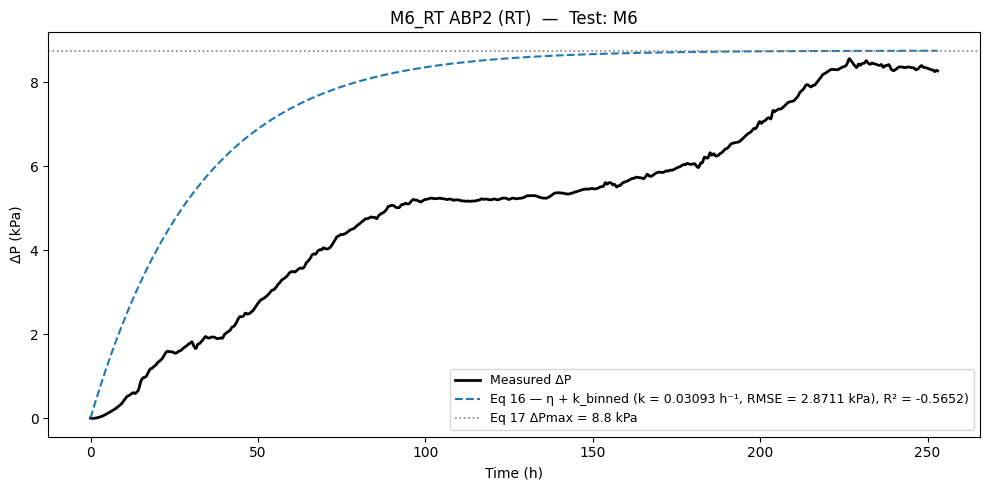


Skip M6_RT MPR RT: need ≥ 2 training samples.

  [build_temp_bin_k] Total time stamps pooled : 777,593
  [build_temp_bin_k] Temperature range        : 309.79 – 310.07 K
  [build_temp_bin_k] Number of bins formed    : 2
  [build_temp_bin_k] Samples included         : ['M1_37C', 'M2_37C', 'M3_37C']

TEST SAMPLE : M6_37C  |  Sensor = ABP2  |  Temp = 37C
Training    : ['M1_37C', 'M2_37C', 'M3_37C']
  C_test    = 2.6700 mM
  η_hat     = 0.939630
  k_binned  = 0.099285 h⁻¹  (T bin = 310.15 K)
  ΔPmax     = 8.27 kPa
  RMSE      = 0.3684 kPa
  R²        = 0.9507


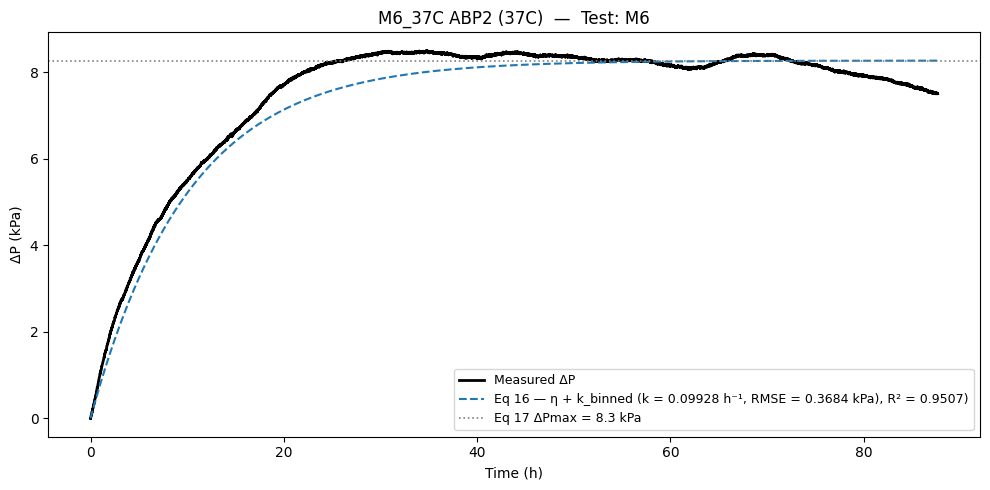


  [build_temp_bin_k] Total time stamps pooled : 777,593
  [build_temp_bin_k] Temperature range        : 309.79 – 310.07 K
  [build_temp_bin_k] Number of bins formed    : 2
  [build_temp_bin_k] Samples included         : ['M1_37C', 'M2_37C', 'M3_37C']

TEST SAMPLE : M6_37C  |  Sensor = MPR  |  Temp = 37C
Training    : ['M1_37C', 'M2_37C', 'M3_37C']
  C_test    = 2.6700 mM
  η_hat     = 1.012201
  k_binned  = 0.057678 h⁻¹  (T bin = 310.15 K)
  ΔPmax     = 10.03 kPa
  RMSE      = 0.7214 kPa
  R²        = 0.9086


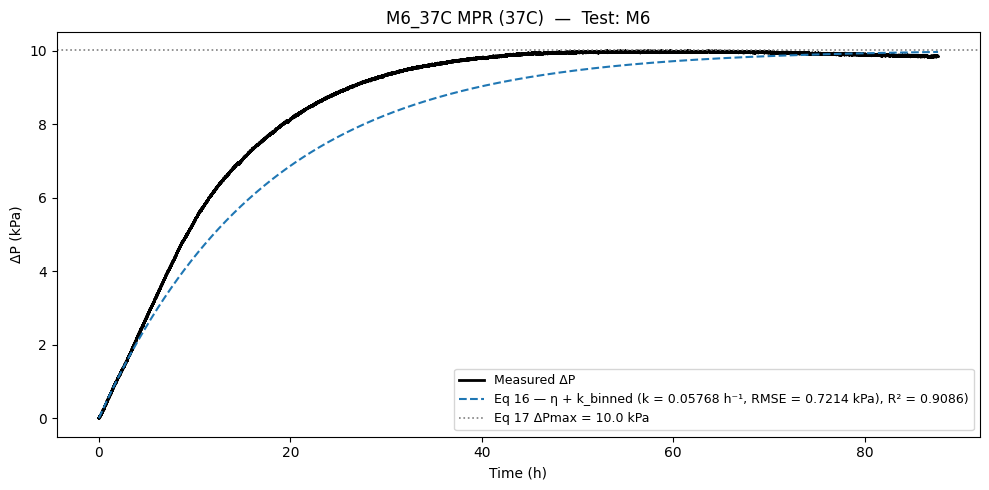

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel



CSV_FOLDER = r"C:\Users\chand\Documents\GitHub\Thesis\csv_combi"
TIME_COL     = "Time (h)"
TEMP_COL_K   = "calibrated temperature (K)"
TEMP_COL_37C = "calibrated temperature (K)"   # column is labelled K but stores Celsius for 37C files  // this has to be fixed soon, not a problem for now
PRESS_COL_RT_ABP2  = "ABP2 DWT denoised pressure (kPa)"
PRESS_COL_RT_MPR   = "MPR SG pressure (kPa)"
PRESS_COL_37C_ABP2 = "ABP2 SG smoothed pressure (kPa)"
PRESS_COL_37C_MPR  = "MPR SG smoothed pressure (kPa)"
R_J = 8.314         #J/(mol·K)  
TEST_SAMPLE_PREFIX = "M6"



def ml_to_m3(ml):
    return ml * 1e-6


def mM_ml_to_mol(C_mM, V_ml):
    return C_mM * V_ml * 1e-6


def get_pressure_col(temp_label, sensor):
    if temp_label == "RT":
        return PRESS_COL_RT_ABP2 if sensor == "ABP2" else PRESS_COL_RT_MPR
    return PRESS_COL_37C_ABP2 if sensor == "ABP2" else PRESS_COL_37C_MPR



#Source: Battino et al. 1983, "The Solubility of Oxygen and Ozone in Liquids"
#kH_ref = 1.3e-3 mol/(L·atm) at T_ref = 298.15 K
_battino_T  = np.array([273.15, 278.15, 283.15, 288.15, 293.15,
                         298.15, 303.15, 308.15, 313.15, 318.15,
                         323.15, 328.15, 333.15, 338.15, 343.15, 348.15])

_battino_dH = np.array([-17.60, -16.18, -15.16, -14.15, -13.13,
                         -12.11, -11.10, -10.08,  -9.06,  -8.05,
                          -7.03,  -6.01,  -5.00,  -3.98,  -2.97,  -1.95])
_kH_ref = 1.3e-3      
_T_ref  = 298.15      
_dH_ref = -12.11      


def calc_H_SI(Tk):                     # H(T) is calculated for every time stamp  and then for the max pressure equation (17), it only 
    dH_T   = np.interp(Tk, _battino_T, _battino_dH)
    dH_avg = ((_dH_ref + dH_T) / 2.0) * 1000.0     # kJ/mol to J/mol
    kH_mol_per_L_per_atm = _kH_ref * np.exp(
        -(dH_avg / R_J) * (1.0 / Tk - 1.0 / _T_ref)
    )
    return kH_mol_per_L_per_atm * 1e3 / 101325.0





def calc_eta(P_peak_kPa, T_peak_K, C_mM, Vsol_ml, Vg_ml):

    P_peak_Pa = P_peak_kPa * 1000.0
    Vg_m3     = ml_to_m3(Vg_ml)
    Vsol_m3   = ml_to_m3(Vsol_ml)
    H_T       = calc_H_SI(T_peak_K)             
    n_gas_max = P_peak_Pa * Vg_m3 / (R_J * T_peak_K)   
    n_aq_max  = H_T * P_peak_Pa * Vsol_m3               
    n_gen_max = mM_ml_to_mol(C_mM, Vsol_ml)             

    return (n_gas_max + n_aq_max) / n_gen_max



def P_model(t, Tk, eta_hat, C_mM, Vsol_ml, Vg_ml, k):
    Vg_m3   = ml_to_m3(Vg_ml)
    Vsol_m3 = ml_to_m3(Vsol_ml)
    H_T     = calc_H_SI(Tk)                             

    n_gen_mol   = mM_ml_to_mol(C_mM, Vsol_ml)           
    numerator   = eta_hat * n_gen_mol * (1.0 - np.exp(-k * t))
    denominator = Vg_m3 / (R_J * Tk) + H_T * Vsol_m3   

    return (numerator / denominator) / 1000.0          



def P_max_model_Hmean(H_mean, eta_hat, C_mM, Vsol_ml, Vg_ml, T_mean):
    
    Vg_m3   = ml_to_m3(Vg_ml)
    Vsol_m3 = ml_to_m3(Vsol_ml)

    n_gen_mol   = mM_ml_to_mol(C_mM, Vsol_ml)
    denominator = Vg_m3 / (R_J * T_mean) + H_mean * Vsol_m3

    return (eta_hat * n_gen_mol / denominator) / 1000.0  




def interp_piecewise_clamped(x_train, y_train, x_query):
    
    x = np.asarray(x_train, dtype=float)
    y = np.asarray(y_train, dtype=float)
    order = np.argsort(x)
    return float(np.interp(float(x_query), x[order], y[order]))


#
def fit_k_models(df_train):
    X = df_train[["C_mM"]].values.astype(float)
    y = df_train["k"].values.astype(float)

    ridge = Ridge(alpha=1e-6)
    ridge.fit(X, y)

    kernel = (
        ConstantKernel(1.0, (1e-3, 1e3))
        * RBF(length_scale=0.5, length_scale_bounds=(1e-2, 1e2))
        + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-1))
    )
    gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=0)
    gpr.fit(X, y)

    return ridge, gpr


def predict_k_ridge(ridge, C):
    return float(ridge.predict(np.array([[float(C)]]))[0])


def predict_k_gpr(gpr, C):
    return float(gpr.predict(np.array([[float(C)]]), return_std=False)[0])


def _compute_ea(k_rt, k_37c, T_RT=298.15, T_37C=310.15):
    return R_J * np.log(k_37c / k_rt) / (1.0/T_RT - 1.0/T_37C)


def build_temp_bin_k(df_train, sensor, bin_width=0.5):
    ea_vals = []
    for _, row in df_train.iterrows():
        p    = row["sample_prefix"]
        krt  = K_VALUES.get((f"{p}_RT",  sensor))
        k37c = K_VALUES.get((f"{p}_37C", sensor))
        if krt and k37c:
            ea_vals.append(_compute_ea(krt, k37c))
    mean_Ea = float(np.mean(ea_vals)) if ea_vals else 70000.0

    T_all, k_all = [], []
    for _, row in df_train.iterrows():
        p     = row["sample_prefix"]
        k_ref = row["k"]
        t_lbl = row["temp_label"]
        T_ref = 298.15 if t_lbl == "RT" else 310.15

        krt  = K_VALUES.get((f"{p}_RT",  sensor))
        k37c = K_VALUES.get((f"{p}_37C", sensor))
        Ea   = _compute_ea(krt, k37c) if (krt and k37c) else mean_Ea

        df_raw = pd.read_csv(os.path.join(CSV_FOLDER, row["csv"]))
        Tk_raw = df_raw[TEMP_COL_K].values.astype(float)
        if t_lbl == "37C":
            Tk_raw += 273.15

        k_series = k_ref * np.exp(-Ea / R_J * (1.0 / Tk_raw - 1.0 / T_ref))
        T_all.append(Tk_raw)
        k_all.append(k_series)
        


    T_arr = np.concatenate(T_all)
    k_arr = np.concatenate(k_all)

    T_min = np.floor(T_arr.min() / bin_width) * bin_width
    T_max = np.ceil(T_arr.max()  / bin_width) * bin_width
    edges = np.arange(T_min, T_max + bin_width, bin_width)

    bin_dict = {}
    for i in range(len(edges) - 1):
        mask = (T_arr >= edges[i]) & (T_arr < edges[i + 1])
        if mask.sum() > 0:
            centre = round((edges[i] + edges[i + 1]) / 2, 4)
            bin_dict[centre] = float(np.mean(k_arr[mask]))
            
    print(f"\n  [build_temp_bin_k] Total time stamps pooled : {len(T_arr):,}")
    print(f"  [build_temp_bin_k] Temperature range        : {T_arr.min():.2f} – {T_arr.max():.2f} K")
    print(f"  [build_temp_bin_k] Number of bins formed    : {len(bin_dict)}")
    print(f"  [build_temp_bin_k] Samples included         : {list(df_train['sample'].values)}")

    return bin_dict


def lookup_k_from_bins(bin_dict, T_query, bin_width=0.5):
    centres = np.array(list(bin_dict.keys()))
    nearest = centres[np.argmin(np.abs(centres - T_query))]
    return max(bin_dict[nearest], 1e-6)


experiments = [
    ("M1_RT",  "ABP2", "RT",  1.2,  6.0,  4.0,  "M1_RT_ABP2.csv"),
    ("M2_RT",  "ABP2", "RT",  1.6,  6.0,  4.0,  "M2_RT_ABP2.csv"),
    ("M4_RT",  "ABP2", "RT",  2.5,  6.0,  4.0,  "M4_RT_ABP2.csv"),
    ("M6_RT",  "ABP2", "RT",  2.67, 5.78, 4.22, "M6_RT_ABP2.csv"),

    ("M1_RT",  "MPR",  "RT",  1.2,  6.0,  4.0,  "M1_RT_MPR.csv"),
    ("M6_RT",  "MPR",  "RT",  2.67, 5.78, 4.22, "M6_RT_MPR.csv"),

    ("M1_37C", "ABP2", "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ("M2_37C", "ABP2", "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ("M3_37C", "ABP2", "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
    ("M6_37C", "ABP2", "37C", 2.67, 5.7,  4.3,  "M6_37C_ABP2_MPR.csv"),

    ("M1_37C", "MPR",  "37C", 1.2,  6.0,  4.0,  "M1_37C_ABP2_MPR.csv"),
    ("M2_37C", "MPR",  "37C", 1.6,  6.0,  4.0,  "M2_37C_ABP2_MPR.csv"),
    ("M3_37C", "MPR",  "37C", 2.0,  6.0,  4.0,  "M3_37C_ABP2_MPR.csv"),
    ("M6_37C", "MPR",  "37C", 2.67, 6.0,  4.0,  "M6_37C_ABP2_MPR.csv"),
]

K_VALUES = {
    ("M1_RT",  "ABP2"): 0.0330,
    ("M2_RT",  "ABP2"): 0.0159,
    ("M4_RT",  "ABP2"): 0.0122,
    ("M6_RT",  "ABP2"): 0.0087,

    ("M1_RT",  "MPR") : 0.03930,
    ("M6_RT",  "MPR") : 0.006921,

    ("M1_37C", "ABP2"): 0.09818,
    ("M2_37C", "ABP2"): 0.07972,
    ("M3_37C", "ABP2"): 0.11477,
    ("M6_37C", "ABP2"): 0.118947,

    ("M1_37C", "MPR") : 0.04689,
    ("M2_37C", "MPR") : 0.07874,
    ("M3_37C", "MPR") : 0.04671,
    ("M6_37C", "MPR") : 0.079144,
}



rows = []

for (sample, sensor, temp_label, C_mM, Vsol_ml, Vg_ml, csv_file) in experiments:
    k = K_VALUES.get((sample, sensor))
    if k is None:
        raise ValueError(f"Missing k for {(sample, sensor)}")

    csv_path = os.path.join(CSV_FOLDER, csv_file)
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV not found: {csv_path}")

    df = pd.read_csv(csv_path)

    P_col = get_pressure_col(temp_label, sensor)
    if P_col not in df.columns:
        raise KeyError(f"Column '{P_col}' not found in {csv_file}")

    t      = df[TIME_COL].values.astype(float);  t -= t[0]
    P_meas = df[P_col].values.astype(float);     P_meas -= P_meas[0]

    Tk = df[TEMP_COL_K].values.astype(float)
    if temp_label == "37C":
        Tk = Tk + 273.15          # column labelled K but stores Celsius
    if np.mean(Tk) < 200:
        raise ValueError(f"Temperature unit error in {csv_file}")

    idx_peak   = int(np.argmax(P_meas))
    P_peak_kPa = float(P_meas[idx_peak])
    T_peak_K   = float(Tk[idx_peak])

    # Eq 13: η = (n_gas,max + n_aq,max) / n_gen,max
    eta_peak = calc_eta(P_peak_kPa, T_peak_K, C_mM, Vsol_ml, Vg_ml)

    rows.append({
        "sample":        sample,
        "sample_prefix": sample.split("_")[0],
        "sensor":        sensor,
        "temp_label":    temp_label,
        "C_mM":          float(C_mM),
        "Vsol_ml":       float(Vsol_ml),
        "Vg_ml":         float(Vg_ml),
        "k":             float(k),
        "eta_peak":      float(eta_peak),   
        "csv":           csv_file,
    })

df_sum = pd.DataFrame(rows)





# VALIDATION ON TEST SAMPLE

target_rows = df_sum[df_sum["sample_prefix"] == TEST_SAMPLE_PREFIX].copy()

if len(target_rows) == 0:
    raise ValueError(f"No rows found for TEST_SAMPLE_PREFIX = '{TEST_SAMPLE_PREFIX}'")

for _, tr in target_rows.iterrows():
    sensor     = tr["sensor"]
    temp_label = tr["temp_label"]
    sample     = tr["sample"]
    csv_test   = tr["csv"]
    C_test     = float(tr["C_mM"])
    Vsol_ml    = float(tr["Vsol_ml"])
    Vg_ml      = float(tr["Vg_ml"])

    # Training: all non-test samples with same sensor + temperature
    df_train = df_sum[
        (df_sum["sample_prefix"] != TEST_SAMPLE_PREFIX) &
        (df_sum["sensor"]        == sensor) &
        (df_sum["temp_label"]    == temp_label)
    ].copy()

    if len(df_train) < 2:
        print(f"\nSkip {sample} {sensor} {temp_label}: need ≥ 2 training samples.")
        continue

    eta_hat = interp_piecewise_clamped(df_train["C_mM"], df_train["eta_peak"], C_test)

    T_nominal  = 298.15 if temp_label == "RT" else 310.15
    bin_dict   = build_temp_bin_k(df_train, sensor)
    k_binned   = lookup_k_from_bins(bin_dict, T_nominal)

    df_test = pd.read_csv(os.path.join(CSV_FOLDER, csv_test))
    P_col   = get_pressure_col(temp_label, sensor)

    t      = df_test[TIME_COL].values.astype(float);  t -= t[0]
    P_meas = df_test[P_col].values.astype(float);     P_meas -= P_meas[0]

    Tk        = np.full(len(t), T_nominal)
    P_binned  = P_model(t, Tk, eta_hat, C_test, Vsol_ml, Vg_ml, k_binned)

    H_mean    = float(calc_H_SI(T_nominal))
    Pmax_pred = P_max_model_Hmean(H_mean, eta_hat, C_test, Vsol_ml, Vg_ml, T_nominal)

    rmse = float(np.sqrt(np.mean((P_binned - P_meas) ** 2)))
    r_squared = float(1 - np.sum((P_meas - P_binned) ** 2) / np.sum((P_meas - np.mean(P_meas)) ** 2))

    print("\n" + "=" * 80)
    print(f"TEST SAMPLE : {sample}  |  Sensor = {sensor}  |  Temp = {temp_label}")
    print(f"Training    : {list(df_train['sample'].values)}")
    print(f"  C_test    = {C_test:.4f} mM")
    print(f"  η_hat     = {eta_hat:.6f}")
    print(f"  k_binned  = {k_binned:.6f} h⁻¹  (T bin = {T_nominal} K)")
    print(f"  ΔPmax     = {Pmax_pred:.2f} kPa")
    print(f"  RMSE      = {rmse:.4f} kPa")
    print(f"  R²        = {r_squared:.4f}")

    title_base = f"{sample} {sensor} ({temp_label})  —  Test: {TEST_SAMPLE_PREFIX}"

    plt.figure(figsize=(10, 5))
    plt.plot(t, P_meas,    "k-", lw=2, label="Measured ΔP")
    plt.plot(t, P_binned,  "--",       label=f"Eq 16 — η + k_binned (k = {k_binned:.5f} h⁻¹, RMSE = {rmse:.4f} kPa), R² = {r_squared:.4f})")
    plt.axhline(Pmax_pred, color="grey", ls=":", lw=1.2,
                label=f"Eq 17 ΔPmax = {Pmax_pred:.1f} kPa")
    plt.xlabel("Time (h)")
    plt.ylabel("ΔP (kPa)")
    plt.title(title_base)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

